In [3]:
%matplotlib inline
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy import constants as const
from astropy import units as u
from astropy.modeling import models, fitting
from astropy.table import Table
from astropy.table import vstack
from astropy.stats import sigma_clip

import emcee
import corner

import time

# Lets open the file
We will have the tables, plus the line lists and info of the fit:

In [2]:
def open_table(file_path):
    return Table.read(file_path, format='ascii.csv')


def go_through_dir_files(dir_path):
    files_data = {}
    for filename in os.listdir(dir_path):
        if 'Full_Stack' in filename:
            continue
        if filename.endswith('.csv'):
            file_path = os.path.join(dir_path, filename)
            key = filename.split('_')[0]
            files_data[key] = open_table(file_path)
    return files_data

data_files = go_through_dir_files('Output_spectras')

In [3]:
print(f"Loaded {len(data_files)} files.")
print("Files:", list(data_files.keys()))
print("Example data from first file:")
data_files['20250924']

Loaded 17 files.
Files: ['20250916', '20250902', '20250923', '20250909', '20250910', '20250903', '20250917', '20250922', '20250908', '20250924', '20250911', '20250919', '20250921', '20250912', '20250918', '20250920', '20250915']
Example data from first file:


WAVE,FLUX_STACK,ERR_STACK,NCONTRIB,FLUX_STACK_SKYSUB,ERR_STACK_SKYSUB,NCONTRIB_SKYSUB,CONTINUUM_KURUCZ,REFLECTANCE_KURUCZ,KURUCZ_SHIFTED,WAVENUMBER
float64,float64,float64,int64,float64,float64,int64,float64,float64,float64,float64
3772.2958284835863,nan,nan,0,nan,nan,0,1.1482365843410636e-15,0.7369701364225953,133.57931559274397,26509.0556379293
3772.3021197818316,nan,nan,0,nan,nan,0,1.1594040279081047e-15,0.7369708836195242,134.8783357316034,26509.01142716094
3772.30841109057,nan,nan,0,nan,nan,0,1.1606791440095105e-15,0.7369716308192332,135.02653843775713,26508.9672164663
3772.3147024098,nan,nan,0,nan,nan,0,1.1535885544727364e-15,0.7369723780217221,134.2015251747363,26508.923005845405
3772.3209937395227,nan,nan,0,nan,nan,0,1.1406407168895964e-15,0.736973125226991,132.6951174129191,26508.878795298235
3772.327285079737,nan,nan,0,nan,nan,0,1.1248770234253403e-15,0.7369738724350399,130.86113370303536,26508.834584824806
3772.3335764304447,nan,nan,0,nan,nan,0,1.1096695000358145e-15,0.7369746196458686,129.09185498219549,26508.790374425105
3772.3398677916457,nan,nan,0,nan,nan,0,1.0988695767094477e-15,0.7369753668594777,127.83533134013886,26508.746164099128
3772.3461591633372,nan,nan,0,nan,nan,0,1.0947106065000195e-15,0.7369761140758666,127.35137470577308,26508.7019538469


In [4]:
ephemeris_summary_path = Path('Ephemeris/ephemeris_means_by_observation.csv')
if ephemeris_summary_path.exists():
    ephemeris_means_table = Table.read(ephemeris_summary_path, format='ascii.csv')
    print(f"Loaded ephemeris summary for {len(ephemeris_means_table)} observations.")
    ephemeris_means_table[:5]

    def _row_to_python(row):
        record = {}
        for col in ephemeris_means_table.colnames:
            val = row[col]
            if hasattr(val, 'item'):
                try:
                    val = val.item()
                except Exception:
                    val = val.tolist()
            elif hasattr(val, 'tolist') and not isinstance(val, (str, bytes)):
                val = val.tolist()
            record[col] = val
        return record

    ephemeris_means = {}
    for idx, row in enumerate(ephemeris_means_table):
        if 'date_obs' in ephemeris_means_table.colnames:
            key = str(row['date_obs'])
        else:
            key = str(idx)
        ephemeris_means[key] = _row_to_python(row)
    ephemeris_means['20250902']
else:
    print('Ephemeris summary file not found; run Ephemeris_Mean.ipynb first.')
    ephemeris_means_table = Table()
    ephemeris_means = {}
display(ephemeris_means_table)

Loaded ephemeris summary for 17 observations.


date_obs,n_exposures,ephemeris_file,mean_jd_ut,mean_dra_cosdec_arcsec_per_hr,mean_ddec_arcsec_per_hr,mean_t_mag,mean_r_au,mean_rdot_km_s,mean_delta_au,mean_deldot_km_s,mean_ra_deg,mean_dec_deg,mean_MJD
int64,int64,str39,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
20250902,12,Ephemeris/horizons_results_20250902.txt,2460921.5391782406,-86.56840833333332,17.422033333333335,16.103916666666667,2.4543190072480834,-51.556447091666676,2.5694726401958023,-4.497013416666666,231.18317483333337,-14.240122774999998,60921.039178240746
20250903,14,Ephemeris/horizons_results_20250903.txt,2460922.532589286,-85.88841428571428,17.481650714285717,16.077928571428576,2.4248107844377857,-51.30244955000001,2.5667663187010517,-4.2841279071428575,230.59760396964288,-14.12448639325397,60922.03258928571
20250908,4,Ephemeris/horizons_results_20250908.txt,2460927.5371527774,-82.362325,17.73504,15.946,2.27857202680275,-49.852611100000004,2.5547167882450874,-3.4691188,227.72291643958332,-13.53683487638889,60927.037152777775
20250909,8,Ephemeris/horizons_results_20250909.txt,2460928.521614583,-81.7554125,17.76067375,15.92,2.250317800111625,-49.530244425,2.5525597475607578,-3.3946882,227.17202371666667,-13.420473461111111,60928.02161458333
20250910,4,Ephemeris/horizons_results_20250910.txt,2460929.502430556,-81.177325,17.781602499999998,15.893749999999999,2.2223542398595,-49.195549574999994,2.550455330244905,-3.3435990749999998,226.62781512291667,-13.304350848611112,60929.002430555556
20250911,8,Ephemeris/horizons_results_20250911.txt,2460930.513107639,-80.45525,17.81853125,15.8665,2.193741973035875,-48.835871475000005,2.548328708045789,-3.2721600750000004,226.07172937239585,-13.184474614583333,60930.01310763889
20250912,4,Ephemeris/horizons_results_20250912.txt,2460931.5093750004,-79.8199,17.844722500000003,15.839750000000002,2.165747492005,-48.46594005,2.5462529653453374,-3.2392375500000004,225.52827602604168,-13.066157203472223,60931.00937500001
20250915,5,Ephemeris/horizons_results_20250915.txt,2460934.4995833333,-77.97854000000001,17.913336,15.7584,2.0830684376018,-47.256510379999995,2.540046440231388,-3.2660950399999997,223.92409881999998,-12.710155639999998,60933.99958333334
20250916,4,Ephemeris/horizons_results_20250916.txt,2460935.5131944437,-77.3078,17.94464,15.7305,2.05553340282725,-46.81012270000001,2.5379143287634323,-3.296186575,223.38909453645832,-12.58917992013889,60935.013194444444


# open and create a dict with the same keys as data_files containing the line lists FORM BROOKE ET AL 2014

In [5]:

# Rebuild line_tables / line_lists from PGOPHER .txt files only (full header preservation)

pgopher_dir = Path('PGOPHER_LINES')
line_tables = {}
line_lists = {}


def _sanitize_column_names(names):
    sanitized = []
    alias_map = {}
    counts = {}
    replacements = [
        ("'", '_prime'),
        ('"', '_doubleprime'),
        ('#', 'num'),
        (' ', '_'),
        ('/', '_per_'),
        ('(', ''),
        (')', ''),
        ('-', '_'),
    ]
    for name in names:
        new = name.strip()
        for old, repl in replacements:
            new = new.replace(old, repl)
        if not new:
            new = 'col'
        base = new
        suffix = 1
        while new in counts:
            suffix += 1
            new = f"{base}_{suffix}"
        counts[new] = True
        sanitized.append(new)
        alias_map[new] = name
    return sanitized, alias_map


def _load_pgopher_txt_table(path: Path) -> Table:
    header = None
    rows = []
    with path.open('r', encoding='utf-8', errors='ignore') as fh:
        for raw in fh:
            line = raw.rstrip('')
            if not line.strip():
                continue
            if line.startswith('#'):
                continue
            if line.startswith('Line list'):
                continue
            if header is None:
                header = [col.strip() for col in line.split('	')]
                continue
            values = [val.strip() for val in line.split('	')]
            if len(values) < len(header):
                values += [''] * (len(header) - len(values))
            elif len(values) > len(header):
                values = values[:len(header)]
            rows.append(values)
    if header is None or not rows:
        return Table()

    df = pd.DataFrame(rows, columns=header)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    sanitized, alias_map = _sanitize_column_names(df.columns)
    df.columns = sanitized
    tbl = Table.from_pandas(df, index=False)
    tbl.meta['column_aliases'] = alias_map
    return tbl


def _row_to_dict(row, alias_map):
    record = {}
    for col in row.colnames:
        original = alias_map.get(col, col)
        val = row[col]
        if hasattr(val, 'item'):
            try:
                val = val.item()
            except Exception:
                val = val.tolist()
        elif hasattr(val, 'tolist') and not isinstance(val, (str, bytes)):
            val = val.tolist()
        record[original] = val
    return record


for night_key in data_files.keys():
    txt_paths = sorted(pgopher_dir.glob(f"{night_key}*.txt"))
    night_tables = []
    for path in txt_paths:
        tbl = _load_pgopher_txt_table(path)
        if len(tbl) == 0:
            continue
        tbl = tbl.copy()
        alias_map = dict(tbl.meta.get('column_aliases', {}))
        alias_map['source_file'] = 'source_file'
        tbl.meta['column_aliases'] = alias_map
        tbl['source_file'] = path.name
        night_tables.append(tbl)

    if not night_tables:
        line_tables[night_key] = Table()
        line_lists[night_key] = {}
        continue

    night_table = night_tables[0]
    combined_alias_map = dict(night_table.meta.get('column_aliases', {}))
    for tbl in night_tables[1:]:
        night_table = vstack([night_table, tbl], metadata_conflicts='silent')
        combined_alias_map.update(tbl.meta.get('column_aliases', {}))
    night_table.meta['column_aliases'] = combined_alias_map
    line_tables[night_key] = night_table

    alias_map = night_table.meta.get('column_aliases', {})
    columns = night_table.colnames
    label_col = None
    for col in columns:
        if alias_map.get(col, col) == 'Label':
            label_col = col
            break
    if label_col is None and 'Label' in columns:
        label_col = 'Label'

    night_dict = {}
    for idx, row in enumerate(night_table):
        label_value = row[label_col] if label_col else idx
        label = str(label_value)
        night_dict[label] = _row_to_dict(row, alias_map)
    line_lists[night_key] = night_dict

print(f"Rebuilt line tables for {len(line_tables)} nights.")
example_key = next((k for k, tbl in line_tables.items() if len(tbl) > 0), None)
if example_key is not None:
    print(f"Example night: {example_key}")
    print('Column mapping (sanitized -> original):', line_tables[example_key].meta.get('column_aliases', {}))
    display(line_tables[example_key][:5])
    print('Example entries:', list(line_lists[example_key].items())[:2])
else:
    print('No PGOPHER line tables could be loaded.')


/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_63628/1259113584.py:65: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_63628/1259113584.py:65: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_63628/1259113584.py:65: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_63628/1259113584.py:65: FutureWarning: errors='ignore

Rebuilt line tables for 17 nights.
Example night: 20250916
Column mapping (sanitized -> original): {'Molecule': 'Molecule', 'Upper_Manifold': 'Upper Manifold', 'J_prime': "J'", 'Sym_prime': "Sym'", 'num_prime': "#'", 'Lower_Manifold': 'Lower Manifold', 'J_doubleprime': 'J"', 'Sym_doubleprime': 'Sym"', 'num_doubleprime': '#"', 'Position': 'Position', 'Intensity': 'Intensity', 'Eupper': 'Eupper', 'Elower': 'Elower', 'Spol': 'Spol', 'A': 'A', 'Width': 'Width', 'Branch': 'Branch', 'Label': 'Label', 'source_file': 'source_file'}


/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_63628/1259113584.py:65: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_63628/1259113584.py:65: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_63628/1259113584.py:65: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


Molecule,Upper_Manifold,J_prime,Sym_prime,num_prime,Lower_Manifold,J_doubleprime,Sym_doubleprime,num_doubleprime,Position,Intensity,Eupper,Elower,Spol,A,Width,Branch,Label,source_file
str14,str17,float64,str1,float64,str6,float64,str1,float64,float64,float64,float64,float64,float64,float64,float64,str5,str34,str12
LinearMolecule,Excited,19.0,e,1.0,Ground,20.0,e,1.0,25750.9840505616,0.0013508854577076,26542.5931787502,791.609128188541,6.66666666666667,2746306.84174495,0.0,P(20),Excited v=0 19 e - Ground v=0 20 e,20250916.txt
LinearMolecule,Excited,20.0,e,1.0,Ground,21.0,e,1.0,25751.1205138982,0.0009739335152263,26621.1217845965,870.001270698357,7.0,2743001.29492446,0.0,P(21),Excited v=0 20 e - Ground v=0 21 e,20250916.txt
LinearMolecule,Excited,18.0,e,1.0,Ground,19.0,e,1.0,25751.2774341743,0.0018377680065088,26468.0136289754,716.736194801185,6.33333333333333,2750112.06199461,0.0,P(19),Excited v=0 18 e - Ground v=0 19 e,20250916.txt
LinearMolecule,Excited,21.0,e,1.0,Ground,22.0,e,1.0,25751.7553884028,0.0006890637446112,26703.6031106084,951.847722205535,7.33333333333333,2740166.30144379,0.0,P(22),Excited v=0 21 e - Ground v=0 22 e,20250916.txt
LinearMolecule,Excited,17.0,e,1.0,Ground,18.0,e,1.0,25751.9419899286,0.0024508302146795,26397.3796543832,645.437664454645,6.0,2754460.80856426,0.0,P(18),Excited v=0 17 e - Ground v=0 18 e,20250916.txt


Example entries: [('Excited v=0 19 e - Ground v=0 20 e', {'Molecule': 'LinearMolecule', 'Upper Manifold': 'Excited', "J'": 19.0, "Sym'": 'e', "#'": 1.0, 'Lower Manifold': 'Ground', 'J"': 20.0, 'Sym"': 'e', '#"': 1.0, 'Position': 25750.9840505616, 'Intensity': 0.0013508854577076, 'Eupper': 26542.5931787502, 'Elower': 791.609128188541, 'Spol': 6.66666666666667, 'A': 2746306.84174495, 'Width': 0.0, 'Branch': 'P(20)', 'Label': 'Excited v=0 19 e - Ground v=0 20 e', 'source_file': '20250916.txt'}), ('Excited v=0 20 e - Ground v=0 21 e', {'Molecule': 'LinearMolecule', 'Upper Manifold': 'Excited', "J'": 20.0, "Sym'": 'e', "#'": 1.0, 'Lower Manifold': 'Ground', 'J"': 21.0, 'Sym"': 'e', '#"': 1.0, 'Position': 25751.1205138982, 'Intensity': 0.0009739335152263, 'Eupper': 26621.1217845965, 'Elower': 870.001270698357, 'Spol': 7.0, 'A': 2743001.29492446, 'Width': 0.0, 'Branch': 'P(21)', 'Label': 'Excited v=0 20 e - Ground v=0 21 e', 'source_file': '20250916.txt'})]


# Pgopher log tables, just to have which lines I see

In [6]:
log_tables = {}
log_lists = {}


def _parse_pgopher_log(path):
    rows = []
    with path.open('r', encoding='utf-8', errors='ignore') as fh:
        for raw in fh:
            line = raw.rstrip('')
            if not line.strip():
                continue
            if line.startswith('Residuals before fit'):
                continue
            if 'Observed' in line and 'Calculated' in line and ':' not in line:
                continue
            if line.startswith('SVD fit') or line.startswith('Parameters:') or line.startswith('Correlation Matrix'):
                break
            if ':' not in line:
                continue
            data_part, *rest = line.split(':')
            tokens = data_part.split()
            if len(tokens) < 11:
                continue
            extras = [chunk.strip() for chunk in rest]
            row = {
                "J'": tokens[0],
                "S'": tokens[1],
                "#'": tokens[2],
                'J"': tokens[3],
                'S"': tokens[4],
                '#"': tokens[5],
                'Observed': tokens[6],
                'Calculated': tokens[7],
                'Obs-Calc': tokens[8],
                'Weight': tokens[9],
                'StdDev': tokens[10],
                'Transition': extras[0] if len(extras) > 0 else '',
                'Description': extras[1] if len(extras) > 1 else '',
                'SourceFile': extras[2] if len(extras) > 2 else '',
                'Entry': extras[3] if len(extras) > 3 else ''
            }
            rows.append(row)
    for row in rows:
        for key in ("J'", "#'", 'J"', '#"'):
            try:
                row[key] = int(row[key])
            except (TypeError, ValueError):
                pass
        for key in ('Observed', 'Calculated', 'Obs-Calc', 'Weight', 'StdDev'):
            try:
                row[key] = float(row[key])
            except (TypeError, ValueError):
                pass
    return rows


for night_key in data_files.keys():
    rows = []
    for path in sorted(Path('PGOPHER_LINES').glob(f"{night_key}*.log")):
        file_rows = _parse_pgopher_log(path)
        for r in file_rows:
            r['LogFile'] = path.name
        rows.extend(file_rows)
    if not rows:
        log_tables[night_key] = Table()
        log_lists[night_key] = {}
        continue

    table = Table(rows=rows)
    table.meta['column_aliases'] = {col: col for col in table.colnames}
    log_tables[night_key] = table

    night_dict = {}
    for idx_row, row in enumerate(table):
        label = str(row['Transition']) if 'Transition' in table.colnames else str(idx_row)
        record = {col: row[col] for col in table.colnames}
        night_dict[label] = record
    log_lists[night_key] = night_dict

print(f"Built log tables for {len(log_tables)} nights.")
example_key = next((k for k, tbl in log_tables.items() if len(tbl) > 0), None)
if example_key is not None:
    print(f"Example night: {example_key}")
    display(log_tables[example_key][:5])
    print('Example entries:', list(log_lists[example_key].items())[:2])
else:
    print('No log entries found.')

Built log tables for 17 nights.
Example night: 20250916


J',S',#',"J""","S""","#""",Observed,Calculated,Obs-Calc,Weight,StdDev,Transition,Description,SourceFile,Entry,LogFile
int64,str1,int64,int64,str1,int64,float64,float64,float64,float64,float64,str5,str34,str18,str2,str12
10,e,1,9,e,1,25843.087,25843.0996,-0.0126,1.0,0.0,R(9),Excited v=0 10 e - Ground v=0 9 e,20250916_stack.csv,1,20250916.log
9,e,1,8,e,1,25837.978,25837.9512,0.0268,1.0,0.0,R(8),Excited v=0 9 e - Ground v=0 8 e,20250916_stack.csv,2,20250916.log
8,e,1,7,e,1,25832.912,25832.942,-0.03,1.0,0.0,R(7),Excited v=0 8 e - Ground v=0 7 e,20250916_stack.csv,3,20250916.log
7,e,1,6,e,1,25828.062,25828.0701,-0.0081,1.0,0.0,R(6),Excited v=0 7 e - Ground v=0 6 e,20250916_stack.csv,4,20250916.log
6,e,1,5,e,1,25823.342,25823.3345,0.0075,1.0,0.0,R(5),Excited v=0 6 e - Ground v=0 5 e,20250916_stack.csv,5,20250916.log


Example entries: [('R(9)', {"J'": np.int64(10), "S'": np.str_('e'), "#'": np.int64(1), 'J"': np.int64(9), 'S"': np.str_('e'), '#"': np.int64(1), 'Observed': np.float64(25843.087), 'Calculated': np.float64(25843.0996), 'Obs-Calc': np.float64(-0.0126), 'Weight': np.float64(1.0), 'StdDev': np.float64(0.0), 'Transition': np.str_('R(9)'), 'Description': np.str_('Excited v=0 10 e - Ground v=0  9 e'), 'SourceFile': np.str_('20250916_stack.csv'), 'Entry': np.str_('1'), 'LogFile': np.str_('20250916.log')}), ('R(8)', {"J'": np.int64(9), "S'": np.str_('e'), "#'": np.int64(1), 'J"': np.int64(8), 'S"': np.str_('e'), '#"': np.int64(1), 'Observed': np.float64(25837.978), 'Calculated': np.float64(25837.9512), 'Obs-Calc': np.float64(0.0268), 'Weight': np.float64(1.0), 'StdDev': np.float64(0.0), 'Transition': np.str_('R(8)'), 'Description': np.str_('Excited v=0  9 e - Ground v=0  8 e'), 'SourceFile': np.str_('20250916_stack.csv'), 'Entry': np.str_('2'), 'LogFile': np.str_('20250916.log')})]


Scale the Kurucz model to the distance to the sun of the comet

In [7]:
for j, i in enumerate(data_files):
    dist_to_sun = ephemeris_means[i]['mean_r_au']  # in AU
    data_files[i]['Pumping'] = data_files[i]['KURUCZ_SHIFTED'] * ( 1/ dist_to_sun)**2  

Now lets create this table for the lines 

In [14]:

for j, i in enumerate(data_files):
    try:
        lines = line_tables[i]
        wavenumber = np.asarray(lines['Position'], dtype=float)
        lines['Wave_vac_AA'] = 10**8 / wavenumber
        lines['Frequency_Hz'] = (const.c.to(u.AA/u.s).value) / lines['Wave_vac_AA']
        pumping_interp = np.interp(lines['Wave_vac_AA'], np.asarray(data_files[i]['WAVE'], dtype=float), np.asarray(data_files[i]['Pumping'], dtype=float)) * u.erg / (u.s * u.cm**2 * u.AA)
        lines['F_lambda_at_comet_erg_s_cm2_AA'] = pumping_interp
        pumping_interp_nu = pumping_interp.to(u.erg / (u.s * u.cm**2 * u.Hz), equivalencies=u.spectral_density(lines['Wave_vac_AA'] * u.AA))
        lines['J_nu_erg_cm2_s_Hz_sr'] = (pumping_interp_nu.to(u.erg / (u.cm**2 * u.Hz *u.s)) / (4 * np.pi * u.sr)).value
        lines['J_lambda_erg_s_cm2_AA_sr'] = (pumping_interp.to(u.erg / (u.cm**2 * u.AA*u.s)) / (4 * np.pi * u.sr)).value

    except KeyError:
        continue

### G-factors

In [19]:

def _col_to_float(lines, name, unit=None, fill=0.0):
    """Get a column as float array; honors astropy units & masks; fills bad values."""
    col = lines[name]
    if hasattr(col, 'mask'):  # MaskedColumn
        data = col.filled(np.nan)
    else:
        data = np.asarray(col)

    # strip/convert units if present
    if hasattr(col, 'unit') and col.unit is not None:
        q = np.asanyarray(col)
        if unit is None:
            arr = np.asarray(q.to_value())       # strip units (keep current unit)
        else:
            arr = np.asarray(q.to(unit).value)   # convert to requested unit then strip
    else:
        arr = np.asarray(data, dtype=float)

    # clean NaN/Inf and negatives where inappropriate
    arr = np.asarray(arr, dtype=float)
    bad = ~np.isfinite(arr)
    if bad.any():
        arr[bad] = fill
    return arr

def _diag_counts(name, arr):
    return f"{name}: N={arr.size}, nonfinite={(~np.isfinite(arr)).sum()}, min={np.nanmin(arr):.3e}, max={np.nanmax(arr):.3e}"

# ---------- Einstein B from A (keep natural SI units; no forced conversion) ----------

def compute_B_from_A(Aul, nu_Hz, gu, gl):
    """Return Blu, Bul as plain floats; units internally are SI (m^2 / (J s))."""
    # guard zero/neg frequencies and zero gl
    nu = np.clip(np.asarray(nu_Hz, float), 1.0, None) * u.Hz
    gu = np.asarray(gu, float)
    gl = np.asarray(gl, float)
    gl = np.where(gl <= 0.0, 1.0, gl)

    Aul_q = np.asarray(Aul, float) * (1/u.s)
    Bul_q = (Aul_q * const.c**2) / (2.0 * const.h * nu**3)      # SI
    Blu_q = (gu / gl) * Bul_q
    return Blu_q.value, Bul_q.value   # return numeric arrays (no unit coercion)

# ---------- Build M, solve, and g-factors ----------

def build_rate_matrix(lines, include_stim_emission=False, q00=1.0, mix_ground_eps=0.0, verbose=True):
    """
    Uses existing columns:
      'Frequency_Hz', 'J_nu_erg_cm2_s_Hz_sr', 'A', 'J_prime', 'J_doubleprime', 'Upper_Manifold', 'Lower_Manifold', 'Sym_*'
    Returns:
      M (ndarray), idx_to_level (dict), lines_out (Astropy Table with derived cols)
    """
    lines_out = lines.copy()

    # pull numeric arrays (unit-safe)
    nu_Hz = _col_to_float(lines_out, 'Frequency_Hz', u.Hz, fill=0.0)                             # Hz
    Jnu   = _col_to_float(lines_out, 'J_nu_erg_cm2_s_Hz_sr', u.erg/(u.cm**2*u.s*u.Hz*u.sr), 0.0) # cgs intensity
    Aul   = _col_to_float(lines_out, 'A', 1/u.s, fill=0.0)                                       # s^-1
    Jp    = _col_to_float(lines_out, 'J_prime', None, 0.0)
    Jpp   = _col_to_float(lines_out, 'J_doubleprime', None, 0.0)
    #Jnu to SI
    Jnu = Jnu * (u.erg / (u.cm**2 * u.s * u.Hz * u.sr))
    Jnu = Jnu.to(u.erg / (u.cm**2 * u.s * u.Hz * u.sr))
    Jnu = Jnu.value
    if verbose:
        print("[diag]", _diag_counts("nu_Hz", nu_Hz))
        print("[diag]", _diag_counts("Jnu",   Jnu))
        print("[diag]", _diag_counts("Aul",   Aul))

    # degeneracies
    gu = 2.0 * Jp  + 1.0
    gl = 2.0 * Jpp + 1.0

    # Einstein B
    Blu, Bul = compute_B_from_A(Aul, nu_Hz, gu, gl)

    # radiative rates
    R_lu = Blu * Jnu                                  # absorption
    R_ul = Aul + (Bul * Jnu if include_stim_emission else 0.0)  # emission

    # build level indices
    up_man = np.asarray(lines_out['Upper_Manifold']).astype(str)
    up_sym = np.asarray(lines_out['Sym_prime']).astype(str)
    lo_man = np.asarray(lines_out['Lower_Manifold']).astype(str)
    lo_sym = np.asarray(lines_out['Sym_doubleprime']).astype(str)

    all_levels = {}
    upper_idx, lower_idx = [], []
    for i in range(len(lines_out)):
        ku = (up_man[i], float(Jp[i]),  up_sym[i])
        kl = (lo_man[i], float(Jpp[i]), lo_sym[i])
        if ku not in all_levels: all_levels[ku] = len(all_levels)
        if kl not in all_levels: all_levels[kl] = len(all_levels)
        upper_idx.append(all_levels[ku]); lower_idx.append(all_levels[kl])
    idx_to_level = {v: k for k, v in all_levels.items()}
    n_levels = len(idx_to_level)

    # assemble M
    M = np.zeros((n_levels, n_levels), float)
    def add_rate(i, k, rate):
        if not np.isfinite(rate) or rate == 0.0: return
        M[i, i] -= rate
        M[k, i] += rate

    for iu, il, rlu, rul in zip(upper_idx, lower_idx, R_lu, R_ul):
        add_rate(il, iu, float(rlu))
        add_rate(iu, il, float(rul))

    # vibrational-loss sink if only (0,0) included
    if q00 < 1.0:
        A00_per_u = np.zeros(n_levels, float)
        for iu, a in zip(upper_idx, Aul):
            if np.isfinite(a) and a > 0: A00_per_u[iu] += a
        for iu in np.unique(upper_idx):
            if q00 > 0:
                A_total = A00_per_u[iu] / q00
                A_loss  = max(A_total - A00_per_u[iu], 0.0)
                if A_loss > 0: M[iu, iu] -= A_loss

    # tiny glue between neighboring Ground levels (numeric)
    if mix_ground_eps > 0.0:
        ground = [(idx, sym, J) for idx,(man,J,sym) in idx_to_level.items() if str(man).lower().startswith("ground")]
        ground = sorted(ground, key=lambda t: (t[1], t[2]))
        for (i_prev,_,_), (i_next,_,_) in zip(ground[:-1], ground[1:]):
            add_rate(i_prev, i_next, mix_ground_eps)
            add_rate(i_next, i_prev, mix_ground_eps)

    # final sanitize of M
    if not np.isfinite(M).all():
        M = np.nan_to_num(M, nan=0.0, posinf=0.0, neginf=0.0)

    # stash derived columns so you can inspect/export
    lines_out['__nu_Hz']     = nu_Hz
    lines_out['__Jnu']       = Jnu
    lines_out['__Blu_num']   = Blu
    lines_out['__Bul_num']   = Bul
    lines_out['__R_lu']      = R_lu
    lines_out['__R_ul']      = R_ul
    lines_out['__upper_idx'] = np.asarray(upper_idx, int)
    lines_out['__lower_idx'] = np.asarray(lower_idx, int)

    if verbose:
        print("[diag] M finite:", np.isfinite(M).all(), "shape:", M.shape)

    return M, idx_to_level, lines_out

def solve_with_normalization(M, verbose=True):
    """Solve M n = 0 with sum(n)=1; robust to singular/ill-conditioned systems."""
    n_levels = M.shape[0]
    A = M.copy()
    b = np.zeros(n_levels, float)
    A[-1, :] = 1.0
    b[-1] = 1.0
    try:
        n = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        if verbose: print("[solve] singular; using tiny diagonal regularization")
        eps = 1e-12
        A_reg = M + np.eye(n_levels) * eps
        A_reg[-1, :] = 1.0
        b[-1] = 1.0
        n = np.linalg.lstsq(A_reg, b, rcond=None)[0]

    # clean & renormalize
    n = np.nan_to_num(n, nan=0.0, posinf=0.0, neginf=0.0)
    n[n < 0] = 0.0
    s = n.sum()
    n = (n / s) if s > 0 else np.eye(1, n_levels, 0).ravel()  # put all in first level if pathological
    if verbose:
        print("[diag] n finite:", np.isfinite(n).all(), "sum:", n.sum())
    return n

def g_factors(lines_with_rates, n):
    """Return (per-line g_photon [1/s], per-line g_energy [erg/s], band totals)."""
    nu  = np.asarray(lines_with_rates['__nu_Hz'], float)
    Aul = np.asarray(lines_with_rates['A'], float)
    ui  = np.asarray(lines_with_rates['__upper_idx'], int)

    nu  = np.nan_to_num(nu,  nan=0.0, posinf=0.0, neginf=0.0)
    Aul = np.nan_to_num(Aul, nan=0.0, posinf=0.0, neginf=0.0)
    n_u = n[ui]

    g_ph = n_u * Aul                               # [1/s per molecule]
    g_en = (const.h.cgs.value * nu) * g_ph         # [erg/s per molecule] in cgs

    g_ph = np.nan_to_num(g_ph, nan=0.0, posinf=0.0, neginf=0.0)
    g_en = np.nan_to_num(g_en, nan=0.0, posinf=0.0, neginf=0.0)

    return g_ph, g_en, float(g_ph.sum()), float(g_en.sum())

import numpy as np
from astropy import units as u, constants as const

def add_cn_collisions_to_M(M, lines_with_rates, idx_to_level, Q=1e-3, T=300.0, include_deltaJ0=True, verbose=True):
    """
    Add Manfroid-style collisional coupling among X-state (Ground) rotational levels:
      - constant downward C_{u->l} = Q for allowed pairs with ΔJ = 0, ±1
      - upward rates from detailed balance:
            g_l C_{l->u} = g_u C_{u->l} * exp(-(E_u - E_l) / kT)
      - energies taken from 'Elower' for ground levels (per-level median over contributing lines)
    Inputs:
      M : ndarray, the current rate matrix (modified in place and also returned)
      lines_with_rates : Astropy Table returned by build_rate_matrix (must include __lower_idx, J_doubleprime, Elower, etc.)
      idx_to_level : dict index -> (manifold, J, sym) from build_rate_matrix
      Q : float [s^-1], constant collisional probability (downward) between rotational levels
      T : float [K], collider 'temperature' (effective kinetic temperature)
      include_deltaJ0 : also couple same-J levels of different parity (e/f) when present
    Returns: updated M
    """
    kT = (const.k_B * (T * u.K)).to(u.erg).value  # erg
    if Q < 0: Q = 0.0

    # --- collect unique Ground levels, with their energies and degeneracies ---
    # We will use the LOWER-level view of each line (‘Elower’ belongs to Ground for B–X 0–0).
    lower_idx = np.asarray(lines_with_rates['__lower_idx'], int)
    Jpp       = np.asarray(lines_with_rates['J_doubleprime'], float)
    Elower    = np.asarray(lines_with_rates['Elower'], float)  # typically in cm^-1 from PGOPHER

    # energy of each Ground level (erg); use per-level median of Elower
    # convert wavenumber (cm^-1) -> energy (erg): E = h c * (cm^-1)
    E_level_cm = {}
    J_level    = {}
    sym_level  = {}
    for i, idx in enumerate(lower_idx):
        man, Jlab, sym = idx_to_level[idx]
        if str(man).lower().startswith("ground"):
            E_level_cm.setdefault(idx, []).append(Elower[i])
            J_level[idx]   = float(Jpp[i])          # J''
            sym_level[idx] = str(sym)
    ground_ids = sorted(E_level_cm.keys())

    if verbose:
        print(f"[collisions] Ground levels found: {len(ground_ids)}")

    if not ground_ids:
        if verbose: print("[collisions] No Ground levels detected; skipping collisions.")
        return M

    # finalize energies and degeneracies
    Eerg = {}
    gdeg = {}
    for idx in ground_ids:
        if len(E_level_cm[idx]) == 0: continue
        Ecm  = np.median(np.asarray(E_level_cm[idx], float)) * (1/u.cm)       # wavenumber
        Eerg[idx] = (const.h * const.c * Ecm).to(u.erg).value                 # erg
        gdeg[idx] = 2.0 * J_level[idx] + 1.0

    # --- build neighbor map per ΔJ selection (within Ground) ---
    # We allow: |ΔJ| = 1 always; optionally ΔJ = 0 across different symmetry (e/f)
    ground_sorted = sorted(ground_ids, key=lambda i: (J_level[i], sym_level[i]))
    pairs_done = set()

    def add_pair(iu, il, C_down):
        """Add both down and up rates between levels iu (higher E) and il (lower E)."""
        if C_down <= 0: return
        # detailed balance for upward:
        gu, gl = gdeg[iu], gdeg[il]
        dE = Eerg[iu] - Eerg[il]  # erg, > 0 by construction
        Cup = (gu/gl) * C_down * np.exp(-dE / kT)
        # matrix bookkeeping: out of state x on diagonal, into neighbor on off-diagonal
        # emission-like (iu -> il): downward
        M[iu, iu] -= C_down
        M[il, iu] += C_down
        # absorption-like (il -> iu): upward
        if np.isfinite(Cup) and Cup > 0:
            M[il, il] -= Cup
            M[iu, il] += Cup

    # scan all pairs (n^2 is fine for typical CN J-range)
    for i in range(len(ground_sorted)):
        i_idx = ground_sorted[i]
        Ji, si = J_level[i_idx], sym_level[i_idx]
        Ei = Eerg[i_idx]
        for j in range(i+1, len(ground_sorted)):
            j_idx = ground_sorted[j]
            Jj, sj = J_level[j_idx], sym_level[j_idx]

            dJ = abs(Ji - Jj)
            allow = (dJ == 1) or (include_deltaJ0 and (dJ == 0) and (si != sj))
            if not allow: 
                continue

            # identify higher/lower energy
            if Eerg[j_idx] > Eerg[i_idx]:
                iu, il = j_idx, i_idx
            else:
                iu, il = i_idx, j_idx

            key = (min(iu, il), max(iu, il))
            if key in pairs_done: 
                continue
            pairs_done.add(key)

            add_pair(iu, il, Q)

    if verbose:
        print(f"[collisions] Added collisional links: {len(pairs_done)} pairs; Q={Q:.3e} s^-1, T={T:.1f} K")
    return M



In [41]:
# radiative matrix first (your current call)
M, idx2lvl, df_lines = build_rate_matrix(
    lines,
    include_stim_emission=False,
    q00=0.93,
    mix_ground_eps=1e-4
)

# add collisions (Manfroid-style)
# Good starting guesses from Manfroid: T ~ 250–400 K; Q ~ 1e-5 … 1e-3 s^-1
M = add_cn_collisions_to_M(M, df_lines, idx2lvl, Q=1e-2, T=30.0, include_deltaJ0=False, verbose=True)

# then solve & compute g as usual
n = solve_with_normalization(M)
g_line_phot, g_line_energy, g_band_phot, g_band_energy = g_factors(df_lines, n)



[diag] nu_Hz: N=92, nonfinite=0, min=0.000e+00, max=8.015e+14
[diag] Jnu: N=92, nonfinite=0, min=0.000e+00, max=1.840e-11
[diag] Aul: N=92, nonfinite=0, min=0.000e+00, max=5.382e+06
[diag] M finite: True shape: (95, 95)
[collisions] Ground levels found: 46
[collisions] Added collisional links: 45 pairs; Q=1.000e-02 s^-1, T=30.0 K
[solve] singular; using tiny diagonal regularization
[diag] n finite: True sum: 0.9999999999999999


In [42]:


def _ensure_g_energy(df_lines, g_line_energy=None, g_line_phot=None):
    """Return per-line energy g (erg s^-1 per molecule).
       If g_line_energy is None, compute from g_line_phot using ν from df_lines."""
    if g_line_energy is not None:
        return np.asarray(g_line_energy, float)
    if g_line_phot is None:
        raise ValueError("Provide g_line_energy or g_line_phot.")
    # prefer __nu_Hz from build_rate_matrix; else fall back to Frequency_Hz
    if '__nu_Hz' in df_lines.colnames:
        nu = np.asarray(df_lines['__nu_Hz'], float)
    else:
        nu = np.asarray(df_lines['Frequency_Hz'], float)
    g_en = (const.h.cgs.value * nu) * np.asarray(g_line_phot, float)  # erg/s per molecule
    return g_en

def synth_spectrum_from_lines(df_lines, g_line_energy=None, g_line_phot=None,
                              fwhm_A=0.5, dlam_A=0.02, lam_min=None, lam_max=None,
                              scale=1.0, dlam_shift=0.0, grid=None):
    """
    Build an energy-flux-per-Å model (erg s^-1 Å^-1 per molecule) by convolving line areas with a Gaussian LSF.
    """
    # wavelengths (Å)
    if 'Wave_vac_AA' not in df_lines.colnames:
        raise ValueError("Need 'Wave_vac_AA' in df_lines.")
    lam = np.asarray(df_lines['Wave_vac_AA'], float) + dlam_shift

    # line 'areas' (integrated energy per line per molecule)
    I = _ensure_g_energy(df_lines, g_line_energy=g_line_energy, g_line_phot=g_line_phot)  # erg/s/molecule

    # valid lines only
    m = np.isfinite(lam) & np.isfinite(I) & (I > 0)
    lam = lam[m]
    I = I[m]

    if lam.size == 0:
        return [-np.inf for _ in range(len(grid))], [-np.inf for _ in range(len(grid))]

    # wavelength grid
    if lam_min is None: lam_min = lam.min() - 1.0
    if lam_max is None: lam_max = lam.max() + 1.0
    if grid is None:
        grid = np.arange(lam_min, lam_max, dlam_A)
    

    # Gaussian LSF
    sigma = fwhm_A / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    norm = 1.0 / (sigma * np.sqrt(2.0 * np.pi))  # so ∫ G dλ = 1

    spec = np.zeros_like(grid)
    # accumulate each line as area * normalized Gaussian
    for lam0, area in zip(lam, I):
        spec += area * norm * np.exp(-0.5 * ((grid - lam0) / sigma) ** 2)

    return grid, scale * spec  # erg s^-1 Å^-1 per molecule

# ---------------- run with your current matrix/populations ----------------

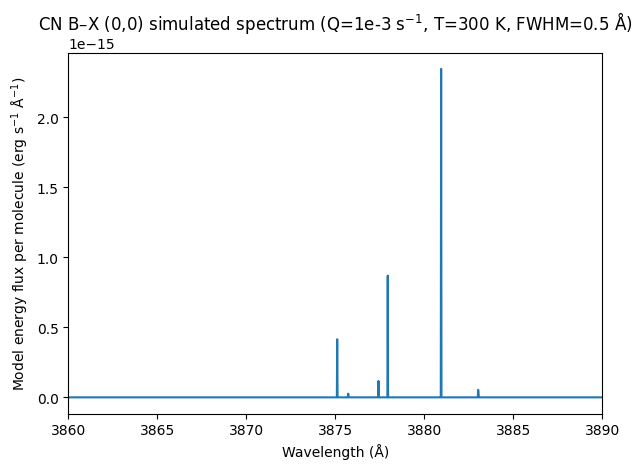

In [43]:
# synthesize in a nice CN(0,0) window; adjust if your Doppler shift/window differs
lam_grid, Flambda_model = synth_spectrum_from_lines(
    df_lines,
    g_line_energy=g_line_energy,
    fwhm_A=0.01,
    dlam_A=0.02,
    lam_min=3860.0,
    lam_max=3890.0,
    scale=1e5,          # overall scale (per molecule). You can set this to your best-fit column later.
    dlam_shift=0.0      # tiny wavelength tweak if needed
)
# plot
plt.figure()
plt.plot(lam_grid, Flambda_model)
# plt.plot(data_files['20250924']['WAVE'], data_files['20250924']['FLUX_STACK']*4e4, alpha=0.5)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Model energy flux per molecule (erg s$^{-1}$ Å$^{-1}$)")
plt.title("CN B–X (0,0) simulated spectrum (Q=1e-3 s$^{-1}$, T=300 K, FWHM=0.5 Å)")
plt.xlim(3860, 3890)
plt.tight_layout()
plt.show()

[warn] Found Q-branch labels in B–X subset; check 'Des' parsing.
Counts after filter: B–X(0,0) = 424 | A–X(1,0) = 774
[diag] N levels: 567 | M finite: True
[collisions] Ground levels found: 144
[collisions] Added links: 356; Q=1.000e-04 s^-1, T=300.0 K
[diag] n finite: True sum: 1.0


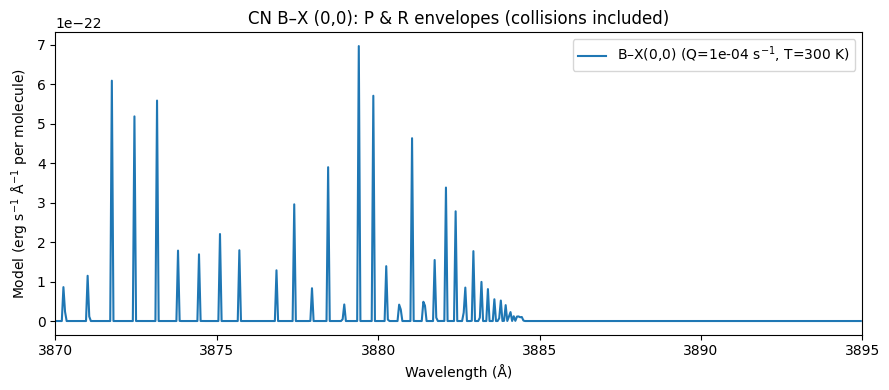

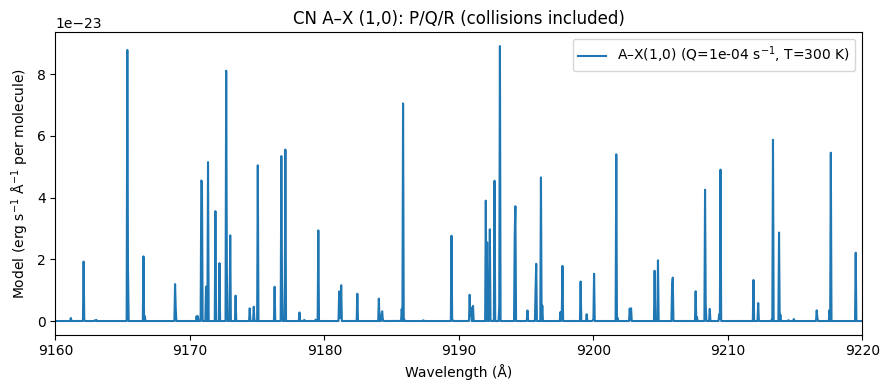

Totals: g_ph = 1.5354477510633822e-10 photons s^-1 mol^-1 ; g_en = 5.90938639030297e-22 erg s^-1 mol^-1


In [49]:
# -*- coding: utf-8 -*-
"""
CN fluorescence with Brooke et al. line lists:
- Filter to B–X(0–0) and A–X(1–0)
- Build radiative rate matrix (photon-occupation nbar)
- Add X-state rotational collisions (Manfroid-style)
- Solve and synthesize separate spectra
"""

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u, constants as const
from astropy.table import Table

# ----------------------------- I/O: Brooke parser ------------------------------

def load_cn_linelist(path_or_text: str) -> pd.DataFrame:
    colspecs = [
        (0,1), (2,3), (4,6), (7,9), (10,15), (16,21), (22,23), (24,25),
        (26,27), (28,29), (30,33), (34,37), (38,49), (50,60), (61,69),
        (70,80), (81,93), (94,106), (107,118)
    ]
    names = ["eS'", "eS''", "v'", "v''", "J'", "J''", "F'", "F''", "p'", "p''",
             "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f", "Des"]

    # read text
    if '\n' in path_or_text or path_or_text.strip().startswith("Title:"):
        text = path_or_text
    else:
        with open(path_or_text, "r", encoding="utf-8") as f:
            text = f.read()

    # keep fixed-width rows that start with state letters
    data_lines = [ln for ln in text.splitlines()
                  if len(ln) > 2 and ln[0] in "ABX" and ln[1].isspace() and ln[2] in "ABX"]

    df = pd.read_fwf(io.StringIO("\n".join(data_lines)),
                     colspecs=colspecs, names=names)

    # numeric conversions
    num_cols = ["v'", "v''", "J'", "J''", "F'", "F''", "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    for c in ["eS'", "eS''", "p'", "p''", "Des", "N'"]:
        df[c] = df[c].astype(str).str.strip()

    # wavelengths from wavenumber (Cal/Obs in cm^-1) → Å
    wn_cal = df["Cal"].to_numpy(float)
    wn_obs = df["Obs"].to_numpy(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        lam_cal_A  = 1e8 / wn_cal
        lam_obs_A  = 1e8 / wn_obs

    df["lambda_vac_A_from_Cal"] = lam_cal_A
    df["lambda_vac_A_from_Obs"] = lam_obs_A
    return df

# ----------------------- Filtering & labeling helpers --------------------------

def filter_AX_BX(df_all: pd.DataFrame,
                 use_observed_only=False,
                 lambda_min_A=2990.0010, lambda_max_A=10009.9980,
                 use_obs_wavelength=False) -> pd.DataFrame:
    """Keep B–X(0,0) + A–X(1,0) inside wavelength window (Å)."""
    df = df_all.copy()
    lam_col = "lambda_vac_A_from_Obs" if use_obs_wavelength else "lambda_vac_A_from_Cal"

    # subset: emitter in A or B, lower X
    df = df[(df["eS'"].isin(["A","B"])) & (df["eS''"]=="X")]

    # masks
    m_B00 = (df["eS'"]=="B") & (df["v'"]==0) & (df["v''"]==0)
    m_A10 = (df["eS'"]=="A") & (df["v'"]==1) & (df["v''"]==0)

    df = df[m_B00 | m_A10]

    # wavelength window
    df = df[(df[lam_col] >= lambda_min_A) & (df[lam_col] <= lambda_max_A)]

    if use_observed_only:
        df = df[np.isfinite(df["Obs"])]

    # sanity: no Q in B–X
    if df[(df["eS'"]=="B") & df["Des"].str.contains('Q', na=False)].shape[0] > 0:
        print("[warn] Found Q-branch labels in B–X subset; check 'Des' parsing.")
    return df

def make_manifold(es, v):
    es = str(es).strip().upper()
    return f"Ground X v={int(v)}" if es.startswith('X') else f"{es} v={int(v)}"

def make_sym(F, p, use_omega=False, es=None):
    ptag = str(p).strip().lower()[:1] if p not in (None, "") else "?"
    try:
        Fint = int(F)
    except Exception:
        Fint = F
    if use_omega and str(es).strip().upper().startswith("A"):
        comp = "Ω3/2" if Fint == 1 else "Ω1/2"   # Brooke note for A 2Π
        return f"{comp}_{ptag}"
    return f"F{Fint}_{ptag}"

# ------------------------------ Pumping field ----------------------------------

def attach_pumping_and_labels(df: pd.DataFrame,
                              wave_AA: np.ndarray,
                              F_lambda_erg_s_cm2_AA: np.ndarray,
                              use_obs_wavelength=False,
                              use_omega_labels=False) -> Table:
    """Interpolate Fλ(Å) to each line, compute Jν, add solver labels, return Table."""
    lam_col = "lambda_vac_A_from_Obs" if use_obs_wavelength else "lambda_vac_A_from_Cal"
    lines = Table.from_pandas(df.copy())

    lam = (np.asarray(lines[lam_col], float) * u.AA)
    lines["Wave_vac_AA"]  = lam.to_value(u.AA)
    lines["Frequency_Hz"] = (const.c / lam).to(u.Hz)

    # Fλ at comet
    F_lambda = np.asarray(F_lambda_erg_s_cm2_AA, float) * (u.erg / (u.s * u.cm**2 * u.AA))
    lam_grid = np.asarray(wave_AA, float)
    F_interp = np.interp(lines["Wave_vac_AA"], lam_grid, F_lambda.value) * F_lambda.unit
    lines["F_lambda_at_comet_erg_s_cm2_AA"] = F_interp

    # Fλ → Fν → Jν = Fν / (4π)
    F_nu = F_interp.to(u.erg / (u.s * u.cm**2 * u.Hz), equivalencies=u.spectral_density(lam))
    J_nu = (F_nu / (4*np.pi)) * (1/u.sr)  # sr explicit but dimensionless in SI
    lines["J_nu_erg_cm2_s_Hz_sr"] = J_nu.to(u.erg / (u.cm**2 * u.s * u.Hz * u.sr))

    # labels
    lines["J_prime"]       = lines["J'"]
    lines["J_doubleprime"] = lines["J''"]
    lines["Upper_Manifold"] = [make_manifold(es, v) for es, v in zip(lines["eS'"], lines["v'"])]
    lines["Lower_Manifold"] = [make_manifold(es, v) for es, v in zip(lines["eS''"], lines["v''"])]
    lines["Sym_prime"]       = [make_sym(F, p, use_omega_labels, es=es) for F, p, es in zip(lines["F'"], lines["p'"], lines["eS'"])]
    lines["Sym_doubleprime"] = [make_sym(F, p, use_omega_labels, es=es) for F, p, es in zip(lines["F''"], lines["p''"], lines["eS''"])]
    return lines

# --------------------------- Radiative rate matrix ------------------------------

def build_rate_matrix_nbar(lines: Table, include_stim_emission=False, verbose=True):
    """Photon-occupation form: nbar = (c^2/(2 h ν^3)) * Jν(SI)."""
    lines_out = lines.copy()
    nu  = lines_out["Frequency_Hz"].to(u.Hz)
    Aul = (lines_out["A"] * (1/u.s)).to(1/u.s)

    Jnu_cgs = lines_out["J_nu_erg_cm2_s_Hz_sr"].to(u.erg / (u.cm**2 * u.s * u.Hz * u.sr))
    Jnu_SI  = Jnu_cgs.to(u.W / (u.m**2 * u.Hz * u.sr))

    Jp  = np.asarray(lines_out["J_prime"],       float)
    Jpp = np.asarray(lines_out["J_doubleprime"], float)
    gu, gl = 2.0*Jp + 1.0, 2.0*Jpp + 1.0

    nbar = (const.c**2 / (2.0*const.h*nu**3) * Jnu_SI).decompose().value

    Aul_v = Aul.to_value(1/u.s)
    R_lu = (gu/gl) * Aul_v * nbar
    R_ul = Aul_v + (Aul_v * nbar if include_stim_emission else 0.0)

    # level indices
    up_man = np.asarray(lines_out["Upper_Manifold"], str)
    up_sym = np.asarray(lines_out["Sym_prime"], str)
    lo_man = np.asarray(lines_out["Lower_Manifold"], str)
    lo_sym = np.asarray(lines_out["Sym_doubleprime"], str)

    all_levels = {}
    upper_idx, lower_idx = [], []
    for i in range(len(lines_out)):
        ku = (up_man[i], float(Jp[i]),  up_sym[i])
        kl = (lo_man[i], float(Jpp[i]), lo_sym[i])
        if ku not in all_levels: all_levels[ku] = len(all_levels)
        if kl not in all_levels: all_levels[kl] = len(all_levels)
        upper_idx.append(all_levels[ku]); lower_idx.append(all_levels[kl])
    idx_to_level = {v: k for k, v in all_levels.items()}
    n_levels = len(idx_to_level)

    # assemble M
    M = np.zeros((n_levels, n_levels), float)
    def add_rate(dest, src, rate):
        if not np.isfinite(rate) or rate == 0.0: return
        M[src, src] -= rate
        M[dest, src] += rate

    for iu, il, rlu, rul in zip(upper_idx, lower_idx, R_lu, R_ul):
        add_rate(iu, il, float(rlu))  # absorption: l→u
        add_rate(il, iu, float(rul))  # emission:   u→l

    # stash
    lines_out["__nu_Hz"]      = nu.to_value(u.Hz)
    lines_out["__R_lu"]       = R_lu
    lines_out["__R_ul"]       = R_ul
    lines_out["__upper_idx"]  = np.asarray(upper_idx, int)
    lines_out["__lower_idx"]  = np.asarray(lower_idx, int)

    if verbose:
        print("[diag] N levels:", n_levels, "| M finite:", np.isfinite(M).all())
    return M, idx_to_level, lines_out

# ------------------------- X-state rotational collisions ------------------------

def add_cn_collisions_to_M(M, lines_with_rates, idx_to_level,
                           Q=1e-3, T=300.0, include_deltaJ0=True, verbose=True):
    """
    Rotational collisions among X-state (Ground) levels:
      - constant downward C_{u->l} = Q (s^-1) for |ΔJ|=1; optionally ΔJ=0 across e/f
      - upward by detailed balance: g_l C_{l->u} = g_u C_{u->l} exp(-(E_u - E_l)/kT)
      - energies from E'' (cm^-1), relative to v''=0 origin (OK: only ΔE matters)
    """
    kT = (const.k_B * (T * u.K)).to(u.erg).value
    if Q < 0: Q = 0.0

    lower_idx = np.asarray(lines_with_rates["__lower_idx"], int)
    Jpp       = np.asarray(lines_with_rates["J_doubleprime"], float)
    Elower    = np.asarray(lines_with_rates["E''"], float)  # cm^-1

    # collect per-level energies (median)
    E_level_cm = {}
    J_level, sym_level = {}, {}
    for i, idx in enumerate(lower_idx):
        man, Jlab, sym = idx_to_level[idx]
        if str(man).lower().startswith("ground"):
            E_level_cm.setdefault(idx, []).append(Elower[i])
            J_level[idx]   = float(Jpp[i])
            sym_level[idx] = str(sym)
    ground_ids = sorted(E_level_cm.keys())
    if verbose: print(f"[collisions] Ground levels found: {len(ground_ids)}")
    if not ground_ids: 
        if verbose: print("[collisions] None found; skipping.")
        return M

    Eerg, gdeg = {}, {}
    for idx in ground_ids:
        if len(E_level_cm[idx]) == 0: continue
        Ecm  = np.median(np.asarray(E_level_cm[idx], float)) * (1/u.cm)
        Eerg[idx] = (const.h * const.c * Ecm).to(u.erg).value
        gdeg[idx] = 2.0 * J_level[idx] + 1.0

    # neighbor map by ΔJ
    ground_sorted = sorted(ground_ids, key=lambda i: (J_level[i], sym_level[i]))
    pairs_done = set()

    def add_pair(iu, il, C_down):
        if C_down <= 0: return
        gu, gl = gdeg[iu], gdeg[il]
        dE = Eerg[iu] - Eerg[il]  # erg
        Cup = (gu/gl) * C_down * np.exp(-dE / kT)

        M[iu, iu] -= C_down
        M[il, iu] += C_down
        if np.isfinite(Cup) and Cup > 0:
            M[il, il] -= Cup
            M[iu, il] += Cup

    for i in range(len(ground_sorted)):
        i_idx = ground_sorted[i]
        Ji, si = J_level[i_idx], sym_level[i_idx]
        for j in range(i+1, len(ground_sorted)):
            j_idx = ground_sorted[j]
            Jj, sj = J_level[j_idx], sym_level[j_idx]
            dJ = abs(Ji - Jj)
            allow = (dJ == 1) or (include_deltaJ0 and (dJ == 0) and (si != sj))
            if not allow: 
                continue
            # assign higher/lower by energy
            iu, il = (j_idx, i_idx) if Eerg[j_idx] > Eerg[i_idx] else (i_idx, j_idx)
            key = (min(iu, il), max(iu, il))
            if key in pairs_done: 
                continue
            pairs_done.add(key)
            add_pair(iu, il, Q)

    if verbose:
        print(f"[collisions] Added links: {len(pairs_done)}; Q={Q:.3e} s^-1, T={T:.1f} K")
    return M

# --------------------------------- Solver & g ----------------------------------

def solve_with_normalization(M, verbose=True):
    n_levels = M.shape[0]
    A = M.copy()
    b = np.zeros(n_levels, float)
    A[-1, :] = 1.0
    b[-1] = 1.0
    try:
        n = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        if verbose: print("[solve] singular; using tiny diagonal regularization")
        eps = 1e-12
        A_reg = M + np.eye(n_levels) * eps
        A_reg[-1, :] = 1.0
        n = np.linalg.lstsq(A_reg, b, rcond=None)[0]
    n = np.nan_to_num(n, nan=0.0, posinf=0.0, neginf=0.0)
    n[n < 0] = 0.0
    s = n.sum()
    n = (n / s) if s > 0 else np.eye(1, n_levels, 0).ravel()
    if verbose:
        print("[diag] n finite:", np.isfinite(n).all(), "sum:", n.sum())
    return n

def g_factors(lines_with_rates: Table, n):
    nu  = np.asarray(lines_with_rates["__nu_Hz"], float)
    Aul = np.asarray(lines_with_rates["A"], float)
    ui  = np.asarray(lines_with_rates["__upper_idx"], int)
    nu  = np.nan_to_num(nu,  0.0, 0.0, 0.0)
    Aul = np.nan_to_num(Aul, 0.0, 0.0, 0.0)
    n_u = n[ui]
    g_ph = n_u * Aul
    g_en = (const.h.cgs.value * nu) * g_ph
    g_ph = np.nan_to_num(g_ph, 0.0, 0.0, 0.0)
    g_en = np.nan_to_num(g_en, 0.0, 0.0, 0.0)
    return g_ph, g_en, float(g_ph.sum()), float(g_en.sum())

# ------------------------------ Spectrum builder --------------------------------

def _ensure_g_energy(df_lines, g_line_energy=None, g_line_phot=None):
    if g_line_energy is not None:
        return np.asarray(g_line_energy, float)
    if g_line_phot is None:
        raise ValueError("Provide g_line_energy or g_line_phot.")
    nu = np.asarray(df_lines["__nu_Hz"] if "__nu_Hz" in df_lines.colnames
                    else df_lines["Frequency_Hz"], float)
    return (const.h.cgs.value * nu) * np.asarray(g_line_phot, float)

def synth_spectrum_from_lines(df_lines: Table, g_line_energy=None, g_line_phot=None,
                              fwhm_A=1.0, dlam_A=0.05, lam_min=None, lam_max=None,
                              scale=1.0, dlam_shift=0.0, lam_col="Wave_vac_AA"):
    if lam_col not in df_lines.colnames:
        raise ValueError(f"Need '{lam_col}' in df_lines.")
    lam = np.asarray(df_lines[lam_col], float) + dlam_shift
    I   = _ensure_g_energy(df_lines, g_line_energy, g_line_phot)
    m = np.isfinite(lam) & np.isfinite(I) & (I > 0)
    lam, I = lam[m], I[m]
    if lam.size == 0: return np.array([]), np.array([])
    if lam_min is None: lam_min = lam.min() - 1.0
    if lam_max is None: lam_max = lam.max() + 1.0
    grid = np.arange(lam_min, lam_max, dlam_A)
    sigma = fwhm_A / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    norm  = 1.0 / (sigma * np.sqrt(2.0 * np.pi))
    spec  = np.zeros_like(grid)
    for lam0, area in zip(lam, I):
        spec += area * norm * np.exp(-0.5 * ((grid - lam0) / sigma) ** 2)
    return grid, scale * spec

# --------------------------------- Main demo ------------------------------------

if __name__ == "__main__":
    # ==== 1) Load Brooke table ====
    brooke_path = "CN_lines/12C14N.txt"  # <-- set your path
    df_all = load_cn_linelist(brooke_path)

    # ==== 2) Filter to B–X(0,0) + A–X(1,0) ====
    use_obs_wave = False      # True -> use Obs wavelengths
    use_obs_only = False      # True -> drop lines with blank Obs
    df = filter_AX_BX(df_all,
                      use_observed_only=use_obs_only,
                      lambda_min_A=2990.0010, lambda_max_A=10009.9980,
                      use_obs_wavelength=use_obs_wave)
    print("Counts after filter:",
          "B–X(0,0) =", df[(df["eS'"]=='B') & (df["v'"]==0) & (df["v''"]==0)].shape[0],
          "| A–X(1,0) =", df[(df["eS'"]=='A') & (df["v'"]==1) & (df["v''"]==0)].shape[0])

    # ==== 3) Pumping spectrum (Å, erg s^-1 cm^-2 Å^-1) ====
    # Replace with your real arrays:
    wave_AA = np.linspace(3000.0, 10050.0, 10000)
    F_lambda = np.full_like(wave_AA, 1e-7)  # flat irradiance just for demo

    # ==== 4) Attach pumping, labels; build radiative matrix ====
    lines = attach_pumping_and_labels(df, wave_AA, F_lambda,
                                      use_obs_wavelength=use_obs_wave,
                                      use_omega_labels=False)
    M, idx2lvl, lines_out = build_rate_matrix_nbar(lines, include_stim_emission=False, verbose=True)

    # ==== 5) Add X-state rotational collisions ====
    Q_COLL = 1e-4   # s^-1  (try 1e-5 .. 1e-3)
    T_COLL = 300.0  # K
    M = add_cn_collisions_to_M(M, lines_out, idx2lvl, Q=Q_COLL, T=T_COLL, include_deltaJ0=True, verbose=True)

    # ==== 6) Solve populations ====
    n = solve_with_normalization(M, verbose=True)

    # ==== 7) g-factors & spectra ====
    g_ph, g_en, gtot_ph, gtot_en = g_factors(lines_out, n)

    is_B00 = (lines_out["eS'"]=='B') & (lines_out["eS''"]=='X') & (lines_out["v'"]==0) & (lines_out["v''"]==0)
    is_A10 = (lines_out["eS'"]=='A') & (lines_out["eS''"]=='X') & (lines_out["v'"]==1) & (lines_out["v''"]==0)

    # B–X(0,0): include bandhead ~3883.4 Å
    grid_B, spec_B = synth_spectrum_from_lines(lines_out[is_B00], g_line_energy=g_en[is_B00],
                                               fwhm_A=0.02, dlam_A=0.05,
                                               lam_min=3870.0, lam_max=3895.0, scale=1.0)
    # A–X(1,0): ~9170–9200 Å with Q branch
    grid_A, spec_A = synth_spectrum_from_lines(lines_out[is_A10], g_line_energy=g_en[is_A10],
                                               fwhm_A=0.02, dlam_A=0.05,
                                               lam_min=9160.0, lam_max=9220.0, scale=1.0)

    # ==== 8) Plot ====
    plt.figure(figsize=(9,4))
    if grid_B.size:
        plt.plot(grid_B, spec_B, label=f"B–X(0,0) (Q={Q_COLL:.0e} s$^{{-1}}$, T={T_COLL:.0f} K)")
    plt.xlim(3870, 3895); plt.xlabel("Wavelength (Å)")
    plt.ylabel("Model (erg s$^{-1}$ Å$^{-1}$ per molecule)")
    plt.title("CN B–X (0,0): P & R envelopes (collisions included)")
    plt.legend(); plt.tight_layout()

    plt.figure(figsize=(9,4))
    if grid_A.size:
        plt.plot(grid_A, spec_A, label=f"A–X(1,0) (Q={Q_COLL:.0e} s$^{{-1}}$, T={T_COLL:.0f} K)")
    plt.xlim(9160, 9220); plt.xlabel("Wavelength (Å)")
    plt.ylabel("Model (erg s$^{-1}$ Å$^{-1}$ per molecule)")
    plt.title("CN A–X (1,0): P/Q/R (collisions included)")
    plt.legend(); plt.tight_layout()
    plt.show()

    print("Totals: g_ph =", gtot_ph, "photons s^-1 mol^-1 ; g_en =", gtot_en, "erg s^-1 mol^-1")


# Now lets fit:

In [94]:
def mcmc_fitting(key, window, nwalkers=50, nsteps=1000):
    global data_files, line_tables, log_tables

    # data
    df = data_files[key]
    x_data = df['WAVE']
    y_data = df['FLUX_STACK']
    y_err = df['ERR_STACK']
    continuum = df['CONTINUUM_KURUCZ']
    pump = df['Pumping']

    # window to fit
    mask = (x_data >= window[0]) & (x_data <= window[1])
    x_fit = x_data[mask]
    y_fit = y_data[mask] - continuum[mask]
    y_err_fit = y_err[mask]

    # now here ge are going to model the lsf
    def _lsf_modeling(x_fit, y_fit, y_err_fit, key):
        stds = []
        centers = []
        stds_error = []
        for i in log_tables[key]:
            wave_numb = i['Calculated']
            wave_AA = 10**8 / wave_numb
            
            #lets fit a gaussian around each line
            line_mask = (x_fit >= wave_AA - 0.5) & (x_fit <= wave_AA + 0.5)
            x_line = x_fit[line_mask]
            y_line = y_fit[line_mask]
            y_err_line = y_err_fit[line_mask]

            model = models.Gaussian1D(amplitude=np.max(y_line)*1.5, mean=wave_AA, stddev=0.1)
            fitter = fitting.LevMarLSQFitter(calc_uncertainties=True)
            fitted_model = fitter(model, x_line, y_line, weights=1.0/y_err_line)

            # normalize all the gaussian models to have area 1
            area = fitted_model.amplitude.value * fitted_model.stddev.value * np.sqrt(2 * np.pi)
            fitted_model.amplitude.value /= area
            stds.append(fitted_model.stddev.value)
            centers.append(fitted_model.mean.value)
            stds_error.append(fitter.fit_info['param_cov'][1][1]**0.5 if fitter.fit_info['param_cov'] is not None else 0.0)
        #fit a line to centers vs stds
        model = models.Const1D()
        fitter = fitting.LinearLSQFitter()
        #include sigmaclipping interative using astropy
        or_fit = fitting.FittingWithOutlierRemoval(fitter, sigma_clip, niter=5, sigma=2)
        fitted_model, _ = or_fit(model, np.array(centers), stds, weights=1.0/np.array(stds_error))

        return fitted_model.amplitude.value

    lsf_std = _lsf_modeling(x_fit, y_fit, y_err_fit, key)

    # now the mcmc helpers:
    def _ln_prior_uniform(theta):
        """
        uniform prior, Amp=10^(a)
        """
        a, Q, T, q00, dlam_shift = theta
        max_a = 10
        min_a = 1
        max_Q = 1e-2
        min_Q = 0
        max_T = 1000
        min_T = 10
        max_q00 = 1.0
        min_q00 = 0.7
        max_dlam_shift = 0.5
        min_dlam_shift = -0.5

        if (a < min_a) or (a > max_a):
            return -np.inf
        if (Q < min_Q) or (Q > max_Q):
            return -np.inf
        if (T < min_T) or (T > max_T):
            return -np.inf
        if (q00 < min_q00) or (q00 > max_q00):
            return -np.inf
        if (dlam_shift < min_dlam_shift) or (dlam_shift > max_dlam_shift):
            return -np.inf
        return 0.0


    def _model(wave, theta):
        a, Q, T, q00, dlam_shift = theta
        scale = 10**(a)

        # rebuild M with new Q,T,q00
        M, idx2lvl, df_lines = build_rate_matrix(
            line_tables[key],
            include_stim_emission=False
        )

        M = add_cn_collisions_to_M(M, df_lines, idx2lvl, Q=Q, T=T, include_deltaJ0=True, verbose=False)

        n = solve_with_normalization(M, verbose=False)
        
        g_line_phot, g_line_energy, g_band_phot, g_band_energy = g_factors(df_lines, n)

        _, Flambda_model = synth_spectrum_from_lines(
            df_lines,
            g_line_energy=g_line_energy,
            fwhm_A=lsf_std * 2.355,
            grid=wave,
            scale=scale,
            dlam_shift=dlam_shift
        )
        return Flambda_model

    def _lnlike_(theta, wave, flux, flux_err):
        y_model = _model(wave, theta)
        return -0.5 * np.sum(np.log(2 * np.pi * flux_err ** 2) + (flux - y_model) ** 2 / flux_err ** 2)
    
    def _lnprob_uninformed(theta, wave, flux, flux_err):
        lp = _ln_prior_uniform(theta)
        if not np.isfinite(lp):
            return -np.inf
        lnMeasured = _lnlike_(theta, wave, flux, flux_err)
        if not np.isfinite(lnMeasured):
            return -np.inf
        return lp + lnMeasured
    def _prune(samples, lnprob, scaler=5.0, quiet=False):

        minlnprob = lnprob.max()
        dlnprob = np.abs(lnprob - minlnprob)
        medlnprob = np.median(dlnprob)
        avglnprob = np.mean(dlnprob)
        skewlnprob = np.abs(avglnprob - medlnprob)
        rmslnprob = np.std(dlnprob)
        inliers = (dlnprob < scaler*rmslnprob)
        lnprob2 = lnprob[inliers]
        samples = samples[inliers]

        medlnprob_previous = 0.
        while skewlnprob > 0.1*medlnprob:
            minlnprob = lnprob2.max()
            dlnprob = np.abs(lnprob2 - minlnprob)
            rmslnprob = np.std(dlnprob)
            inliers = (dlnprob < scaler*rmslnprob)
            PDFdatatmp = lnprob2[inliers]
            if len(PDFdatatmp) == len(lnprob2):
                inliers = (dlnprob < scaler/2.*rmslnprob)
            lnprob2 = lnprob2[inliers]
            samples = samples[inliers]
            dlnprob = np.abs(lnprob2 - minlnprob)
            medlnprob = np.median(dlnprob)
            avglnprob = np.mean(dlnprob)
            skewlnprob = np.abs(avglnprob - medlnprob)
            if not quiet:
                print(medlnprob, avglnprob, skewlnprob)
            if medlnprob == medlnprob_previous:
                scaler /= 1.5
            medlnprob_previous = medlnprob
        samples = samples[lnprob2 <= minlnprob]
        lnprob2 = lnprob2[lnprob2 <= minlnprob]
        return samples,lnprob2

    #lets go with the fitting
    Nsteps = nsteps
    Nburn = int(Nsteps/2)
    NWalkers = nwalkers
    Ndim = 5
    Nthreads = 4
    MCMCA = 3

    starting_guesses = []

    for i in range(NWalkers):
        aux = 	[
        		np.random.uniform(1, 10),    #log10(A)
        		np.random.uniform(1e-5, 1e-2),  #Q
        		np.random.uniform(10, 300),    #T
        		np.random.uniform(0.7, 1.0),    #q00
        		np.random.uniform(-0.1, 0.1)    #dlam
        		]
        starting_guesses.append(np.array(aux))
    print('Number of iterations:',Ndim*NWalkers*Nsteps)
    
    sampler = emcee.EnsembleSampler(NWalkers, Ndim, _lnprob_uninformed, args=[x_fit, y_fit, y_err_fit], moves=emcee.moves.StretchMove(MCMCA), threads=Nthreads)
    in_time = time.time()
    currenttime = time.time()
    Step = 1
    from tqdm.auto import tqdm
    pbar = tqdm(total=Nsteps, desc="Sampling", unit="step")
    for pos, prob, state in sampler.sample(starting_guesses, iterations=Nsteps):
        currenttime = time.time()
        # ... work ...
        pbar.set_postfix(step_time=f"{time.time()-currenttime:.3f}s")
        pbar.update(1)

    pbar.close()

    print('*** Done Fitting... ***')
    ll = ['a', 'Q', 'T', 'q00', 'dlam_shift']
    
    emcee_trace = sampler.chain[:, :, :].reshape((-1, Ndim))
    lnprobMeasured = sampler.lnprobability
    print(50*'#')
    print('*** Best fit no pruning ***')
    for i in range(len(ll)):
       print(ll[i],':',emcee_trace[np.argmax(lnprobMeasured)][i])
    
    params = emcee_trace[np.argmax(lnprobMeasured)]

    lnprobMeasured = sampler.lnprobability
    maxlnprob = np.max(lnprobMeasured)

    x = np.array([])
    y = np.array([])

    for i in range(len(lnprobMeasured)):
        x = np.append(x, range(len(lnprobMeasured[i])))
        y = np.append(y, maxlnprob - lnprobMeasured[i])
    plt.figure()
    plt.hexbin(x[y>0],y[y>0], gridsize=[70,30], cmap='inferno',bins='log',mincnt=1,yscale='log',linewidths=0)
    plt.ylabel('maxlnprob -lnprob')
    plt.xlabel('iteration')
    plt.title('Traces')
    try:
        plt.xlim(min(x),max(x))
        plt.ylim(min(y),max(y))
    except:
        print('Negative values in Convergence....')
    plt.show()
    fig_, ax_ = plt.subplots(Ndim,1, figsize=(8,2*Ndim))

    for ID in range(Ndim):
        x = np.array([])
        y = np.array([])
        for i in sampler.chain:
            x = np.append(x,range(len(i.T[ID])))
            y = np.append(y,i.T[ID])
        if (max(y)/min(y))>50 and len(y[y<0])<1:
            ax_[ID].hexbin(x,y, gridsize=[70,30], cmap='inferno',bins='log',mincnt=1,yscale='log',linewidths=0)
        else:
            ax_[ID].hexbin(x,y, gridsize=[70,30], cmap='inferno',bins='log',mincnt=1,linewidths=0)
        ax_[ID].set_ylabel(ll[ID])
        ax_[ID].set_xlabel('iteration')
        ax_[ID].set_xlim(min(x),max(x))
        ax_[ID].set_ylim(min(y),max(y))
        ax_[ID].set_title('Traces')
    plt.show()

    print(50*'#')
    print('*** Acceptance Fraction ***')
    af = sampler.acceptance_fraction
    af_msg = '''As a rule of thumb, the acceptance fraction (af) should be 
                              between 0.2 and 0.5
              If af < 0.2 decrease the MCMCA parameter
              If af > 0.5 increase the MCMCA parameter
              '''
    print("Mean acceptance fraction:", np.mean(af))
    if np.mean(af)<0.2 or np.mean(af)>0.5:
        print(af_msg)
    
    samples = sampler.chain[:, Nburn:, :].reshape((-1, Ndim))
    lnprob_aux = sampler.lnprobability[:, Nburn:].reshape(-1)
    print(50*'#')
    print('*** Pruning... ***')
    try:
        samples,lnprob2 = _prune(samples,lnprob_aux)
    except:
        print('Prunning failed....')

    corner.corner(samples, labels=ll,title_kwargs={'y':1.05},title_fmt=".3f",use_math_text=True,bins=15,quantiles=[0.16, 0.5, 0.84],show_titles=True,
                  color='lightseagreen',hist_kwargs={'color':'black','linewidth':1.5},contour_kwargs={'linewidths':1,'colors':'black'}, spacing=0.001)
    results = []
    results_err = []
    for ID in range(Ndim):
        pc = np.percentile(samples.T[ID], [16,50,84])
        print(ll[ID]+':',round(pc[1],4),'+/-',round(np.mean([pc[2]-pc[1],pc[1]-pc[0]]),4),pc)
        results.append(pc[1])
        results_err.append(np.mean([pc[2]-pc[1],pc[1]-pc[0]]))
    
    Models = []
    x = np.linspace(window[0], window[1], 1000)
    for i in range(200):
        Models.append(_model(x, samples[i]))
        
    Models = np.array(Models)
    Models = np.transpose(Models)
        
    Median_Model = []
    Model_e1 = []
    Model_e2 = []
        
    for i in range(len(Models)):
        aux = np.percentile(Models[i],[16,50,84])
        Median_Model.append(aux[1])
        Model_e1.append(aux[0])
        Model_e2.append(aux[2])

    plt.figure()
    plt.plot(x_fit, y_fit, label='Data', color='black')
    # plt.fill_between(x, Model_e1, Model_e2, color='lightgray', label='1$\sigma$ interval')
    plt.plot(x, Median_Model, label='Median Model', color='red')
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux (erg s$^{-1}$ Å$^{-1}$)")
    plt.title("MCMC Fit to CN B–X (0,0) band")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results, results_err, Median_Model, Model_e1, Model_e2

results, results_err, Median_Model, Model_e1, Model_e2 = mcmc_fitting('20250924', (3868.0, 3884.0), nwalkers=25, nsteps=2000)

Number of iterations: 250000


Sampling:   0%|          | 0/2000 [00:00<?, ?step/s]

[diag] nu_Hz: N=7827, nonfinite=0, min=6.469e+14 Hz, max=8.872e+14 Hz
[diag] Jnu: N=7827, nonfinite=0, min=7.264e-13 erg / (sr cm2), max=3.890e-11 erg / (sr cm2)
[diag] Aul: N=7827, nonfinite=0, min=1.001e+05 1 / s, max=9.969e+06 1 / s
[diag] M finite: True shape: (2334, 2334)
[diag] nu_Hz: N=7827, nonfinite=0, min=6.469e+14 Hz, max=8.872e+14 Hz
[diag] Jnu: N=7827, nonfinite=0, min=7.264e-13 erg / (sr cm2), max=3.890e-11 erg / (sr cm2)
[diag] Aul: N=7827, nonfinite=0, min=1.001e+05 1 / s, max=9.969e+06 1 / s
[diag] M finite: True shape: (2334, 2334)
[diag] nu_Hz: N=7827, nonfinite=0, min=6.469e+14 Hz, max=8.872e+14 Hz
[diag] Jnu: N=7827, nonfinite=0, min=7.264e-13 erg / (sr cm2), max=3.890e-11 erg / (sr cm2)
[diag] Aul: N=7827, nonfinite=0, min=1.001e+05 1 / s, max=9.969e+06 1 / s
[diag] M finite: True shape: (2334, 2334)
[diag] nu_Hz: N=7827, nonfinite=0, min=6.469e+14 Hz, max=8.872e+14 Hz
[diag] Jnu: N=7827, nonfinite=0, min=7.264e-13 erg / (sr cm2), max=3.890e-11 erg / (sr cm2)
[dia

Traceback (most recent call last):
  File "/Users/baltasarluco/Desktop/ESPRESSO_COMET/.venv/lib/python3.13/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_62796/684450008.py", line 118, in _lnprob_uninformed
    lnMeasured = _lnlike_(theta, wave, flux, flux_err)
  File "/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_62796/684450008.py", line 111, in _lnlike_
    y_model = _model(wave, theta)
  File "/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_62796/684450008.py", line 100, in _model
    _, Flambda_model = synth_spectrum_from_lines(
                       ~~~~~~~~~~~~~~~~~~~~~~~~~^
        df_lines,
        ^^^^^^^^^
    ...<4 lines>...
        dlam_shift=dlam_shift
        ^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_62796/3745441917.py

KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (443262,) and (1000,)

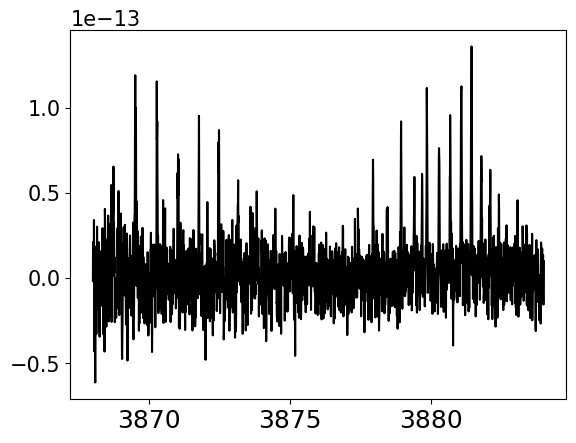

In [166]:
df = data_files['20250924']
x_data = df['WAVE']
y_data = df['FLUX_STACK']
y_err = df['ERR_STACK']
continuum = df['CONTINUUM_KURUCZ']
pump = df['Pumping']

# window to fit
mask = (x_data >= (3868.0, 3884.0)[0]) & (x_data <= (3868.0, 3884.0)[1])
x_fit = x_data[mask]
y_fit = y_data[mask] - continuum[mask]
y_err_fit = y_err[mask]
plt.figure()
plt.plot(x_fit, y_fit, label='Data', color='black')
# plt.fill_between(x, Model_e1, Model_e2, color='lightgray', label='1$\sigma$ interval')
plt.plot(x_data, Median_Model, label='Median Model', color='red')
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (erg s$^{-1}$ Å$^{-1}$)")
plt.title("MCMC Fit to CN B–X (0,0) band")
plt.legend()
plt.xlim((3868.0, 3884.0))
plt.tight_layout()
plt.show()

In [167]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

horizons_path = 'gemini_3I_1.txt'
df = pd.read_csv(horizons_path, skipinitialspace=True)

df.columns = [
    (col.strip() if isinstance(col, str) else col) or f'Unnamed_{idx}'
    for idx, col in enumerate(df.columns)
]

# Strip whitespace padding in string columns for easier downstream use
object_cols = df.select_dtypes(include='object').columns
if len(object_cols):
    df[object_cols] = df[object_cols].apply(lambda col: col.str.strip())

df.head()

horizons_path2 = 'gemini_3I_2.txt'
df2 = pd.read_csv(horizons_path2, skipinitialspace=True)
df2.columns = [
    (col.strip() if isinstance(col, str) else col) or f'Unnamed_{idx}'
    for idx, col in enumerate(df2.columns)
]  
object_cols2 = df2.select_dtypes(include='object').columns
if len(object_cols2):
    df2[object_cols2] = df2[object_cols2].apply(lambda col: col.str.strip())

sun_path = 'sun_gemini.txt'

df_sun = pd.read_csv(sun_path, skipinitialspace=True)
df_sun.columns = [
    (col.strip() if isinstance(col, str) else col) or f'Unnamed_{idx}'
    for idx, col in enumerate(df_sun.columns)
]
object_cols_sun = df_sun.select_dtypes(include='object').columns
if len(object_cols_sun):
    df_sun[object_cols_sun] = df_sun[object_cols_sun].apply(lambda col: col.str.strip())

def _to_float_series(s):
    """Robustly pull the first float-looking number from each cell."""
    return pd.to_numeric(
        s.astype(str).str.extract(r'([-+]?\d+(?:\.\d+)?)', expand=False),
        errors='coerce'
    )

def _first_present(df, candidates):
    """Return the first existing column name from candidates, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

def visible_hours_per_night(df_target, df_sun,
                            airmax=2.8,
                            buffer_hours=1,
                            sun_elev_thresh_deg=0):  # use -18 for astronomical night
    """
    df_target columns needed:
        'Date__(UT)__HR:MN:SS', 'a-mass', and a Tmag column named one of:
        'T-mag' or 'Tmag' or 'T_mag' (optional but required for mean_Tmag)
    df_sun columns needed:
        'Date__(UT)__HR:MN:SS', 'Elevation_(a-app)'

    Returns:
        night_label | visible_hours | usable_hours | mean_Tmag
    """
    df_sun = df_sun.copy()
    df_target = df_target.copy()

    # ---- 1) Parse timestamps and sort
    for df in (df_sun, df_target):
        df['t'] = pd.to_datetime(df['Date__(UT)__HR:MN:SS'], utc=True, errors='coerce')
        df.dropna(subset=['t'], inplace=True)
        df.sort_values('t', inplace=True)

    # ---- 2) Coerce numeric columns
    df_sun['sun_elev'] = _to_float_series(df_sun['Elevation_(a-app)'])
    df_target['airmass'] = _to_float_series(df_target['a-mass'])

    # Tmag: try common variants; if none present, we'll produce NaNs later
    tmag_col = _first_present(df_target, ['T-mag', 'Tmag', 'T_mag'])
    if tmag_col is not None:
        df_target['Tmag'] = _to_float_series(df_target[tmag_col])
    else:
        df_target['Tmag'] = np.nan  # so code runs even if missing

    # ---- 3) Night detection from Sun elevation
    df_sun['sun_below'] = df_sun['sun_elev'] < sun_elev_thresh_deg
    df_sun['block'] = df_sun['sun_below'].ne(df_sun['sun_below'].shift()).cumsum()

    nights = (
        df_sun[df_sun['sun_below']]
        .groupby('block', as_index=False)
        .agg(night_start=('t', 'min'), night_end=('t', 'max'))
        .drop(columns='block')
    )

    if nights.empty:
        return pd.DataFrame(columns=['night_label', 'visible_hours', 'usable_hours', 'mean_Tmag'])

    # ---- 4) Usable windows: sunset+buffer … dawn-buffer
    buf = pd.Timedelta(hours=buffer_hours)
    nights['usable_start'] = nights['night_start'] + buf
    nights['usable_end']   = nights['night_end']   - buf
    nights = nights[nights['usable_end'] > nights['usable_start']].reset_index(drop=True)

    if nights.empty:
        return pd.DataFrame(columns=['night_label', 'visible_hours', 'usable_hours', 'mean_Tmag'])

    nights['night_label'] = nights['usable_start'].dt.date.astype(str)
    nights['usable_hours'] = (nights['usable_end'] - nights['usable_start']).dt.total_seconds() / 3600.0

    # ---- 5) Map target samples to usable-night intervals
    ii = pd.IntervalIndex.from_arrays(nights['usable_start'], nights['usable_end'], closed='both')
    night_idx = ii.get_indexer(df_target['t'])
    tgt = df_target[night_idx != -1].copy()
    if tgt.empty:
        out = nights[['night_label', 'usable_hours']].copy()
        out['visible_hours'] = 0.0
        out['mean_Tmag'] = np.nan
        return out[['night_label', 'visible_hours', 'usable_hours', 'mean_Tmag']]

    tgt['night_idx'] = night_idx[night_idx != -1]

    # ---- 6) dt to next sample (only within same night)
    tgt['t_next'] = tgt.groupby('night_idx')['t'].shift(-1)
    same_night_next = tgt['night_idx'] == tgt.groupby('night_idx')['night_idx'].shift(-1)
    dt_s = (tgt['t_next'] - tgt['t']).dt.total_seconds()
    dt_s = dt_s.where(same_night_next, 0).clip(lower=0)

    # ---- 7) Visibility mask by airmass (no target elevation available)
    vis_now  = tgt['airmass'].le(airmax)
    vis_next = tgt.groupby('night_idx')['airmass'].shift(-1).le(airmax)
    vis_interval = same_night_next & vis_now & vis_next & tgt['t_next'].notna()

    # ---- 8) Visible hours per night
    tgt['dt_visible_h'] = (dt_s / 3600.0).where(vis_interval, 0.0)
    visible_hours = (tgt.groupby('night_idx')['dt_visible_h'].sum()
                       .reindex(range(len(nights)), fill_value=0.0)
                       .reset_index(name='visible_hours'))

    # ---- 9) Time-weighted mean Tmag over visible intervals (trapezoid rule)
    tmag_now  = tgt['Tmag']
    tmag_next = tgt.groupby('night_idx')['Tmag'].shift(-1)
    tmag_ok = tmag_now.notna() & tmag_next.notna()

    valid = vis_interval & tmag_ok
    # trapezoid integral over each interval
    tmag_num = ((tmag_now + tmag_next) / 2.0 * dt_s).where(valid, 0.0)
    tmag_den = dt_s.where(valid, 0.0)

    num_by_night = tmag_num.groupby(tgt['night_idx']).sum()
    den_by_night = tmag_den.groupby(tgt['night_idx']).sum()

    mean_tmag = (num_by_night / den_by_night).reindex(range(len(nights)))
    # if no valid Tmag during visible time, leave as NaN

    # ---- 10) Assemble output
    out = pd.concat(
        [nights[['night_label', 'usable_hours']].reset_index(drop=True),
         visible_hours['visible_hours'],
         mean_tmag.reset_index(drop=True).rename('mean_Tmag')],
        axis=1
    ).sort_values('night_label').reset_index(drop=True)

    return out

# Example:
result = visible_hours_per_night(df2, df_sun, airmax=2.8, buffer_hours=1, sun_elev_thresh_deg=0)
# result


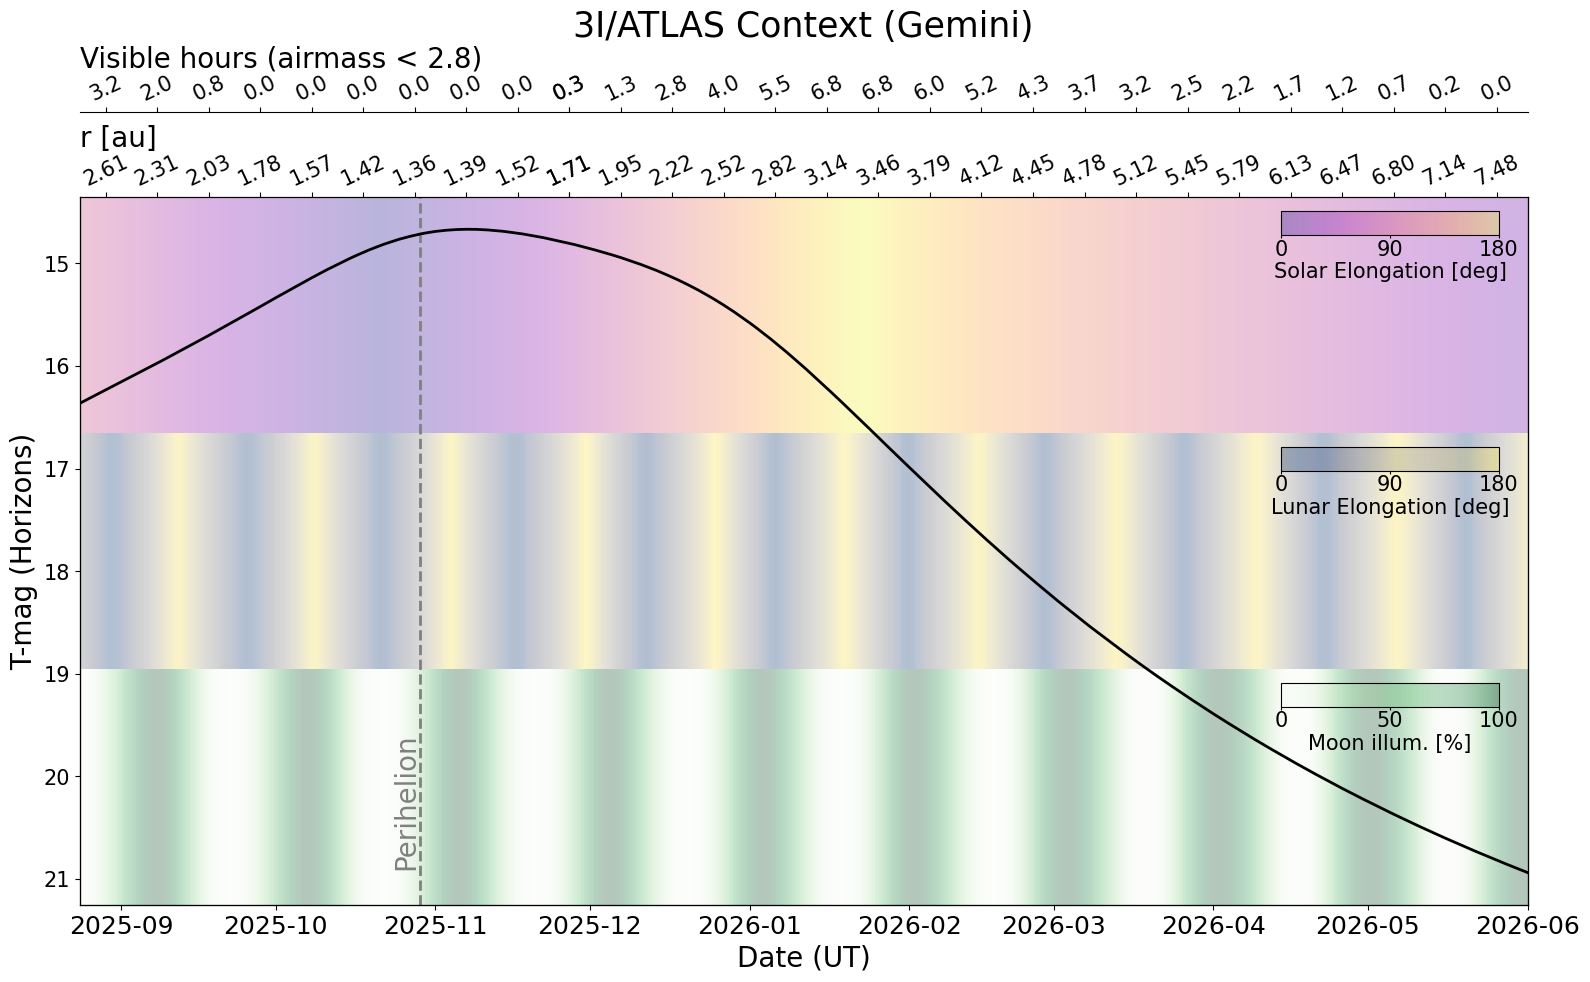

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory as btf
import matplotlib as mpl

# -------------------- Styling --------------------
mpl.rcParams['xtick.labelsize'] = 18

# -------------------- Parse columns --------------------
dt     = pd.to_datetime(df['Date__(UT)__HR:MN:SS'].astype(str).str.strip(), errors='coerce')
tmag   = pd.to_numeric(df['T-mag'],    errors='coerce')
r_au   = pd.to_numeric(df['r'],        errors='coerce')
amass  = pd.to_numeric(df['a-mass'],   errors='coerce')

# Background fields
SOT    = pd.to_numeric(df['S-O-T'],    errors='coerce')     # Solar elong. (deg)
TOM    = pd.to_numeric(df['T-O-M'],    errors='coerce')     # Moon elong. (deg)
MNpct  = pd.to_numeric(df['MN_Illu%'], errors='coerce')     # Moon illum. (%)

# Masks
m_plot = dt.notna() & np.isfinite(tmag)
m_r    = dt.notna() & np.isfinite(r_au)
m_am   = dt.notna() & np.isfinite(amass)

# -------------------- Figure --------------------
fig, axs = plt.subplots(1, 1, figsize=(16, 10))
ax = axs  # single Axes

# -------------------- Main line --------------------
(line,) = ax.plot(dt[m_plot], tmag[m_plot], label='T-mag', zorder=5, lw=2, c='k', alpha=1.0)

ax.set_ylabel("T-mag (Horizons)", fontsize=20)
ax.invert_yaxis()

# Bottom x ticks: YYYY-MM
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.margins(x=0)

# Lock limits from the line
xlim0 = ax.get_xlim()
ylim0 = ax.get_ylim()

# -------------------- Helpers --------------------
def sorted_time_series(mask, series):
    if mask.sum() < 2:
        return np.array([]), np.array([])
    x = mdates.date2num(pd.to_datetime(dt[mask]).to_numpy())
    y = pd.to_numeric(series[mask], errors='coerce').to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.array([]), np.array([])
    order = np.argsort(x[m])
    return x[m][order], y[m][order]

def time_for_value_linear(x_sorted, y_sorted, y_target):
    """
    Return x where y crosses y_target by linear interp if possible.
    Else return x at nearest y to y_target.
    """
    m = np.isfinite(x_sorted) & np.isfinite(y_sorted)
    x = x_sorted[m]; y = y_sorted[m]
    if x.size < 2:
        return np.nan
    s = np.sign(y - y_target)
    idx = np.where(s[:-1] * s[1:] <= 0)[0]
    if idx.size > 0:
        # choose the crossing segment closest to target
        diffs = np.minimum(np.abs(y[idx] - y_target), np.abs(y[idx+1] - y_target))
        i = int(idx[np.argmin(diffs)])
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 != y0:
            return x0 + (y_target - y0) * (x1 - x0) / (y1 - y0)
    # fallback: nearest
    j = int(np.nanargmin(np.abs(y - y_target)))
    return x[j]

def equal_ticks_with_anchor_cover_edges(xmin, xmax, N, anchor_x):
    """
    Build N equally spaced ticks over [xmin, xmax], forcing one tick at anchor_x (if possible).
    Preference order:
      1) last tick exactly at xmax (right-anchored),
      2) first tick exactly at xmin (left-anchored),
      3) interior equal ticks (no edges).
    """
    N = int(N)
    if not (np.isfinite(xmin) and np.isfinite(xmax)) or not (xmax > xmin) or N <= 0:
        return np.array([])

    # If anchor is invalid or out of range, just do edges-including equal spacing.
    if not (np.isfinite(anchor_x) and xmin <= anchor_x <= xmax):
        return np.linspace(xmin, xmax, N)

    # Which tick index will host the anchor? (0..N-1)
    i0 = int(np.clip(np.round((N - 1) * (anchor_x - xmin) / (xmax - xmin)), 0, N - 1))

    # --- Try RIGHT-anchored: last tick at xmax, anchor exact at i0
    if (N - 1 - i0) > 0:
        d_right = (xmax - anchor_x) / (N - 1 - i0)
        t0_right = anchor_x - i0 * d_right
        if t0_right >= xmin - 1e-12 and np.isfinite(d_right) and d_right > 0:
            ticks = t0_right + np.arange(N) * d_right
            # Numerical safety clamp
            ticks[0]  = max(ticks[0], xmin)
            ticks[-1] = min(ticks[-1], xmax)
            return ticks

    # --- Try LEFT-anchored: first tick at xmin, anchor exact at i0
    if i0 > 0:
        d_left = (anchor_x - xmin) / i0
        t_last_left = xmin + (N - 1) * d_left
        if t_last_left <= xmax + 1e-12 and np.isfinite(d_left) and d_left > 0:
            ticks = xmin + np.arange(N) * d_left
            ticks[0]  = xmin
            ticks[-1] = min(ticks[-1], xmax)
            return ticks

    # --- Fallback: interior equal ticks centered around anchor (no edges)
    # Choose step limited by both sides so everything stays inside.
    left_allow  = (anchor_x - xmin) / i0 if i0 > 0 else np.inf
    right_allow = (xmax - anchor_x) / (N - 1 - i0) if (N - 1 - i0) > 0 else np.inf
    d = min(left_allow, right_allow)
    if not (np.isfinite(d) and d > 0):
        return np.linspace(xmin, xmax, N)
    ticks = anchor_x + (np.arange(N) - i0) * d
    # Slightly nudge to avoid hitting the frame by round-off
    eps = 1e-9
    return np.clip(ticks, xmin + eps, xmax - eps)

# -------------------- Precompute series for top axes --------------------
x_r, r_r   = sorted_time_series(m_r,  r_au)

# Nightly visible hours series (from your 'result' table)
vis_dt   = pd.to_datetime(result['night_label'], errors='coerce')
vis_vals = pd.to_numeric(result['visible_hours'], errors='coerce')
m_vis = vis_dt.notna() & np.isfinite(vis_vals)
x_vis = mdates.date2num(vis_dt[m_vis].to_numpy()) if m_vis.sum() else np.array([])
y_vis = vis_vals[m_vis].to_numpy()                 if m_vis.sum() else np.array([])
if x_vis.size >= 2:
    order = np.argsort(x_vis)
    x_vis = x_vis[order]
    y_vis = y_vis[order]
# ===== Force a tick on 2025-11-27 and space equally every 5 days =====
anchor_date  = "2025-11-27"
spacing_days = 10.0  # change if you want a different spacing

xlim = ax.get_xlim()
anchor_x = mdates.date2num(pd.to_datetime(anchor_date))

# Build ticks: ... , anchor-10d, anchor-5d, anchor, anchor+5d, anchor+10d, ...
left  = np.arange(anchor_x, xlim[0] - spacing_days, -spacing_days)[::-1]
right = np.arange(anchor_x + spacing_days, xlim[1] + spacing_days, spacing_days)
ticks_time = np.r_[left, anchor_x, right]
# keep only ticks inside the current x-limits
ticks_time = ticks_time[(ticks_time >= xlim[0]) & (ticks_time <= xlim[1])]

# ===== Top X #1 (inner): r [au] at those dates =====
m_r = dt.notna() & np.isfinite(r_au)
x_r = mdates.date2num(pd.to_datetime(dt[m_r]).to_numpy())
y_r = pd.to_numeric(r_au[m_r], errors='coerce').to_numpy()
m_ok = np.isfinite(x_r) & np.isfinite(y_r)
x_r = x_r[m_ok]; y_r = y_r[m_ok]
order = np.argsort(x_r); x_r = x_r[order]; y_r = y_r[order]

tw_r = ax.twiny()
tw_r.set_xlim(xlim)
tw_r.set_xlabel('r [au]', loc='left', fontsize=20)

if x_r.size >= 2:
    r_on_ticks = np.interp(ticks_time, x_r, y_r, left=y_r[0], right=y_r[-1])
    tw_r.set_xticks(mdates.num2date(ticks_time))
    tw_r.set_xticklabels([f"{v:.2f}" for v in r_on_ticks])
    tw_r.tick_params(axis='x', labelsize=15, pad=2, labelrotation=25)

# ===== Top X #2 (outer): Visible hours at those dates =====
vis_dt   = pd.to_datetime(result['night_label'], errors='coerce')
vis_vals = pd.to_numeric(result['visible_hours'], errors='coerce')
m_vis = vis_dt.notna() & np.isfinite(vis_vals)

x_vis = mdates.date2num(vis_dt[m_vis].to_numpy()) if m_vis.any() else np.array([])
y_vis = vis_vals[m_vis].to_numpy()                 if m_vis.any() else np.array([])
if x_vis.size >= 2:
    order = np.argsort(x_vis)
    x_vis = x_vis[order]; y_vis = y_vis[order]

tw_vis_ax = ax.twiny()
tw_vis_ax.set_xlim(xlim)
tw_vis_ax.set_xlabel('Visible hours (airmass < 2.8)', loc='left', fontsize=20)
tw_vis_ax.spines['top'].set_position(('axes', 1.12))
tw_vis_ax.xaxis.set_ticks_position('top')
tw_vis_ax.xaxis.set_label_position('top')

if x_vis.size >= 2:
    vis_on_ticks = np.interp(ticks_time, x_vis, y_vis, left=y_vis[0], right=y_vis[-1])
elif x_vis.size == 1:
    vis_on_ticks = np.full_like(ticks_time, y_vis[0], dtype=float)
else:
    vis_on_ticks = np.full_like(ticks_time, np.nan, dtype=float)

tw_vis_ax.set_xticks(mdates.num2date(ticks_time))
tw_vis_ax.set_xticklabels([f"{v:.1f}" if np.isfinite(v) else "" for v in vis_on_ticks])
tw_vis_ax.tick_params(axis='x', labelsize=15, pad=2, labelrotation=25)




# -------------------- Background strips --------------------
trans = btf(ax.transData, ax.transAxes)
xmin, xmax = xlim0

def add_strip_fill(x_src_dt, val_series, y0, y1, cmap, vmin=None, vmax=None, alpha=0.30, zorder=-10):
    x_src = mdates.date2num(pd.to_datetime(x_src_dt).to_numpy())
    z_src = pd.to_numeric(val_series, errors='coerce').to_numpy()
    m = np.isfinite(x_src) & np.isfinite(z_src)
    if m.sum() < 2:
        return None
    grid = np.linspace(xmin, xmax, 1000)
    z_interp = np.interp(grid, x_src[m], z_src[m], left=z_src[m][0], right=z_src[m][-1])
    im = ax.imshow(
        z_interp[np.newaxis, :],
        extent=[xmin, xmax, y0, y1],
        transform=trans,
        aspect='auto',
        cmap=cmap, vmin=vmin, vmax=vmax,
        alpha=alpha,
        interpolation='nearest',
        zorder=zorder
    )
    return im

im_sot = add_strip_fill(dt, SOT,   y0=2/3, y1=1.00, cmap='plasma',  vmin=0,  vmax=180, alpha=0.30, zorder=-10)
im_tom = add_strip_fill(dt, TOM,   y0=1/3,  y1=2/3,  cmap='cividis', vmin=0,  vmax=180, alpha=0.30, zorder=-10)
im_mnp = add_strip_fill(dt, MNpct, y0=0.00, y1=1/3,  cmap='Greens',  vmin=0,  vmax=100, alpha=0.30, zorder=-10)

def add_cbar_inset_horizontal(im, y0, y1, label=None, n_ticks=3):
    if im is None:
        return None
    stripe_h = y1 - y0
    cb_w = 0.15
    cb_h = stripe_h * 0.10
    pad  = 0.02
    x0_cb = 1.0 - cb_w - pad
    y0_cb = y1 - cb_h - pad
    cax = ax.inset_axes([x0_cb, y0_cb, cb_w, cb_h])
    try:
        cax.set_facecolor('none')
        cax.patch.set_alpha(0.0)
    except Exception:
        pass
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_ticks_position('bottom')
    cbar.ax.xaxis.set_label_position('bottom')
    if label:
        cbar.set_label(label, fontsize=15, labelpad=2)
    vmin = float(im.norm.vmin) if hasattr(im, "norm") else None
    vmax = float(im.norm.vmax) if hasattr(im, "norm") else None
    if vmin is not None and vmax is not None and n_ticks >= 2:
        cbar.set_ticks(np.linspace(vmin, vmax, n_ticks))
    cbar.ax.tick_params(labelsize=15, length=2, pad=1)
    return cbar

add_cbar_inset_horizontal(im_sot, 2/3, 1.00, label='Solar Elongation [deg]', n_ticks=3)
add_cbar_inset_horizontal(im_tom, 1/3, 2/3,  label='Lunar Elongation [deg]', n_ticks=3)
add_cbar_inset_horizontal(im_mnp, 0.00, 1/3, label='Moon illum. [%]',        n_ticks=3)

# -------------------- Final touches --------------------
ax.set_xlim(xlim0)
ax.set_ylim(ylim0)
ax.set_xlabel("Date (UT)", fontsize=20)
ax.set_title("3I/ATLAS Context (Gemini)", fontsize=25)

# add a vertical line at the periheloin date, get the periheloib date from JPL Horizons df (ie when r is minimum)

peri_idx = r_au.idxmin()
peri_date = pd.to_datetime(df.loc[peri_idx, 'Date__(UT)__HR:MN:SS'], errors='coerce')
if pd.isna(peri_date):
    print("Could not determine perihelion date.")
else:
    ax.axvline(mdates.date2num(peri_date), color='gray', linestyle='--', lw=2)
    ax.text(mdates.date2num(peri_date), ylim0[0] + 0.05*(ylim0[1]-ylim0[0]), 'Perihelion', rotation=90,
            verticalalignment='bottom', horizontalalignment='right', color='gray', fontsize=20)

plt.tight_layout()
plt.savefig('comet_horizons_tmag_gemini.png', dpi=300)
plt.show()


In [168]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

horizons_path = 'horizons_results.txt'
df = pd.read_csv(horizons_path, skipinitialspace=True)

df.columns = [
    (col.strip() if isinstance(col, str) else col) or f'Unnamed_{idx}'
    for idx, col in enumerate(df.columns)
]

# Strip whitespace padding in string columns for easier downstream use
object_cols = df.select_dtypes(include='object').columns
if len(object_cols):
    df[object_cols] = df[object_cols].apply(lambda col: col.str.strip())

df.head()

horizons_path2 = 'horizons_results_2.txt'
df2 = pd.read_csv(horizons_path2, skipinitialspace=True)
df2.columns = [
    (col.strip() if isinstance(col, str) else col) or f'Unnamed_{idx}'
    for idx, col in enumerate(df2.columns)
]  
object_cols2 = df2.select_dtypes(include='object').columns
if len(object_cols2):
    df2[object_cols2] = df2[object_cols2].apply(lambda col: col.str.strip())

sun_path = 'sun.txt'

df_sun = pd.read_csv(sun_path, skipinitialspace=True)
df_sun.columns = [
    (col.strip() if isinstance(col, str) else col) or f'Unnamed_{idx}'
    for idx, col in enumerate(df_sun.columns)
]
object_cols_sun = df_sun.select_dtypes(include='object').columns
if len(object_cols_sun):
    df_sun[object_cols_sun] = df_sun[object_cols_sun].apply(lambda col: col.str.strip())

def _to_float_series(s):
    """Robustly pull the first float-looking number from each cell."""
    return pd.to_numeric(
        s.astype(str).str.extract(r'([-+]?\d+(?:\.\d+)?)', expand=False),
        errors='coerce'
    )

def _first_present(df, candidates):
    """Return the first existing column name from candidates, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

def visible_hours_per_night(df_target, df_sun,
                            airmax=2.8,
                            buffer_hours=1,
                            sun_elev_thresh_deg=0):  # use -18 for astronomical night
    """
    df_target columns needed:
        'Date__(UT)__HR:MN:SS', 'a-mass', and a Tmag column named one of:
        'T-mag' or 'Tmag' or 'T_mag' (optional but required for mean_Tmag)
    df_sun columns needed:
        'Date__(UT)__HR:MN:SS', 'Elevation_(a-app)'

    Returns:
        night_label | visible_hours | usable_hours | mean_Tmag
    """
    df_sun = df_sun.copy()
    df_target = df_target.copy()

    # ---- 1) Parse timestamps and sort
    for df in (df_sun, df_target):
        df['t'] = pd.to_datetime(df['Date__(UT)__HR:MN:SS'], utc=True, errors='coerce')
        df.dropna(subset=['t'], inplace=True)
        df.sort_values('t', inplace=True)

    # ---- 2) Coerce numeric columns
    df_sun['sun_elev'] = _to_float_series(df_sun['Elevation_(a-app)'])
    df_target['airmass'] = _to_float_series(df_target['a-mass'])

    # Tmag: try common variants; if none present, we'll produce NaNs later
    tmag_col = _first_present(df_target, ['T-mag', 'Tmag', 'T_mag'])
    if tmag_col is not None:
        df_target['Tmag'] = _to_float_series(df_target[tmag_col])
    else:
        df_target['Tmag'] = np.nan  # so code runs even if missing

    # ---- 3) Night detection from Sun elevation
    df_sun['sun_below'] = df_sun['sun_elev'] < sun_elev_thresh_deg
    df_sun['block'] = df_sun['sun_below'].ne(df_sun['sun_below'].shift()).cumsum()

    nights = (
        df_sun[df_sun['sun_below']]
        .groupby('block', as_index=False)
        .agg(night_start=('t', 'min'), night_end=('t', 'max'))
        .drop(columns='block')
    )

    if nights.empty:
        return pd.DataFrame(columns=['night_label', 'visible_hours', 'usable_hours', 'mean_Tmag'])

    # ---- 4) Usable windows: sunset+buffer … dawn-buffer
    buf = pd.Timedelta(hours=buffer_hours)
    nights['usable_start'] = nights['night_start'] + buf
    nights['usable_end']   = nights['night_end']   - buf
    nights = nights[nights['usable_end'] > nights['usable_start']].reset_index(drop=True)

    if nights.empty:
        return pd.DataFrame(columns=['night_label', 'visible_hours', 'usable_hours', 'mean_Tmag'])

    nights['night_label'] = nights['usable_start'].dt.date.astype(str)
    nights['usable_hours'] = (nights['usable_end'] - nights['usable_start']).dt.total_seconds() / 3600.0

    # ---- 5) Map target samples to usable-night intervals
    ii = pd.IntervalIndex.from_arrays(nights['usable_start'], nights['usable_end'], closed='both')
    night_idx = ii.get_indexer(df_target['t'])
    tgt = df_target[night_idx != -1].copy()
    if tgt.empty:
        out = nights[['night_label', 'usable_hours']].copy()
        out['visible_hours'] = 0.0
        out['mean_Tmag'] = np.nan
        return out[['night_label', 'visible_hours', 'usable_hours', 'mean_Tmag']]

    tgt['night_idx'] = night_idx[night_idx != -1]

    # ---- 6) dt to next sample (only within same night)
    tgt['t_next'] = tgt.groupby('night_idx')['t'].shift(-1)
    same_night_next = tgt['night_idx'] == tgt.groupby('night_idx')['night_idx'].shift(-1)
    dt_s = (tgt['t_next'] - tgt['t']).dt.total_seconds()
    dt_s = dt_s.where(same_night_next, 0).clip(lower=0)

    # ---- 7) Visibility mask by airmass (no target elevation available)
    vis_now  = tgt['airmass'].le(airmax)
    vis_next = tgt.groupby('night_idx')['airmass'].shift(-1).le(airmax)
    vis_interval = same_night_next & vis_now & vis_next & tgt['t_next'].notna()

    # ---- 8) Visible hours per night
    tgt['dt_visible_h'] = (dt_s / 3600.0).where(vis_interval, 0.0)
    visible_hours = (tgt.groupby('night_idx')['dt_visible_h'].sum()
                       .reindex(range(len(nights)), fill_value=0.0)
                       .reset_index(name='visible_hours'))

    # ---- 9) Time-weighted mean Tmag over visible intervals (trapezoid rule)
    tmag_now  = tgt['Tmag']
    tmag_next = tgt.groupby('night_idx')['Tmag'].shift(-1)
    tmag_ok = tmag_now.notna() & tmag_next.notna()

    valid = vis_interval & tmag_ok
    # trapezoid integral over each interval
    tmag_num = ((tmag_now + tmag_next) / 2.0 * dt_s).where(valid, 0.0)
    tmag_den = dt_s.where(valid, 0.0)

    num_by_night = tmag_num.groupby(tgt['night_idx']).sum()
    den_by_night = tmag_den.groupby(tgt['night_idx']).sum()

    mean_tmag = (num_by_night / den_by_night).reindex(range(len(nights)))
    # if no valid Tmag during visible time, leave as NaN

    # ---- 10) Assemble output
    out = pd.concat(
        [nights[['night_label', 'usable_hours']].reset_index(drop=True),
         visible_hours['visible_hours'],
         mean_tmag.reset_index(drop=True).rename('mean_Tmag')],
        axis=1
    ).sort_values('night_label').reset_index(drop=True)

    return out

# Example:
result = visible_hours_per_night(df2, df_sun, airmax=2.8, buffer_hours=1, sun_elev_thresh_deg=0)
# result


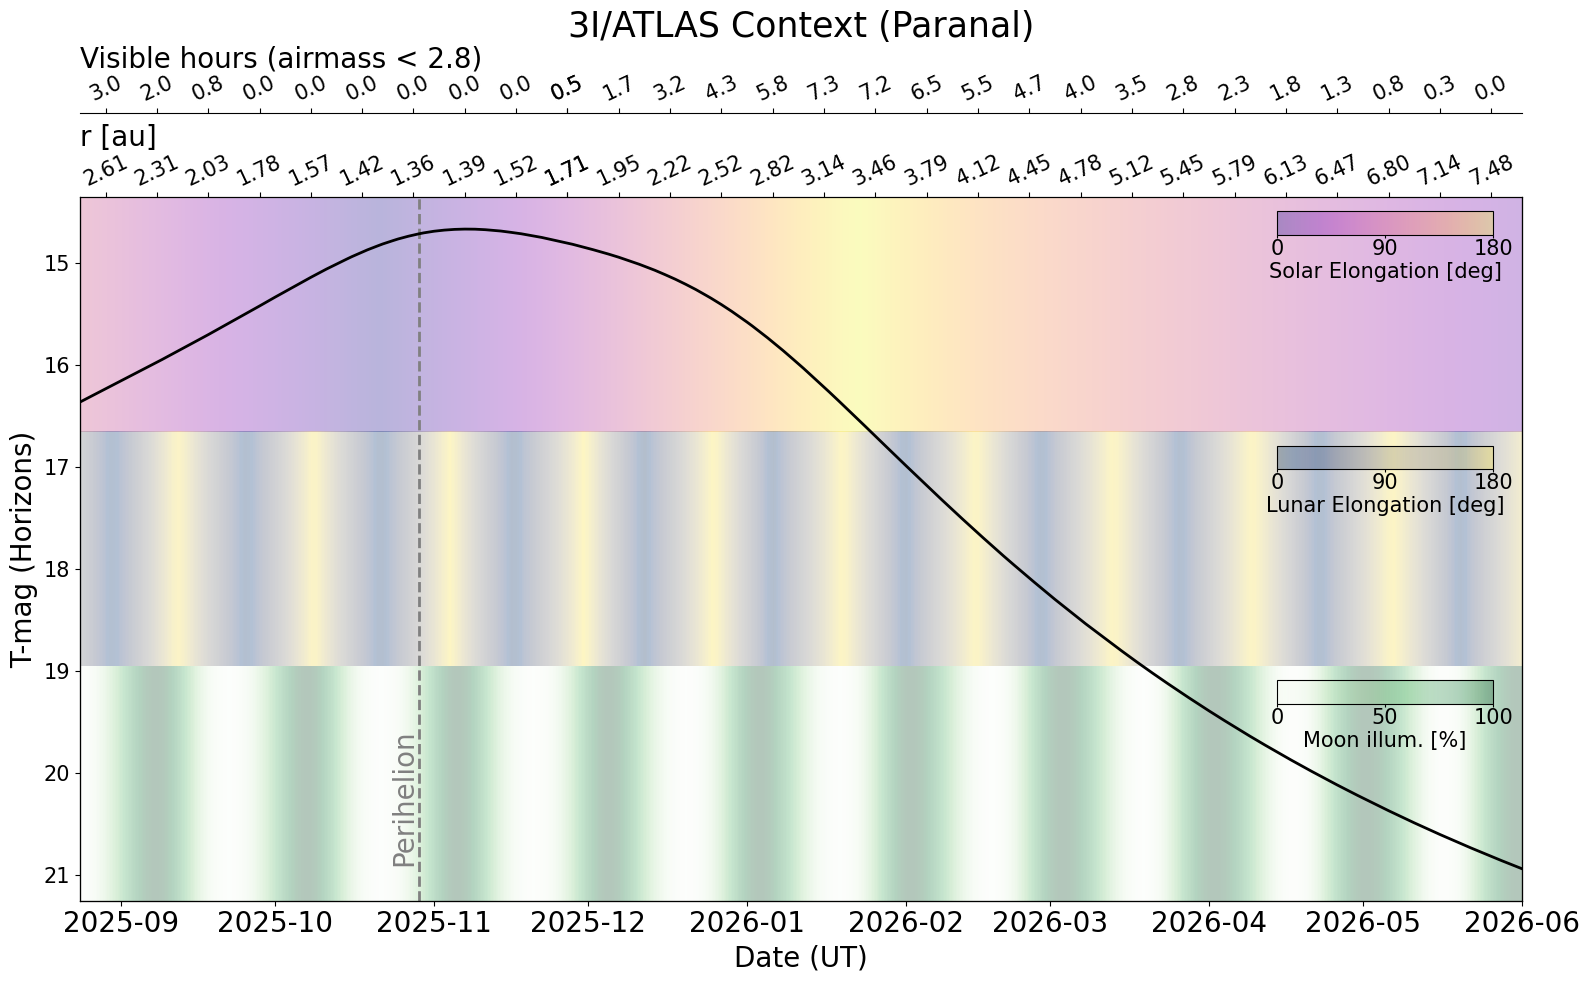

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory as btf
import matplotlib as mpl

# -------------------- Styling --------------------
mpl.rcParams['xtick.labelsize'] = 18

# -------------------- Parse columns --------------------
dt     = pd.to_datetime(df['Date__(UT)__HR:MN:SS'].astype(str).str.strip(), errors='coerce')
tmag   = pd.to_numeric(df['T-mag'],    errors='coerce')
r_au   = pd.to_numeric(df['r'],        errors='coerce')
amass  = pd.to_numeric(df['a-mass'],   errors='coerce')

# Background fields
SOT    = pd.to_numeric(df['S-O-T'],    errors='coerce')     # Solar elong. (deg)
TOM    = pd.to_numeric(df['T-O-M'],    errors='coerce')     # Moon elong. (deg)
MNpct  = pd.to_numeric(df['MN_Illu%'], errors='coerce')     # Moon illum. (%)

# Masks
m_plot = dt.notna() & np.isfinite(tmag)
m_r    = dt.notna() & np.isfinite(r_au)
m_am   = dt.notna() & np.isfinite(amass)

# -------------------- Figure --------------------
fig, axs = plt.subplots(1, 1, figsize=(16, 10))
ax = axs  # single Axes

# -------------------- Main line --------------------
(line,) = ax.plot(dt[m_plot], tmag[m_plot], label='T-mag', zorder=5, lw=2, c='k', alpha=1.0)

ax.set_ylabel("T-mag (Horizons)", fontsize=20)
ax.invert_yaxis()

# Bottom x ticks: YYYY-MM
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.margins(x=0)

# Lock limits from the line
xlim0 = ax.get_xlim()
ylim0 = ax.get_ylim()

# -------------------- Helpers --------------------
def sorted_time_series(mask, series):
    if mask.sum() < 2:
        return np.array([]), np.array([])
    x = mdates.date2num(pd.to_datetime(dt[mask]).to_numpy())
    y = pd.to_numeric(series[mask], errors='coerce').to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.array([]), np.array([])
    order = np.argsort(x[m])
    return x[m][order], y[m][order]

def time_for_value_linear(x_sorted, y_sorted, y_target):
    """
    Return x where y crosses y_target by linear interp if possible.
    Else return x at nearest y to y_target.
    """
    m = np.isfinite(x_sorted) & np.isfinite(y_sorted)
    x = x_sorted[m]; y = y_sorted[m]
    if x.size < 2:
        return np.nan
    s = np.sign(y - y_target)
    idx = np.where(s[:-1] * s[1:] <= 0)[0]
    if idx.size > 0:
        # choose the crossing segment closest to target
        diffs = np.minimum(np.abs(y[idx] - y_target), np.abs(y[idx+1] - y_target))
        i = int(idx[np.argmin(diffs)])
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 != y0:
            return x0 + (y_target - y0) * (x1 - x0) / (y1 - y0)
    # fallback: nearest
    j = int(np.nanargmin(np.abs(y - y_target)))
    return x[j]

def equal_ticks_with_anchor_cover_edges(xmin, xmax, N, anchor_x):
    """
    Build N equally spaced ticks over [xmin, xmax], forcing one tick at anchor_x (if possible).
    Preference order:
      1) last tick exactly at xmax (right-anchored),
      2) first tick exactly at xmin (left-anchored),
      3) interior equal ticks (no edges).
    """
    N = int(N)
    if not (np.isfinite(xmin) and np.isfinite(xmax)) or not (xmax > xmin) or N <= 0:
        return np.array([])

    # If anchor is invalid or out of range, just do edges-including equal spacing.
    if not (np.isfinite(anchor_x) and xmin <= anchor_x <= xmax):
        return np.linspace(xmin, xmax, N)

    # Which tick index will host the anchor? (0..N-1)
    i0 = int(np.clip(np.round((N - 1) * (anchor_x - xmin) / (xmax - xmin)), 0, N - 1))

    # --- Try RIGHT-anchored: last tick at xmax, anchor exact at i0
    if (N - 1 - i0) > 0:
        d_right = (xmax - anchor_x) / (N - 1 - i0)
        t0_right = anchor_x - i0 * d_right
        if t0_right >= xmin - 1e-12 and np.isfinite(d_right) and d_right > 0:
            ticks = t0_right + np.arange(N) * d_right
            # Numerical safety clamp
            ticks[0]  = max(ticks[0], xmin)
            ticks[-1] = min(ticks[-1], xmax)
            return ticks

    # --- Try LEFT-anchored: first tick at xmin, anchor exact at i0
    if i0 > 0:
        d_left = (anchor_x - xmin) / i0
        t_last_left = xmin + (N - 1) * d_left
        if t_last_left <= xmax + 1e-12 and np.isfinite(d_left) and d_left > 0:
            ticks = xmin + np.arange(N) * d_left
            ticks[0]  = xmin
            ticks[-1] = min(ticks[-1], xmax)
            return ticks

    # --- Fallback: interior equal ticks centered around anchor (no edges)
    # Choose step limited by both sides so everything stays inside.
    left_allow  = (anchor_x - xmin) / i0 if i0 > 0 else np.inf
    right_allow = (xmax - anchor_x) / (N - 1 - i0) if (N - 1 - i0) > 0 else np.inf
    d = min(left_allow, right_allow)
    if not (np.isfinite(d) and d > 0):
        return np.linspace(xmin, xmax, N)
    ticks = anchor_x + (np.arange(N) - i0) * d
    # Slightly nudge to avoid hitting the frame by round-off
    eps = 1e-9
    return np.clip(ticks, xmin + eps, xmax - eps)

# -------------------- Precompute series for top axes --------------------
x_r, r_r   = sorted_time_series(m_r,  r_au)

# Nightly visible hours series (from your 'result' table)
vis_dt   = pd.to_datetime(result['night_label'], errors='coerce')
vis_vals = pd.to_numeric(result['visible_hours'], errors='coerce')
m_vis = vis_dt.notna() & np.isfinite(vis_vals)
x_vis = mdates.date2num(vis_dt[m_vis].to_numpy()) if m_vis.sum() else np.array([])
y_vis = vis_vals[m_vis].to_numpy()                 if m_vis.sum() else np.array([])
if x_vis.size >= 2:
    order = np.argsort(x_vis)
    x_vis = x_vis[order]
    y_vis = y_vis[order]
# ===== Force a tick on 2025-11-27 and space equally every 5 days =====
anchor_date  = "2025-11-27"
spacing_days = 10.0  # change if you want a different spacing

xlim = ax.get_xlim()
anchor_x = mdates.date2num(pd.to_datetime(anchor_date))

# Build ticks: ... , anchor-10d, anchor-5d, anchor, anchor+5d, anchor+10d, ...
left  = np.arange(anchor_x, xlim[0] - spacing_days, -spacing_days)[::-1]
right = np.arange(anchor_x + spacing_days, xlim[1] + spacing_days, spacing_days)
ticks_time = np.r_[left, anchor_x, right]
# keep only ticks inside the current x-limits
ticks_time = ticks_time[(ticks_time >= xlim[0]) & (ticks_time <= xlim[1])]

# ===== Top X #1 (inner): r [au] at those dates =====
m_r = dt.notna() & np.isfinite(r_au)
x_r = mdates.date2num(pd.to_datetime(dt[m_r]).to_numpy())
y_r = pd.to_numeric(r_au[m_r], errors='coerce').to_numpy()
m_ok = np.isfinite(x_r) & np.isfinite(y_r)
x_r = x_r[m_ok]; y_r = y_r[m_ok]
order = np.argsort(x_r); x_r = x_r[order]; y_r = y_r[order]

tw_r = ax.twiny()
tw_r.set_xlim(xlim)
tw_r.set_xlabel('r [au]', loc='left', fontsize=20)

if x_r.size >= 2:
    r_on_ticks = np.interp(ticks_time, x_r, y_r, left=y_r[0], right=y_r[-1])
    tw_r.set_xticks(mdates.num2date(ticks_time))
    tw_r.set_xticklabels([f"{v:.2f}" for v in r_on_ticks])
    tw_r.tick_params(axis='x', labelsize=15, pad=2, labelrotation=25)

# ===== Top X #2 (outer): Visible hours at those dates =====
vis_dt   = pd.to_datetime(result['night_label'], errors='coerce')
vis_vals = pd.to_numeric(result['visible_hours'], errors='coerce')
m_vis = vis_dt.notna() & np.isfinite(vis_vals)

x_vis = mdates.date2num(vis_dt[m_vis].to_numpy()) if m_vis.any() else np.array([])
y_vis = vis_vals[m_vis].to_numpy()                 if m_vis.any() else np.array([])
if x_vis.size >= 2:
    order = np.argsort(x_vis)
    x_vis = x_vis[order]; y_vis = y_vis[order]

tw_vis_ax = ax.twiny()
tw_vis_ax.set_xlim(xlim)
tw_vis_ax.set_xlabel('Visible hours (airmass < 2.8)', loc='left', fontsize=20)
tw_vis_ax.spines['top'].set_position(('axes', 1.12))
tw_vis_ax.xaxis.set_ticks_position('top')
tw_vis_ax.xaxis.set_label_position('top')

if x_vis.size >= 2:
    vis_on_ticks = np.interp(ticks_time, x_vis, y_vis, left=y_vis[0], right=y_vis[-1])
elif x_vis.size == 1:
    vis_on_ticks = np.full_like(ticks_time, y_vis[0], dtype=float)
else:
    vis_on_ticks = np.full_like(ticks_time, np.nan, dtype=float)

tw_vis_ax.set_xticks(mdates.num2date(ticks_time))
tw_vis_ax.set_xticklabels([f"{v:.1f}" if np.isfinite(v) else "" for v in vis_on_ticks])
tw_vis_ax.tick_params(axis='x', labelsize=15, pad=2, labelrotation=25)




# -------------------- Background strips --------------------
trans = btf(ax.transData, ax.transAxes)
xmin, xmax = xlim0

def add_strip_fill(x_src_dt, val_series, y0, y1, cmap, vmin=None, vmax=None, alpha=0.30, zorder=-10):
    x_src = mdates.date2num(pd.to_datetime(x_src_dt).to_numpy())
    z_src = pd.to_numeric(val_series, errors='coerce').to_numpy()
    m = np.isfinite(x_src) & np.isfinite(z_src)
    if m.sum() < 2:
        return None
    grid = np.linspace(xmin, xmax, 1000)
    z_interp = np.interp(grid, x_src[m], z_src[m], left=z_src[m][0], right=z_src[m][-1])
    im = ax.imshow(
        z_interp[np.newaxis, :],
        extent=[xmin, xmax, y0, y1],
        transform=trans,
        aspect='auto',
        cmap=cmap, vmin=vmin, vmax=vmax,
        alpha=alpha,
        interpolation='nearest',
        zorder=zorder
    )
    return im

im_sot = add_strip_fill(dt, SOT,   y0=2/3, y1=1.00, cmap='plasma',  vmin=0,  vmax=180, alpha=0.30, zorder=-10)
im_tom = add_strip_fill(dt, TOM,   y0=1/3,  y1=2/3,  cmap='cividis', vmin=0,  vmax=180, alpha=0.30, zorder=-10)
im_mnp = add_strip_fill(dt, MNpct, y0=0.00, y1=1/3,  cmap='Greens',  vmin=0,  vmax=100, alpha=0.30, zorder=-10)

def add_cbar_inset_horizontal(im, y0, y1, label=None, n_ticks=3):
    if im is None:
        return None
    stripe_h = y1 - y0
    cb_w = 0.15
    cb_h = stripe_h * 0.10
    pad  = 0.02
    x0_cb = 1.0 - cb_w - pad
    y0_cb = y1 - cb_h - pad
    cax = ax.inset_axes([x0_cb, y0_cb, cb_w, cb_h])
    try:
        cax.set_facecolor('none')
        cax.patch.set_alpha(0.0)
    except Exception:
        pass
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_ticks_position('bottom')
    cbar.ax.xaxis.set_label_position('bottom')
    if label:
        cbar.set_label(label, fontsize=15, labelpad=2)
    vmin = float(im.norm.vmin) if hasattr(im, "norm") else None
    vmax = float(im.norm.vmax) if hasattr(im, "norm") else None
    if vmin is not None and vmax is not None and n_ticks >= 2:
        cbar.set_ticks(np.linspace(vmin, vmax, n_ticks))
    cbar.ax.tick_params(labelsize=15, length=2, pad=1)
    return cbar

add_cbar_inset_horizontal(im_sot, 2/3, 1.00, label='Solar Elongation [deg]', n_ticks=3)
add_cbar_inset_horizontal(im_tom, 1/3, 2/3,  label='Lunar Elongation [deg]', n_ticks=3)
add_cbar_inset_horizontal(im_mnp, 0.00, 1/3, label='Moon illum. [%]',        n_ticks=3)

# -------------------- Final touches --------------------
ax.set_xlim(xlim0)
ax.set_ylim(ylim0)
ax.set_xlabel("Date (UT)", fontsize=20)
ax.set_title("3I/ATLAS Context (Paranal)", fontsize=25)

# add a vertical line at the periheloin date, get the periheloib date from JPL Horizons df (ie when r is minimum)

peri_idx = r_au.idxmin()
peri_date = pd.to_datetime(df.loc[peri_idx, 'Date__(UT)__HR:MN:SS'], errors='coerce')
if pd.isna(peri_date):
    print("Could not determine perihelion date.")
else:
    ax.axvline(mdates.date2num(peri_date), color='gray', linestyle='--', lw=2)
    ax.text(mdates.date2num(peri_date), ylim0[0] + 0.05*(ylim0[1]-ylim0[0]), 'Perihelion', rotation=90,
            verticalalignment='bottom', horizontalalignment='right', color='gray', fontsize=20)

plt.tight_layout()
plt.savefig('comet_horizons_tmag_paranal.png', dpi=300)
plt.show()


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory as btf
import matplotlib as mpl

# -------------------- Styling --------------------
mpl.rcParams['xtick.labelsize'] = 18

# -------------------- Parse columns --------------------
dt     = pd.to_datetime(df['Date__(UT)__HR:MN:SS'].astype(str).str.strip(), errors='coerce')
tmag   = pd.to_numeric(df['T-mag'],    errors='coerce')
r_au   = pd.to_numeric(df['r'],        errors='coerce')
amass  = pd.to_numeric(df['a-mass'],   errors='coerce')

# Background fields
SOT    = pd.to_numeric(df['S-O-T'],    errors='coerce')     # Solar elong. (deg)
TOM    = pd.to_numeric(df['T-O-M'],    errors='coerce')     # Moon elong. (deg)
MNpct  = pd.to_numeric(df['MN_Illu%'], errors='coerce')     # Moon illum. (%)

# Masks
m_plot = dt.notna() & np.isfinite(tmag)
m_r    = dt.notna() & np.isfinite(r_au)
m_am   = dt.notna() & np.isfinite(amass)

# -------------------- Figure --------------------
fig, axs = plt.subplots(1, 3, figsize=(25, 8))
ax = axs[0]  # single Axes

# -------------------- Main line --------------------
(line,) = ax.plot(dt[m_plot], tmag[m_plot], label='T-mag', zorder=5, lw=2, c='k', alpha=1.0)

ax.set_ylabel("T-mag (Horizons)", fontsize=20)
ax.invert_yaxis()

# Bottom x ticks: YYYY-MM
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m'))

ax.margins(x=0)

# Lock limits from the line
xlim0 = ax.get_xlim()
ylim0 = ax.get_ylim()

# -------------------- Helpers --------------------
def sorted_time_series(mask, series):
    if mask.sum() < 2:
        return np.array([]), np.array([])
    x = mdates.date2num(pd.to_datetime(dt[mask]).to_numpy())
    y = pd.to_numeric(series[mask], errors='coerce').to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.array([]), np.array([])
    order = np.argsort(x[m])
    return x[m][order], y[m][order]

def time_for_value_linear(x_sorted, y_sorted, y_target):
    """
    Return x where y crosses y_target by linear interp if possible.
    Else return x at nearest y to y_target.
    """
    m = np.isfinite(x_sorted) & np.isfinite(y_sorted)
    x = x_sorted[m]; y = y_sorted[m]
    if x.size < 2:
        return np.nan
    s = np.sign(y - y_target)
    idx = np.where(s[:-1] * s[1:] <= 0)[0]
    if idx.size > 0:
        # choose the crossing segment closest to target
        diffs = np.minimum(np.abs(y[idx] - y_target), np.abs(y[idx+1] - y_target))
        i = int(idx[np.argmin(diffs)])
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 != y0:
            return x0 + (y_target - y0) * (x1 - x0) / (y1 - y0)
    # fallback: nearest
    j = int(np.nanargmin(np.abs(y - y_target)))
    return x[j]

def equal_ticks_with_anchor_cover_edges(xmin, xmax, N, anchor_x):
    """
    Build N equally spaced ticks over [xmin, xmax], forcing one tick at anchor_x (if possible).
    Preference order:
      1) last tick exactly at xmax (right-anchored),
      2) first tick exactly at xmin (left-anchored),
      3) interior equal ticks (no edges).
    """
    N = int(N)
    if not (np.isfinite(xmin) and np.isfinite(xmax)) or not (xmax > xmin) or N <= 0:
        return np.array([])

    # If anchor is invalid or out of range, just do edges-including equal spacing.
    if not (np.isfinite(anchor_x) and xmin <= anchor_x <= xmax):
        return np.linspace(xmin, xmax, N)

    # Which tick index will host the anchor? (0..N-1)
    i0 = int(np.clip(np.round((N - 1) * (anchor_x - xmin) / (xmax - xmin)), 0, N - 1))

    # --- Try RIGHT-anchored: last tick at xmax, anchor exact at i0
    if (N - 1 - i0) > 0:
        d_right = (xmax - anchor_x) / (N - 1 - i0)
        t0_right = anchor_x - i0 * d_right
        if t0_right >= xmin - 1e-12 and np.isfinite(d_right) and d_right > 0:
            ticks = t0_right + np.arange(N) * d_right
            # Numerical safety clamp
            ticks[0]  = max(ticks[0], xmin)
            ticks[-1] = min(ticks[-1], xmax)
            return ticks

    # --- Try LEFT-anchored: first tick at xmin, anchor exact at i0
    if i0 > 0:
        d_left = (anchor_x - xmin) / i0
        t_last_left = xmin + (N - 1) * d_left
        if t_last_left <= xmax + 1e-12 and np.isfinite(d_left) and d_left > 0:
            ticks = xmin + np.arange(N) * d_left
            ticks[0]  = xmin
            ticks[-1] = min(ticks[-1], xmax)
            return ticks

    # --- Fallback: interior equal ticks centered around anchor (no edges)
    # Choose step limited by both sides so everything stays inside.
    left_allow  = (anchor_x - xmin) / i0 if i0 > 0 else np.inf
    right_allow = (xmax - anchor_x) / (N - 1 - i0) if (N - 1 - i0) > 0 else np.inf
    d = min(left_allow, right_allow)
    if not (np.isfinite(d) and d > 0):
        return np.linspace(xmin, xmax, N)
    ticks = anchor_x + (np.arange(N) - i0) * d
    # Slightly nudge to avoid hitting the frame by round-off
    eps = 1e-9
    return np.clip(ticks, xmin + eps, xmax - eps)

# -------------------- Precompute series for top axes --------------------
x_r, r_r   = sorted_time_series(m_r,  r_au)

# Nightly visible hours series (from your 'result' table)
vis_dt   = pd.to_datetime(result['night_label'], errors='coerce')
vis_vals = pd.to_numeric(result['visible_hours'], errors='coerce')
m_vis = vis_dt.notna() & np.isfinite(vis_vals)
x_vis = mdates.date2num(vis_dt[m_vis].to_numpy()) if m_vis.sum() else np.array([])
y_vis = vis_vals[m_vis].to_numpy()                 if m_vis.sum() else np.array([])
if x_vis.size >= 2:
    order = np.argsort(x_vis)
    x_vis = x_vis[order]
    y_vis = y_vis[order]
# ===== Force a tick on 2025-11-27 and space equally every 5 days =====
anchor_date  = "2025-11-27"
spacing_days = 20.0  # change if you want a different spacing

xlim = ax.get_xlim()
anchor_x = mdates.date2num(pd.to_datetime(anchor_date))

# Build ticks: ... , anchor-10d, anchor-5d, anchor, anchor+5d, anchor+10d, ...
left  = np.arange(anchor_x, xlim[0] - spacing_days, -spacing_days)[::-1]
right = np.arange(anchor_x + spacing_days, xlim[1] + spacing_days, spacing_days)
ticks_time = np.r_[left, anchor_x, right]
# keep only ticks inside the current x-limits
ticks_time = ticks_time[(ticks_time >= xlim[0]) & (ticks_time <= xlim[1])]

# ===== Top X #1 (inner): r [au] at those dates =====
m_r = dt.notna() & np.isfinite(r_au)
x_r = mdates.date2num(pd.to_datetime(dt[m_r]).to_numpy())
y_r = pd.to_numeric(r_au[m_r], errors='coerce').to_numpy()
m_ok = np.isfinite(x_r) & np.isfinite(y_r)
x_r = x_r[m_ok]; y_r = y_r[m_ok]
order = np.argsort(x_r); x_r = x_r[order]; y_r = y_r[order]

tw_r = ax.twiny()
tw_r.set_xlim(xlim)
tw_r.set_xlabel('r [au]', loc='left', fontsize=20)

if x_r.size >= 2:
    r_on_ticks = np.interp(ticks_time, x_r, y_r, left=y_r[0], right=y_r[-1])
    tw_r.set_xticks(mdates.num2date(ticks_time))
    tw_r.set_xticklabels([f"{v:.2f}" for v in r_on_ticks])
    tw_r.tick_params(axis='x', labelsize=15, pad=2, labelrotation=25)

# ===== Top X #2 (outer): Visible hours at those dates =====
vis_dt   = pd.to_datetime(result['night_label'], errors='coerce')
vis_vals = pd.to_numeric(result['visible_hours'], errors='coerce')
m_vis = vis_dt.notna() & np.isfinite(vis_vals)

x_vis = mdates.date2num(vis_dt[m_vis].to_numpy()) if m_vis.any() else np.array([])
y_vis = vis_vals[m_vis].to_numpy()                 if m_vis.any() else np.array([])
if x_vis.size >= 2:
    order = np.argsort(x_vis)
    x_vis = x_vis[order]; y_vis = y_vis[order]

tw_vis_ax = ax.twiny()
tw_vis_ax.set_xlim(xlim)
tw_vis_ax.set_xlabel('Visible hours (airmass < 2.8)', loc='left', fontsize=20)
tw_vis_ax.spines['top'].set_position(('axes', 1.15))
tw_vis_ax.xaxis.set_ticks_position('top')
tw_vis_ax.xaxis.set_label_position('top')

if x_vis.size >= 2:
    vis_on_ticks = np.interp(ticks_time, x_vis, y_vis, left=y_vis[0], right=y_vis[-1])
elif x_vis.size == 1:
    vis_on_ticks = np.full_like(ticks_time, y_vis[0], dtype=float)
else:
    vis_on_ticks = np.full_like(ticks_time, np.nan, dtype=float)

tw_vis_ax.set_xticks(mdates.num2date(ticks_time))
tw_vis_ax.set_xticklabels([f"{v:.1f}" if np.isfinite(v) else "" for v in vis_on_ticks])
tw_vis_ax.tick_params(axis='x', labelsize=15, pad=2, labelrotation=25)




# -------------------- Background strips --------------------
trans = btf(ax.transData, ax.transAxes)
xmin, xmax = xlim0

def add_strip_fill(x_src_dt, val_series, y0, y1, cmap, vmin=None, vmax=None, alpha=0.30, zorder=-10):
    x_src = mdates.date2num(pd.to_datetime(x_src_dt).to_numpy())
    z_src = pd.to_numeric(val_series, errors='coerce').to_numpy()
    m = np.isfinite(x_src) & np.isfinite(z_src)
    if m.sum() < 2:
        return None
    grid = np.linspace(xmin, xmax, 1000)
    z_interp = np.interp(grid, x_src[m], z_src[m], left=z_src[m][0], right=z_src[m][-1])
    im = ax.imshow(
        z_interp[np.newaxis, :],
        extent=[xmin, xmax, y0, y1],
        transform=trans,
        aspect='auto',
        cmap=cmap, vmin=vmin, vmax=vmax,
        alpha=alpha,
        interpolation='nearest',
        zorder=zorder
    )
    return im

im_sot = add_strip_fill(dt, SOT,   y0=2/3, y1=1.00, cmap='plasma',  vmin=0,  vmax=180, alpha=0.30, zorder=-10)
im_tom = add_strip_fill(dt, TOM,   y0=1/3,  y1=2/3,  cmap='cividis', vmin=0,  vmax=180, alpha=0.30, zorder=-10)
im_mnp = add_strip_fill(dt, MNpct, y0=0.00, y1=1/3,  cmap='Greens',  vmin=0,  vmax=100, alpha=0.30, zorder=-10)

def add_cbar_inset_horizontal(im, y0, y1, label=None, n_ticks=3):
    if im is None:
        return None
    stripe_h = y1 - y0
    cb_w = 0.15
    cb_h = stripe_h * 0.10
    pad  = 0.06
    x0_cb = 1.0 - cb_w - pad
    y0_cb = y1 - cb_h - 0.01
    cax = ax.inset_axes([x0_cb, y0_cb, cb_w, cb_h])
    try:
        cax.set_facecolor('none')
        cax.patch.set_alpha(0.0)
    except Exception:
        pass
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_ticks_position('bottom')
    cbar.ax.xaxis.set_label_position('bottom')
    if label:
        cbar.set_label(label, fontsize=12, labelpad=2)
    vmin = float(im.norm.vmin) if hasattr(im, "norm") else None
    vmax = float(im.norm.vmax) if hasattr(im, "norm") else None
    if vmin is not None and vmax is not None and n_ticks >= 2:
        cbar.set_ticks(np.linspace(vmin, vmax, n_ticks))
    cbar.ax.tick_params(labelsize=15, length=2, pad=1)
    return cbar

add_cbar_inset_horizontal(im_sot, 2/3, 1.00, label='Solar Elongation [deg]', n_ticks=3)
add_cbar_inset_horizontal(im_tom, 1/3, 2/3,  label='Lunar Elongation [deg]', n_ticks=3)
add_cbar_inset_horizontal(im_mnp, 0.00, 1/3, label='Moon illum. [%]',        n_ticks=3)

# -------------------- Final touches --------------------
xlim0 = (xlim0[0]-1, xlim0[1])
ax.set_xlim(xlim0)
ylim0 = (ylim0[0]-0.5, ylim0[1]-1)
ax.set_ylim(ylim0)
ax.set_xlabel("Month (UT)", fontsize=20)

# add a vertical line at the periheloin date, get the periheloib date from JPL Horizons df (ie when r is minimum)

peri_idx = r_au.idxmin()
peri_date = pd.to_datetime(df.loc[peri_idx, 'Date__(UT)__HR:MN:SS'], errors='coerce')
if pd.isna(peri_date):
    print("Could not determine perihelion date.")
else:
    ax.axvline(mdates.date2num(peri_date), color='gray', linestyle='--', lw=2)
    ax.text(mdates.date2num(peri_date), ylim0[0] + 0.05*(ylim0[1]-ylim0[0]), 'Perihelion', rotation=90,
            verticalalignment='bottom', horizontalalignment='right', color='k', fontsize=15)
    
axs[1].axis('off')
from datetime import datetime

def add_year_brackets(ax, fontsize=18, linecolor='0.35'):
    """
    Draw a thin bracket strip below the x-axis with year labels covering the axis range.
    Keeps month tick labels unchanged.
    """
    x0, x1 = ax.get_xlim()
    # Small inset axes *below* the main axis
    yax = ax.inset_axes([0.0, -0.21, 1.0, 0.12])  # [left, bottom, width, height] in Axes coords
    yax.set_xlim(x0, x1)
    yax.set_ylim(0, 1)
    yax.axis('off')

    y_start = mdates.num2date(x0).year
    y_end   = mdates.num2date(x1).year

    for year in range(y_start, y_end + 1):
        seg_start = max(mdates.date2num(datetime(year,   1, 1)), x0)
        seg_end   = min(mdates.date2num(datetime(year+1, 1, 1)), x1)
        if seg_end <= seg_start:
            continue

        # horizontal bar for the year's span
        yax.plot([seg_start, seg_end], [0.6, 0.6], lw=2, color=linecolor, clip_on=False)

        # small vertical separators at year boundaries (inside the axis)
        if seg_start > x0:
            yax.plot([seg_start, seg_start], [0.45, 0.75], lw=1, color=linecolor, clip_on=False)
        if seg_end < x1:
            yax.plot([seg_end, seg_end], [0.45, 0.75], lw=1, color=linecolor, clip_on=False)

        # year label centered on the span
        xc = 0.5 * (seg_start + seg_end)
        yax.text(xc, 0.05, f"{year}", ha='center', va='bottom', fontsize=fontsize, color='0.2', clip_on=False)

add_year_brackets(ax, fontsize=18)
x0 = mdates.date2num(pd.to_datetime('2025-09-02')) 
x1 = mdates.date2num(pd.to_datetime('2025-09-24')) 
ax.axvspan(x0, x1, facecolor='none', hatch='////', edgecolor='gray', linewidth=1, zorder=0, alpha=0.8) 
ax.text(mdates.num2date(x0-2.5), 0.4, 'ID: 115.29J6 Window', transform=btf(ax.transData, ax.transAxes), rotation=90, va='top', ha='center', fontsize=15, alpha=0.8) 
x0 = mdates.date2num(pd.to_datetime('2025-11-27')) 
x1 = mdates.date2num(pd.to_datetime('2025-12-07')) 
ax.axvspan(x0, x1, facecolor='none', hatch='////', edgecolor='gray', linewidth=1, zorder=0, alpha=0.8) 
ax.text(mdates.num2date(x0-2), 0.2, 'Epoch 1', transform=btf(ax.transData, ax.transAxes), rotation=90, va='top', ha='center', fontsize=15, alpha=0.8) 
x0 = mdates.date2num(pd.to_datetime('2025-12-15')) 
x1 = mdates.date2num(pd.to_datetime('2025-12-30')) 
ax.axvspan(x0, x1, facecolor='none', hatch='////', edgecolor='gray', linewidth=1, zorder=0, alpha=0.8) 
ax.text(mdates.num2date(x0-2), 0.2, 'Epoch 2', transform=btf(ax.transData, ax.transAxes), rotation=90, va='top', ha='center', fontsize=15, alpha=0.8) 
x0 = mdates.date2num(pd.to_datetime('2026-01-10')) 
x1 = mdates.date2num(pd.to_datetime('2026-01-25')) 
ax.axvspan(x0, x1, facecolor='none', hatch='////', edgecolor='gray', linewidth=1, zorder=0, alpha=0.8) 
ax.text(mdates.num2date(x0-2), 0.2, 'Epoch 3', transform=btf(ax.transData, ax.transAxes), rotation=90, va='top', ha='center', fontsize=15, alpha=0.8)

# leave some room below for the year bracket

# ===================== CN band subplot =====================
df2 = data_files['20250924']
x_data = df2['WAVE']
y_data = df2['FLUX_STACK']
y_err = df2['ERR_STACK']
continuum = df2['CONTINUUM_KURUCZ']
pump = df2['Pumping']

# window to fit
mask = (x_data >= (3868.0, 3884.0)[0]) & (x_data <= (3868.0, 3884.0)[1])
x_fit = x_data[mask]
y_fit = y_data[mask] - continuum[mask]
y_err_fit = y_err[mask]

# ax_spec = axs[2]  # bottom-right cell
# ax_spec.axis('on')  
# ax_spec.plot(x_fit, y_fit, label='2025-09-24', color='grey', alpha=0.7)
# x = np.linspace((3868.0, 3884.0)[0], (3868.0, 3884.0)[1], 1000)
# ax_spec.plot(x, Median_Model, label='Fluorecence Model', color='crimson')
# ax_spec.set_xlabel("Wavelength (Å)", fontsize=20)
# ax_spec.set_ylabel("Flux (erg s$^{-1}$ Å$^{-1}$)", fontsize=20)
# ax_spec.set_title(r"CN $\Sigma^2$B–$\Sigma^2$X (0,0) band", fontsize=20)

import io
def load_cn_linelist(path_or_text):
    colspecs = [
        (0,1), (2,3), (4,6), (7,9), (10,15), (16,21), (22,23), (24,25),
        (26,27), (28,29), (30,33), (34,37), (38,49), (50,60), (61,69),
        (70,80), (81,93), (94,106), (107,118)
    ]
    names = ["eS'", "eS''", "v'", "v''", "J'", "J''", "F'", "F''", "p'", "p''",
             "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f", "Des"]

    if '\n' in path_or_text or path_or_text.strip().startswith("Title:"):
        buf = io.StringIO(path_or_text)
    else:
        buf = open(path_or_text, "r", encoding="utf-8")

    try:
        lines = buf.read().splitlines()
    finally:
        try:
            buf.close()
        except Exception:
            pass

    data_lines = [ln for ln in lines if len(ln) > 2 and ln[0] in "ABX" and ln[1].isspace() and ln[2] in "ABX"]
    df = pd.read_fwf(io.StringIO("\n".join(data_lines)), colspecs=colspecs, names=names)

    num_cols = ["v'", "v''", "J'", "J''", "F'", "F''", "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    for c in ["eS'", "eS''", "p'", "p''", "Des", "N'"]:
        df[c] = df[c].astype(str).str.strip()

    # ---- Add wavelengths from wavenumber (Cal) ----
    # Units: Cal in cm^-1 → λ_vac(Å) = 1e8 / Cal, λ_vac(nm) = 1e7 / Cal, λ_vac(µm) = 1e4 / Cal
    wn = df["Cal"].to_numpy(dtype=float)
    wn2 = df['Obs'].to_numpy(dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        lam_A  = 1e8 / wn
        lam2_A = 1e8 / wn2

    df["lambda_vac_A_from_Cal"]  = lam_A
    df["lambda_vac_A_from_Obs"]  = lam2_A

    return df

C_13_N_14_a = load_cn_linelist('CN_lines/13C14N.txt')
C_12_N_15_a = load_cn_linelist('CN_lines/12C15N.txt')
C_12_N_14_a = load_cn_linelist('CN_lines/12C14N.txt')

# filter upper state
C_13_N_14 = C_13_N_14_a[C_13_N_14_a["eS'"]=='B']
C_12_N_14 = C_12_N_14_a[C_12_N_14_a["eS'"]=='B']
C_12_N_15 = C_12_N_15_a[C_12_N_15_a["eS'"]=='B']
# filter lower state = X 
C_13_N_14 = C_13_N_14[C_13_N_14["eS''"]=='X']
C_12_N_14 = C_12_N_14[C_12_N_14["eS''"]=='X']
C_12_N_15 = C_12_N_15[C_12_N_15["eS''"]=='X']

# filter v'=0 and v''=0
C_13_N_14 = C_13_N_14[C_13_N_14["v'"]==0]
C_12_N_14 = C_12_N_14[C_12_N_14["v'"]==0]
C_12_N_15 = C_12_N_15[C_12_N_15["v'"]==0]

C_13_N_14 = C_13_N_14[C_13_N_14["v''"]==0]
C_12_N_14 = C_12_N_14[C_12_N_14["v''"]==0]
C_12_N_15 = C_12_N_15[C_12_N_15["v''"]==0]

C_12_N_14['Delta_J'] = C_12_N_14["J''"] - C_12_N_14["J'"]
C_12_N_15['Delta_J'] = C_12_N_15["J''"] - C_12_N_15["J'"]
C_13_N_14['Delta_J'] = C_13_N_14["J''"] - C_13_N_14["J'"]

# Now lets separate in the P and R branches delta J = +1 and -1 i.e J''-J'
C_13_N_14_P = C_13_N_14[C_13_N_14['Delta_J'] == 1]
C_13_N_14_R = C_13_N_14[C_13_N_14['Delta_J'] == -1]
C_12_N_15_P = C_12_N_15[C_12_N_15['Delta_J'] == 1]
C_12_N_15_R = C_12_N_15[C_12_N_15['Delta_J'] == -1]
C_12_N_14_P = C_12_N_14[C_12_N_14['Delta_J'] == 1]
C_12_N_14_R = C_12_N_14[C_12_N_14['Delta_J'] == -1]

# Add a wavelength in AA column so P is greater than 3876 and R less than 3876
C_13_N_14_P = C_13_N_14_P[C_13_N_14_P['lambda_vac_A_from_Cal'] > 3873]
C_13_N_14_R = C_13_N_14_R[C_13_N_14_R['lambda_vac_A_from_Cal'] < 3875]
C_13_N_14_R = C_13_N_14_R[C_13_N_14_R['lambda_vac_A_from_Cal'] > 3867]
C_12_N_15_P = C_12_N_15_P[C_12_N_15_P['lambda_vac_A_from_Cal'] > 3873]
C_12_N_15_R = C_12_N_15_R[C_12_N_15_R['lambda_vac_A_from_Cal'] < 3875]
C_12_N_15_R = C_12_N_15_R[C_12_N_15_R['lambda_vac_A_from_Cal'] > 3867]
C_12_N_14_P = C_12_N_14_P[C_12_N_14_P['lambda_vac_A_from_Cal'] > 3873]
C_12_N_14_R = C_12_N_14_R[C_12_N_14_R['lambda_vac_A_from_Cal'] < 3875]
C_12_N_14_R = C_12_N_14_R[C_12_N_14_R['lambda_vac_A_from_Cal'] > 3867]

# # plot the isotopologues R branch as axvline dashed
# for index, row in C_13_N_14_R.iterrows():
#     ax_spec.axvline(row['lambda_vac_A_from_Cal'], linestyle='--', color='blue', alpha=0.5, lw=1.5,
#                     label=r'$^{13}$C$^{14}$N R-branch' if index==C_13_N_14_R.index[0] else "")
# for index, row in C_12_N_15_R.iterrows():
#     ax_spec.axvline(row['lambda_vac_A_from_Cal'], linestyle='--', color='green', alpha=0.5, lw=1.5,
#                     label=r'$^{12}$C$^{15}$N R-branch' if index==C_12_N_15_R.index[0] else "")
# for index, row in C_12_N_14_R.iterrows():
#     ax_spec.axvline(row['lambda_vac_A_from_Cal'], linestyle='--', color='orange', alpha=0.5, lw=1.5,
#                     label=r'$^{12}$C$^{14}$N R-branch' if index==C_12_N_14_R.index[0] else "")

# ax_spec.set_xlim((3868.0, 3876.5))
# ax_spec.legend(fontsize=15, loc='upper right', framealpha=1)
#turn off third axis
axs[2].axis('off')
fig.subplots_adjust(bottom=0.3,)


plt.tight_layout()
plt.savefig('comet_horizons_tmag_espresso1.png', dpi=300)
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory as btf
import matplotlib as mpl

# -------------------- Styling --------------------
mpl.rcParams['xtick.labelsize'] = 18

# -------------------- Parse columns --------------------
dt     = pd.to_datetime(df['Date__(UT)__HR:MN:SS'].astype(str).str.strip(), errors='coerce')
tmag   = pd.to_numeric(df['T-mag'],    errors='coerce')
r_au   = pd.to_numeric(df['r'],        errors='coerce')
amass  = pd.to_numeric(df['a-mass'],   errors='coerce')

# Background fields
SOT    = pd.to_numeric(df['S-O-T'],    errors='coerce')     # Solar elong. (deg)
TOM    = pd.to_numeric(df['T-O-M'],    errors='coerce')     # Moon elong. (deg)
MNpct  = pd.to_numeric(df['MN_Illu%'], errors='coerce')     # Moon illum. (%)

# Masks
m_plot = dt.notna() & np.isfinite(tmag)
m_r    = dt.notna() & np.isfinite(r_au)
m_am   = dt.notna() & np.isfinite(amass)

# -------------------- Figure --------------------
fig, axs = plt.subplots(1, 3, figsize=(25, 4))
axs[1].axis('off')
axs[0].axis('off')


# ax = axs[0]  # single Axes

# # -------------------- Main line --------------------
# # (line,) = ax.plot(dt[m_plot], tmag[m_plot], label='T-mag', zorder=5, lw=2, c='k', alpha=1.0)

# # ax.set_ylabel("T-mag (Horizons)", fontsize=20)
# # ax.invert_yaxis()

# # # Bottom x ticks: YYYY-MM
# # ax.xaxis.set_major_locator(mdates.MonthLocator())
# # ax.xaxis.set_major_formatter(mdates.DateFormatter('%m'))

# # ax.margins(x=0)

# # # Lock limits from the line
# # xlim0 = ax.get_xlim()
# # ylim0 = ax.get_ylim()

# # -------------------- Helpers --------------------
# def sorted_time_series(mask, series):
#     if mask.sum() < 2:
#         return np.array([]), np.array([])
#     x = mdates.date2num(pd.to_datetime(dt[mask]).to_numpy())
#     y = pd.to_numeric(series[mask], errors='coerce').to_numpy()
#     m = np.isfinite(x) & np.isfinite(y)
#     if m.sum() < 2:
#         return np.array([]), np.array([])
#     order = np.argsort(x[m])
#     return x[m][order], y[m][order]

# def time_for_value_linear(x_sorted, y_sorted, y_target):
#     """
#     Return x where y crosses y_target by linear interp if possible.
#     Else return x at nearest y to y_target.
#     """
#     m = np.isfinite(x_sorted) & np.isfinite(y_sorted)
#     x = x_sorted[m]; y = y_sorted[m]
#     if x.size < 2:
#         return np.nan
#     s = np.sign(y - y_target)
#     idx = np.where(s[:-1] * s[1:] <= 0)[0]
#     if idx.size > 0:
#         # choose the crossing segment closest to target
#         diffs = np.minimum(np.abs(y[idx] - y_target), np.abs(y[idx+1] - y_target))
#         i = int(idx[np.argmin(diffs)])
#         x0, x1 = x[i], x[i+1]
#         y0, y1 = y[i], y[i+1]
#         if y1 != y0:
#             return x0 + (y_target - y0) * (x1 - x0) / (y1 - y0)
#     # fallback: nearest
#     j = int(np.nanargmin(np.abs(y - y_target)))
#     return x[j]

# def equal_ticks_with_anchor_cover_edges(xmin, xmax, N, anchor_x):
#     """
#     Build N equally spaced ticks over [xmin, xmax], forcing one tick at anchor_x (if possible).
#     Preference order:
#       1) last tick exactly at xmax (right-anchored),
#       2) first tick exactly at xmin (left-anchored),
#       3) interior equal ticks (no edges).
#     """
#     N = int(N)
#     if not (np.isfinite(xmin) and np.isfinite(xmax)) or not (xmax > xmin) or N <= 0:
#         return np.array([])

#     # If anchor is invalid or out of range, just do edges-including equal spacing.
#     if not (np.isfinite(anchor_x) and xmin <= anchor_x <= xmax):
#         return np.linspace(xmin, xmax, N)

#     # Which tick index will host the anchor? (0..N-1)
#     i0 = int(np.clip(np.round((N - 1) * (anchor_x - xmin) / (xmax - xmin)), 0, N - 1))

#     # --- Try RIGHT-anchored: last tick at xmax, anchor exact at i0
#     if (N - 1 - i0) > 0:
#         d_right = (xmax - anchor_x) / (N - 1 - i0)
#         t0_right = anchor_x - i0 * d_right
#         if t0_right >= xmin - 1e-12 and np.isfinite(d_right) and d_right > 0:
#             ticks = t0_right + np.arange(N) * d_right
#             # Numerical safety clamp
#             ticks[0]  = max(ticks[0], xmin)
#             ticks[-1] = min(ticks[-1], xmax)
#             return ticks

#     # --- Try LEFT-anchored: first tick at xmin, anchor exact at i0
#     if i0 > 0:
#         d_left = (anchor_x - xmin) / i0
#         t_last_left = xmin + (N - 1) * d_left
#         if t_last_left <= xmax + 1e-12 and np.isfinite(d_left) and d_left > 0:
#             ticks = xmin + np.arange(N) * d_left
#             ticks[0]  = xmin
#             ticks[-1] = min(ticks[-1], xmax)
#             return ticks

#     # --- Fallback: interior equal ticks centered around anchor (no edges)
#     # Choose step limited by both sides so everything stays inside.
#     left_allow  = (anchor_x - xmin) / i0 if i0 > 0 else np.inf
#     right_allow = (xmax - anchor_x) / (N - 1 - i0) if (N - 1 - i0) > 0 else np.inf
#     d = min(left_allow, right_allow)
#     if not (np.isfinite(d) and d > 0):
#         return np.linspace(xmin, xmax, N)
#     ticks = anchor_x + (np.arange(N) - i0) * d
#     # Slightly nudge to avoid hitting the frame by round-off
#     eps = 1e-9
#     return np.clip(ticks, xmin + eps, xmax - eps)

# # -------------------- Precompute series for top axes --------------------
# x_r, r_r   = sorted_time_series(m_r,  r_au)

# # Nightly visible hours series (from your 'result' table)
# vis_dt   = pd.to_datetime(result['night_label'], errors='coerce')
# vis_vals = pd.to_numeric(result['visible_hours'], errors='coerce')
# m_vis = vis_dt.notna() & np.isfinite(vis_vals)
# x_vis = mdates.date2num(vis_dt[m_vis].to_numpy()) if m_vis.sum() else np.array([])
# y_vis = vis_vals[m_vis].to_numpy()                 if m_vis.sum() else np.array([])
# if x_vis.size >= 2:
#     order = np.argsort(x_vis)
#     x_vis = x_vis[order]
#     y_vis = y_vis[order]
# # ===== Force a tick on 2025-11-27 and space equally every 5 days =====
# anchor_date  = "2025-11-27"
# spacing_days = 20.0  # change if you want a different spacing

# xlim = ax.get_xlim()
# anchor_x = mdates.date2num(pd.to_datetime(anchor_date))

# # Build ticks: ... , anchor-10d, anchor-5d, anchor, anchor+5d, anchor+10d, ...
# left  = np.arange(anchor_x, xlim[0] - spacing_days, -spacing_days)[::-1]
# right = np.arange(anchor_x + spacing_days, xlim[1] + spacing_days, spacing_days)
# ticks_time = np.r_[left, anchor_x, right]
# # keep only ticks inside the current x-limits
# ticks_time = ticks_time[(ticks_time >= xlim[0]) & (ticks_time <= xlim[1])]

# # ===== Top X #1 (inner): r [au] at those dates =====
# m_r = dt.notna() & np.isfinite(r_au)
# x_r = mdates.date2num(pd.to_datetime(dt[m_r]).to_numpy())
# y_r = pd.to_numeric(r_au[m_r], errors='coerce').to_numpy()
# m_ok = np.isfinite(x_r) & np.isfinite(y_r)
# x_r = x_r[m_ok]; y_r = y_r[m_ok]
# order = np.argsort(x_r); x_r = x_r[order]; y_r = y_r[order]

# # tw_r = ax.twiny()
# # tw_r.set_xlim(xlim)
# # tw_r.set_xlabel('r [au]', loc='left', fontsize=20)

# if x_r.size >= 2:
#     r_on_ticks = np.interp(ticks_time, x_r, y_r, left=y_r[0], right=y_r[-1])
#     tw_r.set_xticks(mdates.num2date(ticks_time))
#     tw_r.set_xticklabels([f"{v:.2f}" for v in r_on_ticks])
#     tw_r.tick_params(axis='x', labelsize=15, pad=2, labelrotation=25)

# # ===== Top X #2 (outer): Visible hours at those dates =====
# vis_dt   = pd.to_datetime(result['night_label'], errors='coerce')
# vis_vals = pd.to_numeric(result['visible_hours'], errors='coerce')
# m_vis = vis_dt.notna() & np.isfinite(vis_vals)

# x_vis = mdates.date2num(vis_dt[m_vis].to_numpy()) if m_vis.any() else np.array([])
# y_vis = vis_vals[m_vis].to_numpy()                 if m_vis.any() else np.array([])
# if x_vis.size >= 2:
#     order = np.argsort(x_vis)
#     x_vis = x_vis[order]; y_vis = y_vis[order]

# tw_vis_ax = ax.twiny()
# tw_vis_ax.set_xlim(xlim)
# tw_vis_ax.set_xlabel('Visible hours (airmass < 2.8)', loc='left', fontsize=20)
# tw_vis_ax.spines['top'].set_position(('axes', 1.15))
# tw_vis_ax.xaxis.set_ticks_position('top')
# tw_vis_ax.xaxis.set_label_position('top')

# if x_vis.size >= 2:
#     vis_on_ticks = np.interp(ticks_time, x_vis, y_vis, left=y_vis[0], right=y_vis[-1])
# elif x_vis.size == 1:
#     vis_on_ticks = np.full_like(ticks_time, y_vis[0], dtype=float)
# else:
#     vis_on_ticks = np.full_like(ticks_time, np.nan, dtype=float)

# tw_vis_ax.set_xticks(mdates.num2date(ticks_time))
# tw_vis_ax.set_xticklabels([f"{v:.1f}" if np.isfinite(v) else "" for v in vis_on_ticks])
# tw_vis_ax.tick_params(axis='x', labelsize=15, pad=2, labelrotation=25)




# # -------------------- Background strips --------------------
# trans = btf(ax.transData, ax.transAxes)
# xmin, xmax = xlim0

# def add_strip_fill(x_src_dt, val_series, y0, y1, cmap, vmin=None, vmax=None, alpha=0.30, zorder=-10):
#     x_src = mdates.date2num(pd.to_datetime(x_src_dt).to_numpy())
#     z_src = pd.to_numeric(val_series, errors='coerce').to_numpy()
#     m = np.isfinite(x_src) & np.isfinite(z_src)
#     if m.sum() < 2:
#         return None
#     grid = np.linspace(xmin, xmax, 1000)
#     z_interp = np.interp(grid, x_src[m], z_src[m], left=z_src[m][0], right=z_src[m][-1])
#     im = ax.imshow(
#         z_interp[np.newaxis, :],
#         extent=[xmin, xmax, y0, y1],
#         transform=trans,
#         aspect='auto',
#         cmap=cmap, vmin=vmin, vmax=vmax,
#         alpha=alpha,
#         interpolation='nearest',
#         zorder=zorder
#     )
#     return im

# im_sot = add_strip_fill(dt, SOT,   y0=2/3, y1=1.00, cmap='plasma',  vmin=0,  vmax=180, alpha=0.30, zorder=-10)
# im_tom = add_strip_fill(dt, TOM,   y0=1/3,  y1=2/3,  cmap='cividis', vmin=0,  vmax=180, alpha=0.30, zorder=-10)
# im_mnp = add_strip_fill(dt, MNpct, y0=0.00, y1=1/3,  cmap='Greens',  vmin=0,  vmax=100, alpha=0.30, zorder=-10)

# def add_cbar_inset_horizontal(im, y0, y1, label=None, n_ticks=3):
#     if im is None:
#         return None
#     stripe_h = y1 - y0
#     cb_w = 0.15
#     cb_h = stripe_h * 0.10
#     pad  = 0.06
#     x0_cb = 1.0 - cb_w - pad
#     y0_cb = y1 - cb_h - 0.01
#     cax = ax.inset_axes([x0_cb, y0_cb, cb_w, cb_h])
#     try:
#         cax.set_facecolor('none')
#         cax.patch.set_alpha(0.0)
#     except Exception:
#         pass
#     cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
#     cbar.ax.xaxis.set_ticks_position('bottom')
#     cbar.ax.xaxis.set_label_position('bottom')
#     if label:
#         cbar.set_label(label, fontsize=12, labelpad=2)
#     vmin = float(im.norm.vmin) if hasattr(im, "norm") else None
#     vmax = float(im.norm.vmax) if hasattr(im, "norm") else None
#     if vmin is not None and vmax is not None and n_ticks >= 2:
#         cbar.set_ticks(np.linspace(vmin, vmax, n_ticks))
#     cbar.ax.tick_params(labelsize=15, length=2, pad=1)
#     return cbar

# add_cbar_inset_horizontal(im_sot, 2/3, 1.00, label='Solar Elongation [deg]', n_ticks=3)
# add_cbar_inset_horizontal(im_tom, 1/3, 2/3,  label='Lunar Elongation [deg]', n_ticks=3)
# add_cbar_inset_horizontal(im_mnp, 0.00, 1/3, label='Moon illum. [%]',        n_ticks=3)

# # -------------------- Final touches --------------------
# xlim0 = (xlim0[0]-1, xlim0[1])
# ax.set_xlim(xlim0)
# ylim0 = (ylim0[0]-0.5, ylim0[1]-1)
# ax.set_ylim(ylim0)
# ax.set_xlabel("Month (UT)", fontsize=20)

# # add a vertical line at the periheloin date, get the periheloib date from JPL Horizons df (ie when r is minimum)

# peri_idx = r_au.idxmin()
# peri_date = pd.to_datetime(df.loc[peri_idx, 'Date__(UT)__HR:MN:SS'], errors='coerce')
# if pd.isna(peri_date):
#     print("Could not determine perihelion date.")
# else:
#     ax.axvline(mdates.date2num(peri_date), color='gray', linestyle='--', lw=2)
#     ax.text(mdates.date2num(peri_date), ylim0[0] + 0.05*(ylim0[1]-ylim0[0]), 'Perihelion', rotation=90,
#             verticalalignment='bottom', horizontalalignment='right', color='k', fontsize=15)
    
# axs[1].axis('off')
# from datetime import datetime

# def add_year_brackets(ax, fontsize=18, linecolor='0.35'):
#     """
#     Draw a thin bracket strip below the x-axis with year labels covering the axis range.
#     Keeps month tick labels unchanged.
#     """
#     x0, x1 = ax.get_xlim()
#     # Small inset axes *below* the main axis
#     yax = ax.inset_axes([0.0, -0.21, 1.0, 0.12])  # [left, bottom, width, height] in Axes coords
#     yax.set_xlim(x0, x1)
#     yax.set_ylim(0, 1)
#     yax.axis('off')

#     y_start = mdates.num2date(x0).year
#     y_end   = mdates.num2date(x1).year

#     for year in range(y_start, y_end + 1):
#         seg_start = max(mdates.date2num(datetime(year,   1, 1)), x0)
#         seg_end   = min(mdates.date2num(datetime(year+1, 1, 1)), x1)
#         if seg_end <= seg_start:
#             continue

#         # horizontal bar for the year's span
#         yax.plot([seg_start, seg_end], [0.6, 0.6], lw=2, color=linecolor, clip_on=False)

#         # small vertical separators at year boundaries (inside the axis)
#         if seg_start > x0:
#             yax.plot([seg_start, seg_start], [0.45, 0.75], lw=1, color=linecolor, clip_on=False)
#         if seg_end < x1:
#             yax.plot([seg_end, seg_end], [0.45, 0.75], lw=1, color=linecolor, clip_on=False)

#         # year label centered on the span
#         xc = 0.5 * (seg_start + seg_end)
#         yax.text(xc, 0.05, f"{year}", ha='center', va='bottom', fontsize=fontsize, color='0.2', clip_on=False)

# add_year_brackets(ax, fontsize=18)
# x0 = mdates.date2num(pd.to_datetime('2025-09-02')) 
# x1 = mdates.date2num(pd.to_datetime('2025-09-24')) 
# ax.axvspan(x0, x1, facecolor='none', hatch='////', edgecolor='gray', linewidth=1, zorder=0, alpha=0.8) 
# ax.text(mdates.num2date(x0-2.5), 0.4, 'ID: 115.29J6 Window', transform=btf(ax.transData, ax.transAxes), rotation=90, va='top', ha='center', fontsize=15, alpha=0.8) 
# x0 = mdates.date2num(pd.to_datetime('2025-11-27')) 
# x1 = mdates.date2num(pd.to_datetime('2025-12-07')) 
# ax.axvspan(x0, x1, facecolor='none', hatch='////', edgecolor='gray', linewidth=1, zorder=0, alpha=0.8) 
# ax.text(mdates.num2date(x0-2), 0.2, 'Epoch 1', transform=btf(ax.transData, ax.transAxes), rotation=90, va='top', ha='center', fontsize=15, alpha=0.8) 
# x0 = mdates.date2num(pd.to_datetime('2025-12-15')) 
# x1 = mdates.date2num(pd.to_datetime('2025-12-30')) 
# ax.axvspan(x0, x1, facecolor='none', hatch='////', edgecolor='gray', linewidth=1, zorder=0, alpha=0.8) 
# ax.text(mdates.num2date(x0-2), 0.2, 'Epoch 2', transform=btf(ax.transData, ax.transAxes), rotation=90, va='top', ha='center', fontsize=15, alpha=0.8) 
# x0 = mdates.date2num(pd.to_datetime('2026-01-10')) 
# x1 = mdates.date2num(pd.to_datetime('2026-01-25')) 
# ax.axvspan(x0, x1, facecolor='none', hatch='////', edgecolor='gray', linewidth=1, zorder=0, alpha=0.8) 
# ax.text(mdates.num2date(x0-2), 0.2, 'Epoch 3', transform=btf(ax.transData, ax.transAxes), rotation=90, va='top', ha='center', fontsize=15, alpha=0.8)

# leave some room below for the year bracket

# ===================== CN band subplot =====================
df2 = data_files['20250924']
x_data = df2['WAVE']
y_data = df2['FLUX_STACK']
y_err = df2['ERR_STACK']
continuum = df2['CONTINUUM_KURUCZ']
pump = df2['Pumping']

# window to fit
mask = (x_data >= (3868.0, 3884.0)[0]) & (x_data <= (3868.0, 3884.0)[1])
x_fit = x_data[mask]
y_fit = y_data[mask] - continuum[mask]
y_err_fit = y_err[mask]

ax_spec = axs[2]  # bottom-right cell
ax_spec.axis('on')  
ax_spec.plot(x_fit, y_fit, label='2025-09-24', color='grey', alpha=0.7)
x = np.linspace((3868.0, 3884.0)[0], (3868.0, 3884.0)[1], 1000)
ax_spec.plot(x, Median_Model, color='crimson')
ax_spec.set_xlabel("Wavelength (Å)", fontsize=20)
ax_spec.set_ylabel("Flux (erg s$^{-1}$ Å$^{-1}$)", fontsize=20)
ax_spec.set_title(r"CN $\Sigma^2$B–$\Sigma^2$X (0,0) band", fontsize=20)

import io
def load_cn_linelist(path_or_text):
    colspecs = [
        (0,1), (2,3), (4,6), (7,9), (10,15), (16,21), (22,23), (24,25),
        (26,27), (28,29), (30,33), (34,37), (38,49), (50,60), (61,69),
        (70,80), (81,93), (94,106), (107,118)
    ]
    names = ["eS'", "eS''", "v'", "v''", "J'", "J''", "F'", "F''", "p'", "p''",
             "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f", "Des"]

    if '\n' in path_or_text or path_or_text.strip().startswith("Title:"):
        buf = io.StringIO(path_or_text)
    else:
        buf = open(path_or_text, "r", encoding="utf-8")

    try:
        lines = buf.read().splitlines()
    finally:
        try:
            buf.close()
        except Exception:
            pass

    data_lines = [ln for ln in lines if len(ln) > 2 and ln[0] in "ABX" and ln[1].isspace() and ln[2] in "ABX"]
    df = pd.read_fwf(io.StringIO("\n".join(data_lines)), colspecs=colspecs, names=names)

    num_cols = ["v'", "v''", "J'", "J''", "F'", "F''", "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    for c in ["eS'", "eS''", "p'", "p''", "Des", "N'"]:
        df[c] = df[c].astype(str).str.strip()

    # ---- Add wavelengths from wavenumber (Cal) ----
    # Units: Cal in cm^-1 → λ_vac(Å) = 1e8 / Cal, λ_vac(nm) = 1e7 / Cal, λ_vac(µm) = 1e4 / Cal
    wn = df["Cal"].to_numpy(dtype=float)
    wn2 = df['Obs'].to_numpy(dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        lam_A  = 1e8 / wn
        lam2_A = 1e8 / wn2

    df["lambda_vac_A_from_Cal"]  = lam_A
    df["lambda_vac_A_from_Obs"]  = lam2_A

    return df

C_13_N_14_a = load_cn_linelist('CN_lines/13C14N.txt')
C_12_N_15_a = load_cn_linelist('CN_lines/12C15N.txt')
C_12_N_14_a = load_cn_linelist('CN_lines/12C14N.txt')

# filter upper state
C_13_N_14 = C_13_N_14_a[C_13_N_14_a["eS'"]=='B']
C_12_N_14 = C_12_N_14_a[C_12_N_14_a["eS'"]=='B']
C_12_N_15 = C_12_N_15_a[C_12_N_15_a["eS'"]=='B']
# filter lower state = X 
C_13_N_14 = C_13_N_14[C_13_N_14["eS''"]=='X']
C_12_N_14 = C_12_N_14[C_12_N_14["eS''"]=='X']
C_12_N_15 = C_12_N_15[C_12_N_15["eS''"]=='X']

# filter v'=0 and v''=0
C_13_N_14 = C_13_N_14[C_13_N_14["v'"]==0]
C_12_N_14 = C_12_N_14[C_12_N_14["v'"]==0]
C_12_N_15 = C_12_N_15[C_12_N_15["v'"]==0]

C_13_N_14 = C_13_N_14[C_13_N_14["v''"]==0]
C_12_N_14 = C_12_N_14[C_12_N_14["v''"]==0]
C_12_N_15 = C_12_N_15[C_12_N_15["v''"]==0]

C_12_N_14['Delta_J'] = C_12_N_14["J''"] - C_12_N_14["J'"]
C_12_N_15['Delta_J'] = C_12_N_15["J''"] - C_12_N_15["J'"]
C_13_N_14['Delta_J'] = C_13_N_14["J''"] - C_13_N_14["J'"]

# Now lets separate in the P and R branches delta J = +1 and -1 i.e J''-J'
C_13_N_14_P = C_13_N_14[C_13_N_14['Delta_J'] == 1]
C_13_N_14_R = C_13_N_14[C_13_N_14['Delta_J'] == -1]
C_12_N_15_P = C_12_N_15[C_12_N_15['Delta_J'] == 1]
C_12_N_15_R = C_12_N_15[C_12_N_15['Delta_J'] == -1]
C_12_N_14_P = C_12_N_14[C_12_N_14['Delta_J'] == 1]
C_12_N_14_R = C_12_N_14[C_12_N_14['Delta_J'] == -1]

# Add a wavelength in AA column so P is greater than 3876 and R less than 3876
C_13_N_14_P = C_13_N_14_P[C_13_N_14_P['lambda_vac_A_from_Cal'] > 3873]
C_13_N_14_R = C_13_N_14_R[C_13_N_14_R['lambda_vac_A_from_Cal'] < 3875]
C_13_N_14_R = C_13_N_14_R[C_13_N_14_R['lambda_vac_A_from_Cal'] > 3867]
C_12_N_15_P = C_12_N_15_P[C_12_N_15_P['lambda_vac_A_from_Cal'] > 3873]
C_12_N_15_R = C_12_N_15_R[C_12_N_15_R['lambda_vac_A_from_Cal'] < 3875]
C_12_N_15_R = C_12_N_15_R[C_12_N_15_R['lambda_vac_A_from_Cal'] > 3867]
C_12_N_14_P = C_12_N_14_P[C_12_N_14_P['lambda_vac_A_from_Cal'] > 3873]
C_12_N_14_R = C_12_N_14_R[C_12_N_14_R['lambda_vac_A_from_Cal'] < 3875]
C_12_N_14_R = C_12_N_14_R[C_12_N_14_R['lambda_vac_A_from_Cal'] > 3867]

# plot the isotopologues R branch as axvline dashed
for index, row in C_13_N_14_R.iterrows():
    ax_spec.axvline(row['lambda_vac_A_from_Cal'], linestyle='--', color='blue', alpha=0.5, lw=1.5,
                    label=r'$^{13}$C$^{14}$N R-branch' if index==C_13_N_14_R.index[0] else "")
for index, row in C_12_N_15_R.iterrows():
    ax_spec.axvline(row['lambda_vac_A_from_Cal'], linestyle='--', color='green', alpha=0.5, lw=1.5,
                    label=r'$^{12}$C$^{15}$N R-branch' if index==C_12_N_15_R.index[0] else "")
for index, row in C_12_N_14_R.iterrows():
    ax_spec.axvline(row['lambda_vac_A_from_Cal'], linestyle='--', color='orange', alpha=0.5, lw=1.5,
                    label=r'$^{12}$C$^{14}$N R-branch' if index==C_12_N_14_R.index[0] else "")

ax_spec.set_xlim((3868.0, 3876.5))
ax_spec.legend(fontsize=15, loc='upper right', framealpha=1)

fig.subplots_adjust(bottom=0.5)

plt.tight_layout()
plt.savefig('comet_horizons_tmag_espresso2.png', dpi=300)
plt.show()



NameError: name 'df' is not defined

In [56]:
from dataclasses import dataclass

def gaussian(x, mu, sigma, A=1.0):
    """Return A * exp(-0.5 * ((x - mu)/sigma)^2)."""
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def three_gauss_const(x, mu1, A1, mu2, A2, mu3, A3, sigma, c0):
    """Sum of 3 Gaussians (shared sigma) + constant baseline."""
    g1 = A1 * np.exp(-0.5 * ((x - mu1) / sigma) ** 2)
    g2 = A2 * np.exp(-0.5 * ((x - mu2) / sigma) ** 2)
    g3 = A3 * np.exp(-0.5 * ((x - mu3) / sigma) ** 2)
    return g1 + g2 + g3 + c0

@dataclass
class FitResult:
    mu1: float; A1: float
    mu2: float; A2: float
    mu3: float; A3: float
    sigma: float; c0: float
    perr: dict
    cov: np.ndarray
    yfit: np.ndarray
    resid: np.ndarray

def trio_spectrum(
    x,
    centers,                 # [mu1, mu2, mu3]
    sigma=0.1,
    SNR_main=50.0,           # desired S/N for the main line
    iso_scale2=0.2,          # amplitude scale for isotopologue #2 (vs main)
    iso_scale3=0.2,          # amplitude scale for isotopologue #3 (vs main)
    A_main=1.0,              # amplitude of the main line
    n_sims=1,
    rng=None,
    sn_definition="area",    # "area" or "peak"
    plot=False,              # plot the first simulation (data only, unless plot_fit=True)

    # --- fitting options ---
    fit=False,                       # run a 3-Gaussian fit for each simulation
    fit_allow_const_baseline=True,   # include constant c0 term in the fit
    fit_use_weights=True,            # weight by noise_sd in curve_fit
    plot_fit=False,                  # if True and plot=True, overlay best-fit & show residuals

    # --- amplitude-based QC options (MAIN CRITERION) ---
    qc=True,
    qc_require_both_iso=True,  # both iso amplitudes must be recovered (True) or either one (False)
    qc_amp_rel_tol_iso=0.50,   # relative error tolerance for each iso amplitude (e.g., ±50%)
    qc_amp_abs_tol_iso=0.02,   # absolute tol used if true iso amplitude ~ 0
    qc_require_positive=True,  # require fitted A2>0 and A3>0

    # optional additional gates (off by default)
    qc_center_tol_sigmas=None, # also require |mu_iso - mu_iso_true| <= N * sigma (set number or None)
    qc_sigma_rel_tol=None,     # also require |sigma_fit/sigma_true - 1| <= this (set float or None)
    qc_amp_snr_threshold=None,  # also require A_iso / σ(A_iso) >= this (e.g., 3.0); set None to disable
):
    """
    Simulate spectra and (optionally) fit each one. If qc=True and fit=True,
    a fit is considered 'good' iff the amplitudes of iso1 (A2) and iso2 (A3)
    are recovered according to the tolerances above, plus any optional gates.

    Returns:
      spectra:   (n_sims, len(x)) array
      sn_tuple:  (sn_main, sn_iso2, sn_iso3)
      amps:      (A1, A2, A3) truth used for simulation
      noise_sd:  scalar used for the Gaussian noise
      fit_out:   None if fit=False; else [FitResult] (len=n_sims)
      quality:   None if not (fit and qc); else dict with:
                 - good_fraction: float in [0,1]
                 - good_mask: list[bool], length n_sims
                 - metrics: list[dict] per sim (rel errs, amp SNRs, center/sigma checks)
    """
    rng = np.random.default_rng(rng)

    # Truth amplitudes used for simulation and for QC
    A1_true = float(A_main)
    A2_true = A1_true * float(iso_scale2)
    A3_true = A1_true * float(iso_scale3)

    # Noise level from requested S/N
    if sn_definition == "area":
        S_main = A1_true * sigma * np.sqrt(2 * np.pi)     # area under main Gaussian
        noise_sd = S_main / float(SNR_main) / (2*sigma)

    elif sn_definition == "peak":
        noise_sd = A1_true / float(SNR_main)
    else:
        raise ValueError("sn_definition must be 'area' or 'peak'")

    # Noiseless model
    g1 = gaussian(x, centers[0], sigma, A1_true)
    g2 = gaussian(x, centers[1], sigma, A2_true)
    g3 = gaussian(x, centers[2], sigma, A3_true)
    model = g1 + g2 + g3

    # Monte Carlo noise realizations
    spectra = []
    for _ in range(int(n_sims)):
        eps = rng.normal(0.0, noise_sd, size=x.shape)
        spectra.append(model + eps)
    spectra = np.asarray(spectra)
        
    # Plot (first simulation, before fitting)
    if plot:
        plt.figure(figsize=(8,5))
        plt.plot(x, spectra[0], label="noisy (one sim)")
        plt.xlabel("Wavelength")
        plt.ylabel("Flux (arb. units)")
        plt.title(f"S/N={SNR_main}, ratio={iso_scale2}")
        plt.legend()
        plt.show()

    fit_out = None
    quality = None

    if fit:
        try:
            from scipy.optimize import curve_fit
        except Exception as e:
            raise ImportError(
                "Fitting requires SciPy. Install it with `pip install scipy`."
            ) from e

        x = np.asarray(x)
        n_pts = len(x)

        # Gentle initial guesses (nudged by ~0.3σ from truth)
        p0 = [
            centers[0] + 0.3*sigma, 0.9*A1_true,
            centers[1] - 0.3*sigma, 0.9*A2_true,
            centers[2] + 0.3*sigma, 0.9*A3_true,
            1.1*sigma,
            0.0
        ]

        sigma_y = (np.full_like(x, noise_sd) if fit_use_weights else None)

        fit_out = []
        good_mask = []
        metrics = []

        # dof only for reference metrics (not used in decision here)
        n_params = 8 if fit_allow_const_baseline else 7
        dof = max(n_pts - n_params, 1)

        tiny = 1e-12
        def rel_err(val, truth):
            return abs(val - truth) / max(abs(truth), tiny)

        for i in range(int(n_sims)):
            y = spectra[i]
            try:
                popt, pcov = curve_fit(
                    three_gauss_const, x, y,
                    p0=p0,
                    sigma=sigma_y, absolute_sigma=True, maxfev=10000
                )
            except RuntimeError:
                # failed fit -> mark bad
                good_mask.append(False)
                perr = {k: np.nan for k in ["mu1","A1","mu2","A2","mu3","A3","sigma","c0"]}
                fit_out.append(FitResult(
                    mu1=np.nan, A1=np.nan,
                    mu2=np.nan, A2=np.nan,
                    mu3=np.nan, A3=np.nan,
                    sigma=np.nan, c0=np.nan,
                    perr=perr, cov=np.full((n_params, n_params), np.nan),
                    yfit=np.full_like(x, np.nan), resid=np.full_like(x, np.nan)
                ))
                metrics.append({
                    "A2_rel_err": np.nan, "A3_rel_err": np.nan,
                    "A2_snr": np.nan, "A3_snr": np.nan,
                    "centers_ok": False, "sigma_ok": False
                })
                continue

            yfit  = three_gauss_const(x, *popt)
            resid = y - yfit

            perr_vals = np.sqrt(np.clip(np.diag(pcov), 0, np.inf))
            keys = ["mu1","A1","mu2","A2","mu3","A3","sigma","c0"]
            perr = {k: v for k, v in zip(keys, perr_vals)}

            fr = FitResult(
                mu1=popt[0], A1=popt[1],
                mu2=popt[2], A2=popt[3],
                mu3=popt[4], A3=popt[5],
                sigma=popt[6], c0=popt[7],
                perr=perr, cov=pcov, yfit=yfit, resid=resid
            )
            fit_out.append(fr)

            # --- amplitude recovery checks (main criterion) ---
            A2_rel = rel_err(fr.A2, A2_true) if abs(A2_true) > tiny else abs(fr.A2)
            A3_rel = rel_err(fr.A3, A3_true) if abs(A3_true) > tiny else abs(fr.A3)

            A2_ok = (A2_rel <= (qc_amp_rel_tol_iso if abs(A2_true) > tiny else qc_amp_abs_tol_iso))
            A3_ok = (A3_rel <= (qc_amp_rel_tol_iso if abs(A3_true) > tiny else qc_amp_abs_tol_iso))

            if qc_require_positive:
                A2_ok = A2_ok and (fr.A2 > 0)
                A3_ok = A3_ok and (fr.A3 > 0)

            # optional amplitude-SNR floor
            if (qc_amp_snr_threshold is not None) and np.isfinite(perr["A2"]) and np.isfinite(perr["A3"]):
                z2 = (fr.A2 / perr["A2"]) if perr["A2"] > 0 else 0.0
                z3 = (fr.A3 / perr["A3"]) if perr["A3"] > 0 else 0.0
                A2_ok = A2_ok and (z2 >= qc_amp_snr_threshold)
                A3_ok = A3_ok and (z3 >= qc_amp_snr_threshold)
            else:
                z2 = z3 = np.nan

            # optional center and sigma gates
            centers_ok = True
            if qc_center_tol_sigmas is not None:
                centers_ok = (
                    abs(fr.mu2 - centers[1]) <= qc_center_tol_sigmas * sigma and
                    abs(fr.mu3 - centers[2]) <= qc_center_tol_sigmas * sigma
                )
            sigma_ok = True
            if qc_sigma_rel_tol is not None:
                sigma_ok = (abs(fr.sigma - sigma) / sigma <= qc_sigma_rel_tol)

            is_good = (A2_ok and A3_ok) if qc_require_both_iso else (A2_ok or A3_ok)
            is_good = is_good and centers_ok and sigma_ok

            good_mask.append(bool(is_good))
            metrics.append({
                "A2_rel_err": float(A2_rel),
                "A3_rel_err": float(A3_rel),
                "A2_snr": float(z2),
                "A3_snr": float(z3),
                "centers_ok": bool(centers_ok),
                "sigma_ok": bool(sigma_ok)
            })

        quality = {
            "good_fraction": float(np.mean(good_mask)) if qc else None,
            "good_mask": good_mask if qc else None,
            "metrics": metrics,
            "criterion": {
                "type": "amplitude_recovery",
                "require_both_iso": qc_require_both_iso,
                "amp_rel_tol_iso": qc_amp_rel_tol_iso,
                "amp_abs_tol_iso": qc_amp_abs_tol_iso,
                "require_positive": qc_require_positive,
                "center_tol_sigmas": qc_center_tol_sigmas,
                "sigma_rel_tol": qc_sigma_rel_tol,
                "amp_snr_threshold": qc_amp_snr_threshold
            }
        }

        if plot and plot_fit and np.isfinite(fit_out[0].yfit).all():
            plt.plot(x, fit_out[0].yfit, linestyle="--", label="fit (3×Gauss + c0)")
            plt.legend(); plt.show()
            plt.figure(); plt.plot(x, fit_out[0].resid); plt.axhline(0, linestyle="--")
            plt.xlabel("Wavelength"); plt.ylabel("Residual"); plt.title("Residuals"); plt.show()

    # Effective S/Ns (for reference)
    if sn_definition == "area":
        sn_main = (A1_true * sigma * np.sqrt(2*np.pi)) / noise_sd
        sn_2    = (A2_true * sigma * np.sqrt(2*np.pi)) / noise_sd
        sn_3    = (A3_true * sigma * np.sqrt(2*np.pi)) / noise_sd
    else:
        sn_main = A1_true / noise_sd
        sn_2    = A2_true / noise_sd
        sn_3    = A3_true / noise_sd

    return spectra, (sn_main, sn_2, sn_3), (A1_true, A2_true, A3_true), noise_sd, fit_out, quality


sigma: 0.011769173518276835
sigma with Doppler: 0.012989063075541188


/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_46891/3374211605.py:152: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


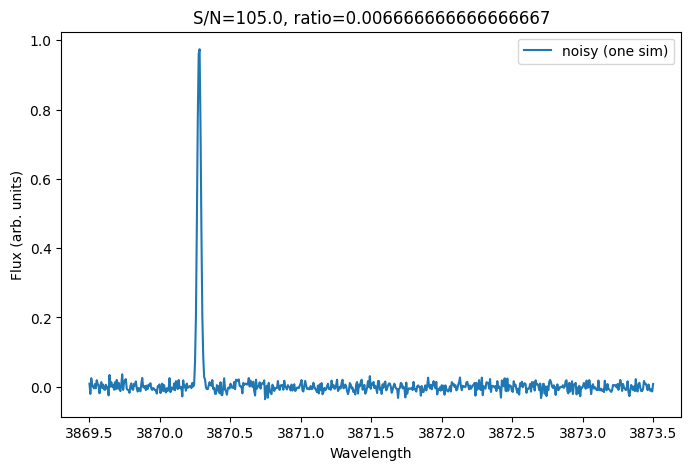

In [61]:
%matplotlib inline
from matplotlib import pyplot as plt

result = pd.read_csv('Output_spectras/0920-1206_stack_A.csv', skiprows=1)
window = (result['WAVE'] > 3869.5) & (result['WAVE'] < 3873.5)
x_fit = result['WAVE'][window].to_numpy()

trio_1 = [3870.28, 3870.555, 3870.66]
trio_2 = [3872.465, 3872.578, 3872.758]

sigma = 3880 / 140000
#pass this FWHM to sigma
sigma = sigma / np.sqrt(8 * np.log(2))
print("sigma:", sigma)
#to this sigma add a 1km/s Doppler broadening
c_kms = 299792.458
delta_lambda_doppler = (1.0 / c_kms) * 3880
sigma = np.sqrt(sigma**2 + (delta_lambda_doppler / (2.355))**2)
print("sigma with Doppler:", sigma)
# Same sweep as before, but now with truth-based QC and ratio comparison:
snrs   = np.arange(100, 500, 5)
scales = np.arange(100, 500, 50)
N_SIMS = 100

frac_grid = np.zeros((len(scales), len(snrs)))
for j, sn in enumerate(snrs):
    for i, scale_k in enumerate(scales):
        iso_scale = 1.0 / float(scale_k)  # if "scale" is dilution
        if i == 1 and j == 1:
            boolt = True
        else:
            boolt = False
        _, _, _, _, _, quality = trio_spectrum(
            x=x_fit,
            centers=trio_1,
            sigma=sigma,
            SNR_main=float(sn),
            iso_scale2=iso_scale,
            iso_scale3=iso_scale,
            A_main=1.0,
            n_sims=N_SIMS,
            sn_definition="area",
            fit=True, qc=True,
            # amplitude-based acceptance:
            qc_require_both_iso=True,
            qc_amp_rel_tol_iso=0.30,   # tighten to 0.30 if too lenient
            qc_amp_abs_tol_iso=0.02,
            qc_require_positive=True,
            # optional extra gates (try enabling if you like):
            qc_amp_snr_threshold=3.0,
            # qc_center_tol_sigmas=1.0,
            # qc_sigma_rel_tol=0.30,
            plot=boolt
        )
        frac_grid[i, j] = quality["good_fraction"]


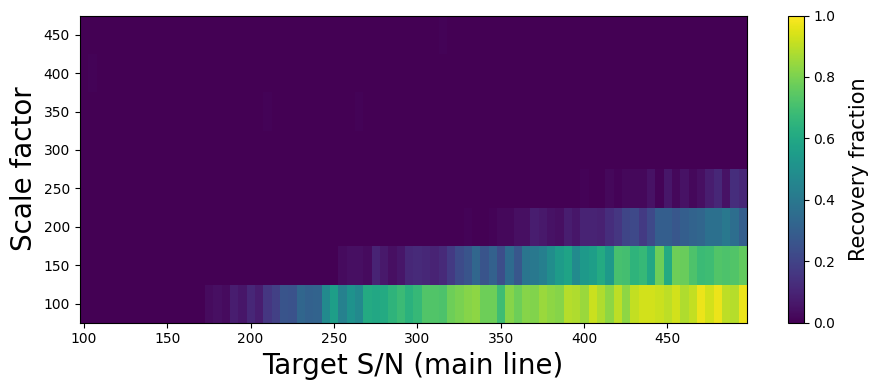

In [62]:
# Plot heatmap (0..1)
sn_step, sc_step = 5, 50
extent = [snrs[0]-sn_step/2, snrs[-1]+sn_step/2, scales[0]-sc_step/2, scales[-1]+sc_step/2]
plt.figure(figsize=(25/3+1, 4))
im = plt.imshow(frac_grid, origin="lower", aspect="auto", extent=extent, vmin=0, vmax=1)
cbar = plt.colorbar(im)
#cbar label and fontsize
cbar.set_label("Recovery fraction", fontsize=15, labelpad=10)
plt.xlabel("Target S/N (main line)", fontsize=20)
plt.ylabel("Scale factor", fontsize=20)
plt.tight_layout()
# plt.savefig(f"trio_recovery_fraction_heatmap_blue_lines.png", dpi=300)
plt.show()

sigma: 0.027714285714285716
sigma with Doppler: 0.028253919142839992


/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_46891/126887788.py:153: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


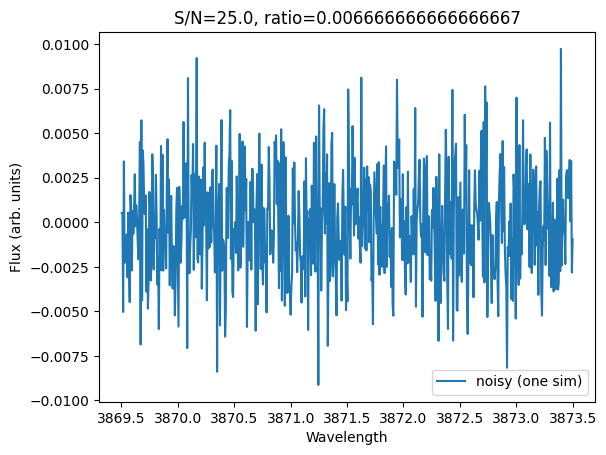

KeyboardInterrupt: 

In [33]:
import numpy as np
import matplotlib.pyplot as plt

linesa_1 = C_12_N_14_R['lambda_vac_A_from_Cal'].iloc[8]
linesa_2 = C_13_N_14_R['lambda_vac_A_from_Cal'].iloc[8]
linesa_3 = C_12_N_15_R['lambda_vac_A_from_Cal'].iloc[8]

linesb_1 = C_12_N_14_R['lambda_vac_A_from_Cal'].iloc[0]
linesb_2 = C_13_N_14_R['lambda_vac_A_from_Cal'].iloc[0]
linesb_3 = C_12_N_15_R['lambda_vac_A_from_Cal'].iloc[0]

trio_1 = [linesa_1, linesa_2, linesa_3]
trio_2 = [linesb_1, linesb_2, linesb_3]

sigma = 3880 / 140000
print("sigma:", sigma)
#to this sigma add a 1km/s Doppler broadening
c_kms = 299792.458
delta_lambda_doppler = (1.0 / c_kms) * 3880
sigma = np.sqrt(sigma**2 + (delta_lambda_doppler / (2.355))**2)
print("sigma with Doppler:", sigma)
# Same sweep as before, but now with truth-based QC and ratio comparison:
snrs   = np.arange(20, 101, 5)
scales = np.arange(100, 1001, 50)
N_SIMS = 100

frac_grid = np.zeros((len(scales), len(snrs)))
for j, sn in enumerate(snrs):
    for i, scale_k in enumerate(scales):
        iso_scale = 1.0 / float(scale_k)  # if "scale" is dilution
        if i == 1 and j == 1:
            boolt = True
        else:
            boolt = False
        _, _, _, _, _, quality = trio_spectrum(
            x=x_fit,
            centers=trio_2,
            sigma=sigma,
            SNR_main=float(sn),
            iso_scale2=iso_scale,
            iso_scale3=iso_scale,
            A_main=1.0,
            n_sims=N_SIMS,
            sn_definition="area",
            fit=True, qc=True,
            # amplitude-based acceptance:
            qc_require_both_iso=True,
            qc_amp_rel_tol_iso=0.30,   # tighten to 0.30 if too lenient
            qc_amp_abs_tol_iso=0.02,
            qc_require_positive=True,
            # optional extra gates (try enabling if you like):
            qc_amp_snr_threshold=3.0,
            # qc_center_tol_sigmas=1.0,
            # qc_sigma_rel_tol=0.30,
            plot=boolt
        )
        frac_grid[i, j] = quality["good_fraction"]


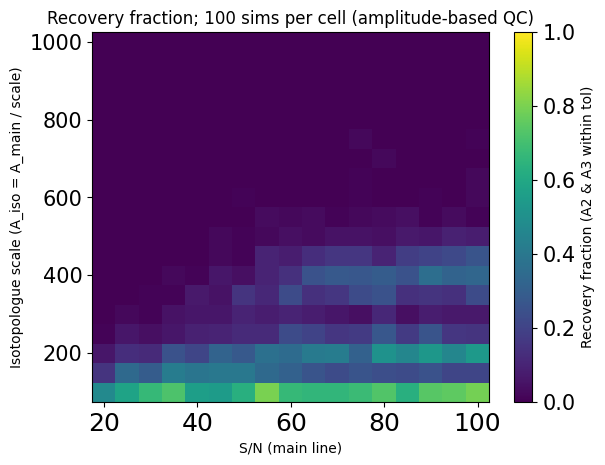

In [263]:
# Plot heatmap (0..1)
sn_step, sc_step = 5, 50
extent = [snrs[0]-sn_step/2, snrs[-1]+sn_step/2, scales[0]-sc_step/2, scales[-1]+sc_step/2]
plt.figure()
im = plt.imshow(frac_grid, origin="lower", aspect="auto", extent=extent, vmin=0, vmax=1)
plt.colorbar(im, label="Recovery fraction (A2 & A3 within tol)")
plt.xlabel("S/N (main line)")
plt.ylabel("Isotopologue scale (A_iso = A_main / scale)")
plt.title(f"Recovery fraction; {N_SIMS} sims per cell (amplitude-based QC)")
plt.savefig(f"trio_recovery_fraction_heatmap_red_lines.png", dpi=300)
plt.show()